<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🌱 Predicting Irrigation Need 🚜
    </h1>
</div>

# 📂 Overview

**Background**

The **Irrigation Water Requirement Prediction Dataset** contains agricultural, environmental, and crop-related data used to estimate irrigation needs under varying farming conditions. Each row represents a field observation, and each column captures soil characteristics, weather conditions, crop information, and irrigation context.

The dataset is designed to simulate real-world farming scenarios, making it highly suitable for analyzing how different factors influence water requirements in agriculture.

This dataset is ideal for:

* **Exploratory Data Analysis (EDA) on environmental and agricultural data**
* **Understanding key drivers of irrigation demand**
* **Feature engineering for agri-tech applications**
* **Multi-class classification modeling (Low / Medium / High irrigation need)**
* **Building decision-support systems for smart irrigation**

**Goal of the Project**

Build a machine learning model to **predict irrigation requirements** (`Irrigation_Need`: Low / Medium / High) based on soil properties, weather conditions, and crop characteristics.

The objective is to support:

* Efficient water resource management
* Smart irrigation systems
* Improved agricultural productivity
* Reduced water wastage and operational cost

**Key Features**

| Feature Name              | Description                                |
| ------------------------- | ------------------------------------------ |
| `Soil_Type`               | Type of soil (Clay, Sandy, Silt)           |
| `Soil_pH`                 | Soil acidity/alkalinity level              |
| `Soil_Moisture`           | Current soil moisture content              |
| `Organic_Carbon`          | Organic matter level in soil               |
| `Electrical_Conductivity` | Soil salinity / nutrient indicator         |
| `Temperature_C`           | Ambient temperature (°C)                   |
| `Humidity`                | Atmospheric humidity (%)                   |
| `Rainfall_mm`             | Amount of rainfall (mm)                    |
| `Sunlight_Hours`          | Daily sunlight exposure                    |
| `Wind_Speed_kmh`          | Wind speed (km/h)                          |
| `Crop_Type`               | Type of crop (e.g., Rice, Wheat, Maize)    |
| `Crop_Growth_Stage`       | Growth stage (Seedling → Maturity)         |
| `Season`                  | Seasonal context (Summer, Winter, Rainy)   |
| `Irrigation_Type`         | Irrigation method (Drip, Sprinkler, Flood) |
| `Water_Source`            | Source of irrigation water                 |
| `Field_Area_hectare`      | Size of agricultural field                 |
| `Mulching_Used`           | Whether mulching is applied                |
| `Previous_Irrigation_mm`  | Previous irrigation amount                 |
| `Region`                  | Geographic region                          |
| `Irrigation_Need`         | Target variable (Low / Medium / High)      |

**Files Provided**

From *Kaggle Playground Series – Season 6, Episode 4*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.

(Source: [Kaggle Competition – S6E4](https://www.kaggle.com/competitions/playground-series-s6e4))

From *Kaggle Dataset – Irrigation Water Requirement Prediction*:

* `irrigation_prediction.csv`: Main dataset containing all features and target variable
* The dataset is publicly available on Kaggle and designed for irrigation prediction and agri-ML use cases

(Source:
[Irrigation Water Requirement Prediction Dataset](https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data))

**Business & Analytical Relevance (optional – nên giữ)**

This project demonstrates how data science can be applied in agriculture to:

* Optimize irrigation scheduling
* Reduce water consumption
* Improve crop yield efficiency
* Support precision farming initiatives

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin==0.5.5 > pip_log_pingouin.txt 2>&1

In [2]:
# =====================================================
# Standard Library
# =====================================================
import gc
import logging
import os
import sys
import warnings
from itertools import combinations
from logging.handlers import RotatingFileHandler
from typing import Iterable, List, Optional

# =====================================================
# Third-party Libraries
# =====================================================
import numpy as np
import optuna
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp
import seaborn as sns
import xgboost as xgb
from colorlog import ColoredFormatter
from IPython.display import HTML, display
from scipy.optimize import minimize
from scipy.stats import (
    chi2_contingency,
    kurtosis,
    kruskal,
    levene,
    mannwhitneyu,
    probplot,
    skew,
    ttest_ind,
)
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from tqdm import tqdm

# =====================================================
# Visualization
# =====================================================
import matplotlib.pyplot as plt

# =====================================================
# Configuration
# =====================================================
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [3]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # ===== Experiment settings =====
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 5
    THRESHOLD = 0.5
    PSEUDO_THRESH = 0.92

    # ===== Target / ID =====
    TARGET_FEATURE = "Irrigation_Need"
    ID_COLUMN = "id"

    # ===== Data paths =====
    ORIGINAL_DATA = "/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv"
    TRAIN_DATA = "/kaggle/input/competitions/playground-series-s6e4/train.csv"
    TEST_DATA = "/kaggle/input/competitions/playground-series-s6e4/test.csv"

    # ===== Label mapping =====
    TARGET_MAPPING = {"Low": 0, "Medium": 1, "High": 2}
    INV_TARGET_MAPPING = {0: "Low", 1: "Medium", 2: "High"}

    # ===== Domain thresholds (feature engineering) =====
    SOIL_THRESH = 25
    RAIN_THRESH = 300
    TEMP_THRESH = 30
    WIND_THRESH = 10

    # ===== Precomputed logit coefficients =====
    LOGIT_COEFS = {
        "Low": {
            "intercept": 16.3173,
            "soil_lt_25": -11.0237,
            "temp_gt_30": -5.8559,
            "rain_lt_300": -10.8500,
            "wind_gt_10": -5.8284,
            "Flowering": -5.4155,
            "Harvest": 5.5073,
            "Sowing": 5.2299,
            "Vegetative": -5.4617,
            "Mulch_No": -3.0014,
            "Mulch_Yes": 2.8613,
        },
        "Medium": {
            "intercept": 4.6524,
            "soil_lt_25": 0.3290,
            "temp_gt_30": -0.0204,
            "rain_lt_300": 0.1542,
            "wind_gt_10": 0.0841,
            "Flowering": 0.3586,
            "Harvest": -0.1348,
            "Sowing": -0.3547,
            "Vegetative": 0.3334,
            "Mulch_No": 0.1883,
            "Mulch_Yes": 0.0142,
        },
        "High": {
            "intercept": -20.9697,
            "soil_lt_25": 10.6947,
            "temp_gt_30": 5.8763,
            "rain_lt_300": 10.6958,
            "wind_gt_10": 5.7444,
            "Flowering": 5.0569,
            "Harvest": -5.3725,
            "Sowing": -4.8752,
            "Vegetative": 5.1283,
            "Mulch_No": 2.8131,
            "Mulch_Yes": -2.8755,
        },
    }

    # ===== Plot colors =====
    COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

    # =====================================================
    # Logger
    # =====================================================
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG, log_file: str | None = None) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        # optional file logging
        if log_file:
            file_formatter = logging.Formatter(
                "%(asctime)s | %(levelname)-8s | %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S",
            )

            file_handler = RotatingFileHandler(
                log_file,
                maxBytes=500 * 1024 * 1024,
                backupCount=5,
            )
            file_handler.setFormatter(file_formatter)
            logger.addHandler(file_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    # =====================================================
    # Data Utils
    # =====================================================
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype

            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()

                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category

        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

    @staticmethod
    def memory_report(df: pd.DataFrame) -> float:
        """Return memory usage (MB)."""
        return round(df.memory_usage(deep=True).sum() / 1024**2, 2)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [4]:
# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load datasets safely
df_train = CFG.read_csv_safe(CFG.TRAIN_DATA, logger).pipe(CFG.clean_columns)
df_test = CFG.read_csv_safe(CFG.TEST_DATA, logger).pipe(CFG.clean_columns)
df_original = CFG.read_csv_safe(CFG.ORIGINAL_DATA, logger).pipe(CFG.clean_columns)

2026-04-07 12:58:40 | INFO     | Logging configured: level=DEBUG
2026-04-07 12:58:42 | INFO     | Loaded: utf-8 | Shape: (630000, 21)
2026-04-07 12:58:43 | INFO     | Loaded: utf-8 | Shape: (270000, 20)
2026-04-07 12:58:43 | INFO     | Loaded: utf-8 | Shape: (10000, 20)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

2026-04-07 12:58:43 | INFO     | Train Data Preview


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


2026-04-07 12:58:43 | INFO     | Test Data Preview


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


2026-04-07 12:58:43 | INFO     | Original Data Preview


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [6]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-04-07 12:58:43 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season    

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Training dataset</b>: 630,000 samples, 21 columns (including <code>Irrigation_Need</code>).</li>
  <li><b>Test dataset</b>: 270,000 samples, 20 columns (excluding <code>Irrigation_Need</code>).</li>
  <li><b>Original dataset</b>: 10,000 samples, 20 columns.</li>
  <li>Train and test share identical feature structure except for the target variable.</li>
  <li>Large-scale synthetic datasets significantly enhance model robustness and generalization.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>Dataset includes <b>soil properties, weather conditions, crop characteristics, and irrigation context</b>.</li>
  <li><b>Numerical features (11):</b> 
      <code>Soil_pH</code>, <code>Soil_Moisture</code>, <code>Organic_Carbon</code>, 
      <code>Electrical_Conductivity</code>, <code>Temperature_C</code>, <code>Humidity</code>, 
      <code>Rainfall_mm</code>, <code>Sunlight_Hours</code>, <code>Wind_Speed_kmh</code>, 
      <code>Field_Area_hectare</code>, <code>Previous_Irrigation_mm</code>.
  </li>
  <li><b>Categorical features (9):</b> 
      <code>Soil_Type</code>, <code>Crop_Type</code>, <code>Crop_Growth_Stage</code>, 
      <code>Season</code>, <code>Irrigation_Type</code>, <code>Water_Source</code>, 
      <code>Mulching_Used</code>, <code>Region</code>, <code>Irrigation_Need</code>.
  </li>
  <li><code>Irrigation_Need</code> is a <b>multi-class target variable</b> (Low / Medium / High).</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li>No missing values detected across all datasets.</li>
  <li>Data types are consistent and clean (no type mismatch issues).</li>
  <li>Categorical variables stored as <code>object</code> require encoding for modeling.</li>
  <li>No obvious data leakage features identified.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Training dataset: ~100.9 MB.</li>
  <li>Test dataset: ~41.2 MB.</li>
  <li>Original dataset: ~1.5 MB.</li>
  <li>Memory usage is primarily driven by categorical (string) features.</li>
  <li>Converting categorical columns to <code>category</code> dtype can significantly improve memory efficiency and training speed.</li>
</ul>

</div>

In [7]:
num_features = [
    "Soil_pH",
    "Soil_Moisture",
    "Organic_Carbon",
    "Electrical_Conductivity",
    "Temperature_C",
    "Humidity",
    "Rainfall_mm",
    "Sunlight_Hours",
    "Wind_Speed_kmh",
    "Field_Area_hectare",
    "Previous_Irrigation_mm"
]

cat_features = [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Mulching_Used",
    "Region"
]

# Drop columns id
df_train.drop(columns=CFG.ID_COLUMN, inplace=True)
list_test_id = df_test[CFG.ID_COLUMN].copy().to_list()
df_test.drop(columns=CFG.ID_COLUMN, inplace=True)

## Numerical Feature Summary — Data Analyst Perspective

In [8]:
cm = sns.light_palette("green", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-04-07 12:58:43 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.000000,6.482497,0.922504,4.800000,5.690000,6.440000,7.270000,8.200000
Soil_Moisture,630000.000000,37.304482,16.377082,8.000000,23.340000,37.750000,51.270000,64.990000
Organic_Carbon,630000.000000,0.922858,0.365808,0.300000,0.610000,0.910000,1.220000,1.600000
Electrical_Conductivity,630000.000000,1.744605,0.952321,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,630000.000000,26.998166,8.623621,12.000000,19.517500,26.960000,34.540000,42.000000
Humidity,630000.000000,61.563180,19.708152,25.000000,45.390000,61.650000,79.120000,94.990000
Rainfall_mm,630000.000000,1462.207566,612.989738,0.380000,954.570000,1467.160000,2054.280000,2499.690000
Sunlight_Hours,630000.000000,7.513382,1.999322,4.000000,5.760000,7.580000,9.250000,11.000000
Wind_Speed_kmh,630000.000000,10.375394,5.689458,0.500000,5.280000,10.480000,15.430000,20.000000
Field_Area_hectare,630000.000000,7.517745,4.218124,0.300000,3.880000,7.380000,11.140000,15.000000


2026-04-07 12:58:44 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
Soil_pH,270000.000000,6.480929,0.922187,4.800000,5.680000,6.440000,7.260000,8.200000
Soil_Moisture,270000.000000,37.307614,16.375273,8.010000,23.340000,37.770000,51.200000,64.990000
Organic_Carbon,270000.000000,0.922279,0.365757,0.300000,0.610000,0.900000,1.220000,1.600000
Electrical_Conductivity,270000.000000,1.745251,0.951329,0.100000,0.930000,1.740000,2.580000,3.500000
Temperature_C,270000.000000,27.001666,8.630706,12.010000,19.500000,26.960000,34.530000,42.000000
Humidity,270000.000000,61.511319,19.690278,25.000000,45.310000,61.620000,79.090000,94.990000
Rainfall_mm,270000.000000,1464.525885,612.521709,1.640000,956.100000,1476.030000,2055.750000,2499.690000
Sunlight_Hours,270000.000000,7.513277,2.002661,4.000000,5.760000,7.590000,9.250000,11.000000
Wind_Speed_kmh,270000.000000,10.386531,5.683215,0.500000,5.320000,10.520000,15.430000,20.000000
Field_Area_hectare,270000.000000,7.508192,4.218736,0.300000,3.880000,7.360000,11.140000,15.000000


2026-04-07 12:58:44 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.000000,6.487857,0.979963,4.800000,5.640000,6.470000,7.350000,8.200000
Soil_Moisture,10000.000000,36.969207,16.430845,8.000000,22.860000,37.240000,50.940000,65.000000
Organic_Carbon,10000.000000,0.944731,0.372406,0.300000,0.620000,0.950000,1.260000,1.600000
Electrical_Conductivity,10000.000000,1.791963,0.984202,0.100000,0.940000,1.780000,2.650000,3.500000
Temperature_C,10000.000000,26.991423,8.664074,12.000000,19.460000,27.090000,34.500000,42.000000
Humidity,10000.000000,60.080339,20.187973,25.000000,42.855000,60.040000,77.705000,95.000000
Rainfall_mm,10000.000000,1252.499420,715.582201,0.380000,634.155000,1250.335000,1880.265000,2499.690000
Sunlight_Hours,10000.000000,7.518538,2.016077,4.000000,5.760000,7.560000,9.260000,11.000000
Wind_Speed_kmh,10000.000000,10.163545,5.670923,0.500000,5.160000,10.190000,15.100000,20.000000
Field_Area_hectare,10000.000000,7.598024,4.233919,0.300000,3.950000,7.540000,11.202500,15.000000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">
<li><code>Soil Moisture</code>: Avg ~37%; median ~37.7; wide range (~8 → 65) → strong variability in soil water availability.</li>
<li><code>Temperature</code>: Avg ~27°C; mostly between ~19–35°C → stable warm climate conditions across datasets.</li>
<li><code>Humidity</code>: Avg ~61%; broad spread (~25 → 95) → indicates diverse atmospheric conditions affecting evaporation.</li>
<li><code>Rainfall</code>: Avg ~1460 mm (train/test) vs ~1250 mm (original); extremely wide range (~0.3 → 2500) → highly volatile feature.</li>
<li><code>Sunlight Hours</code>: Avg ~7.5 hours; relatively tight distribution (~4 → 11) → consistent daily solar exposure.</li>
<li><code>Wind Speed</code>: Avg ~10.3 km/h; moderate variability (~0.5 → 20) → contributes to evaporation dynamics.</li>
<li><code>Field Area</code>: Avg ~7.5 hectares; spread (~0.3 → 15) → diverse farm sizes.</li>
<li><code>Previous Irrigation</code>: Avg ~62 mm; wide range (~0 → 120) → strong signal for irrigation behavior history.</li>
<li><code>Original dataset</code>: Smaller (10,000 samples) but maintains similar distributions, except slightly lower average rainfall.</li>
</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Greens", subset=["unique", "freq"]))

2026-04-07 12:58:44 | INFO     | Train Data Describe:


,count,unique,top,freq
Soil_Type,630000,4,Sandy,166509
Crop_Type,630000,6,Sugarcane,108910
Crop_Growth_Stage,630000,4,Harvest,167689
Season,630000,3,Kharif,216561
Irrigation_Type,630000,4,Canal,161901
Water_Source,630000,4,Reservoir,162994
Mulching_Used,630000,2,No,316453
Region,630000,5,South,134809


2026-04-07 12:58:44 | INFO     | Test Data Describe:


,count,unique,top,freq
Soil_Type,270000,4,Sandy,71293
Crop_Type,270000,6,Sugarcane,46110
Crop_Growth_Stage,270000,4,Harvest,71992
Season,270000,3,Kharif,92893
Irrigation_Type,270000,4,Canal,69663
Water_Source,270000,4,Reservoir,69928
Mulching_Used,270000,2,No,136183
Region,270000,5,South,57795


2026-04-07 12:58:44 | INFO     | Original Data Describe:


,count,unique,top,freq
Soil_Type,10000,4,Sandy,2536
Crop_Type,10000,6,Rice,1711
Crop_Growth_Stage,10000,4,Harvest,2581
Season,10000,3,Rabi,3383
Irrigation_Type,10000,4,Sprinkler,2527
Water_Source,10000,4,River,2528
Mulching_Used,10000,2,No,5013
Region,10000,5,South,2102


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Soil Type</b>: 4 categories; <code>Sandy</code> is the most common across all datasets → suggests faster drainage conditions dominate.</li>
<li><b>Crop Type</b>: 6 crop categories; <code>Sugarcane</code> dominates in train/test, while <code>Rice</code> is more frequent in the original dataset → indicates distribution shift due to synthetic expansion.</li>
<li><b>Crop Growth Stage</b>: 4 stages; <code>Harvest</code> appears most frequently → dataset may be slightly skewed toward later growth phases.</li>
<li><b>Season</b>: 3 categories; <code>Kharif</code> dominates in train/test, while <code>Rabi</code> is more frequent in original → seasonal distribution differs across datasets.</li>
<li><b>Irrigation Type</b>: 4 methods; <code>Canal</code> is dominant in train/test, whereas <code>Sprinkler</code> leads in original → variation reflects synthetic data generation.</li>
<li><b>Water Source</b>: 4 categories; <code>Reservoir</code> dominates in train/test, while <code>River</code> is slightly more common in original dataset.</li>
<li><b>Mulching Used</b>: Binary feature; <code>No</code> is significantly more frequent (~50%+) → mulching is not widely adopted.</li>
<li><b>Region</b>: 5 regions; <code>South</code> is the most represented across all datasets.</li>
</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [10]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")

for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-04-07 12:58:45 | INFO     | Start checking NULL values
2026-04-07 12:58:45 | INFO     | Checking missing values for Train...
2026-04-07 12:58:47 | INFO     | No missing values detected in 630,000 rows.
2026-04-07 12:58:47 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:47 | INFO     | Checking missing values for Test...
2026-04-07 12:58:48 | INFO     | No missing values detected in 270,000 rows.
2026-04-07 12:58:48 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:48 | INFO     | Checking missing values for Original...
2026-04-07 12:58:48 | INFO     | No missing values detected in 10,000 rows.
2026-04-07 12:58:48 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:48 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [11]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-04-07 12:58:48 | INFO     | Start checking duplicate values
2026-04-07 12:58:48 | INFO     | Train duplicate Analysis...
2026-04-07 12:58:49 | INFO     | No duplicate rows found out of 630,000 total rows.
2026-04-07 12:58:49 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:49 | INFO     | Test duplicate Analysis...
2026-04-07 12:58:49 | INFO     | No duplicate rows found out of 270,000 total rows.
2026-04-07 12:58:49 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:49 | INFO     | Original duplicate Analysis...
2026-04-07 12:58:49 | INFO     | No duplicate rows found out of 10,000 total rows.
2026-04-07 12:58:49 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:49 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [12]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("-" * 80)

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    logger.info("-" * 80)

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    outlier_data = checking_outlier(df=data, dataset_name=name)
    # display(outlier_data)

logger.info("Outlier checking successfully completed across datasets.")

2026-04-07 12:58:49 | INFO     | Start checking outlier across datasets
2026-04-07 12:58:50 | INFO     | Checking outliers for Train...
2026-04-07 12:58:50 | INFO     | --------------------------------------------------------------------------------
2026-04-07 12:58:50 | DEBUG    | [Train] Soil_pH: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Soil_Moisture: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Organic_Carbon: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Electrical_Conductivity: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Temperature_C: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Humidity: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Rainfall_mm: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Sunlight_Hours: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Wind_Speed_kmh: No outliers detected
2026-04-07 12:58:50 | DEBUG    | [Train] Field_Area_hecta

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Comprehensive missing value checks were performed across <b>Train</b>, <b>Test</b>, and <b>Original</b> datasets.</li>
<li><b>No missing values detected</b> in all datasets (630K / 270K / 10K rows).</li>
<li>This indicates a <b>fully complete and clean dataset</b>, eliminating the need for imputation.</li>
</ul>

<h3>Duplicate Records Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Duplicate checks were conducted to ensure data integrity and avoid biased modeling.</li>
<li><b>No duplicate rows found</b> across Train, Test, and Original datasets.</li>
<li>This confirms that each observation represents a unique scenario.</li>
</ul>

<h3>Outlier Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Outlier detection was applied to all numerical features (e.g., <code>Soil_Moisture</code>, <code>Rainfall_mm</code>, <code>Temperature_C</code>, etc.).</li>
<li><b>No outliers detected</b> across all datasets.</li>
<li>Feature distributions are well-bounded and consistent, indicating controlled data generation.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> All datasets demonstrate <b>excellent data quality</b> — with no missing values, no duplicates, and no detectable outliers. This strongly suggests a <b>well-curated (or synthetically generated) dataset</b>, allowing the modeling phase to focus entirely on feature relationships rather than data cleaning.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [13]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold", pad=15)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("green", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Greens")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Irrigation_Need Distribution

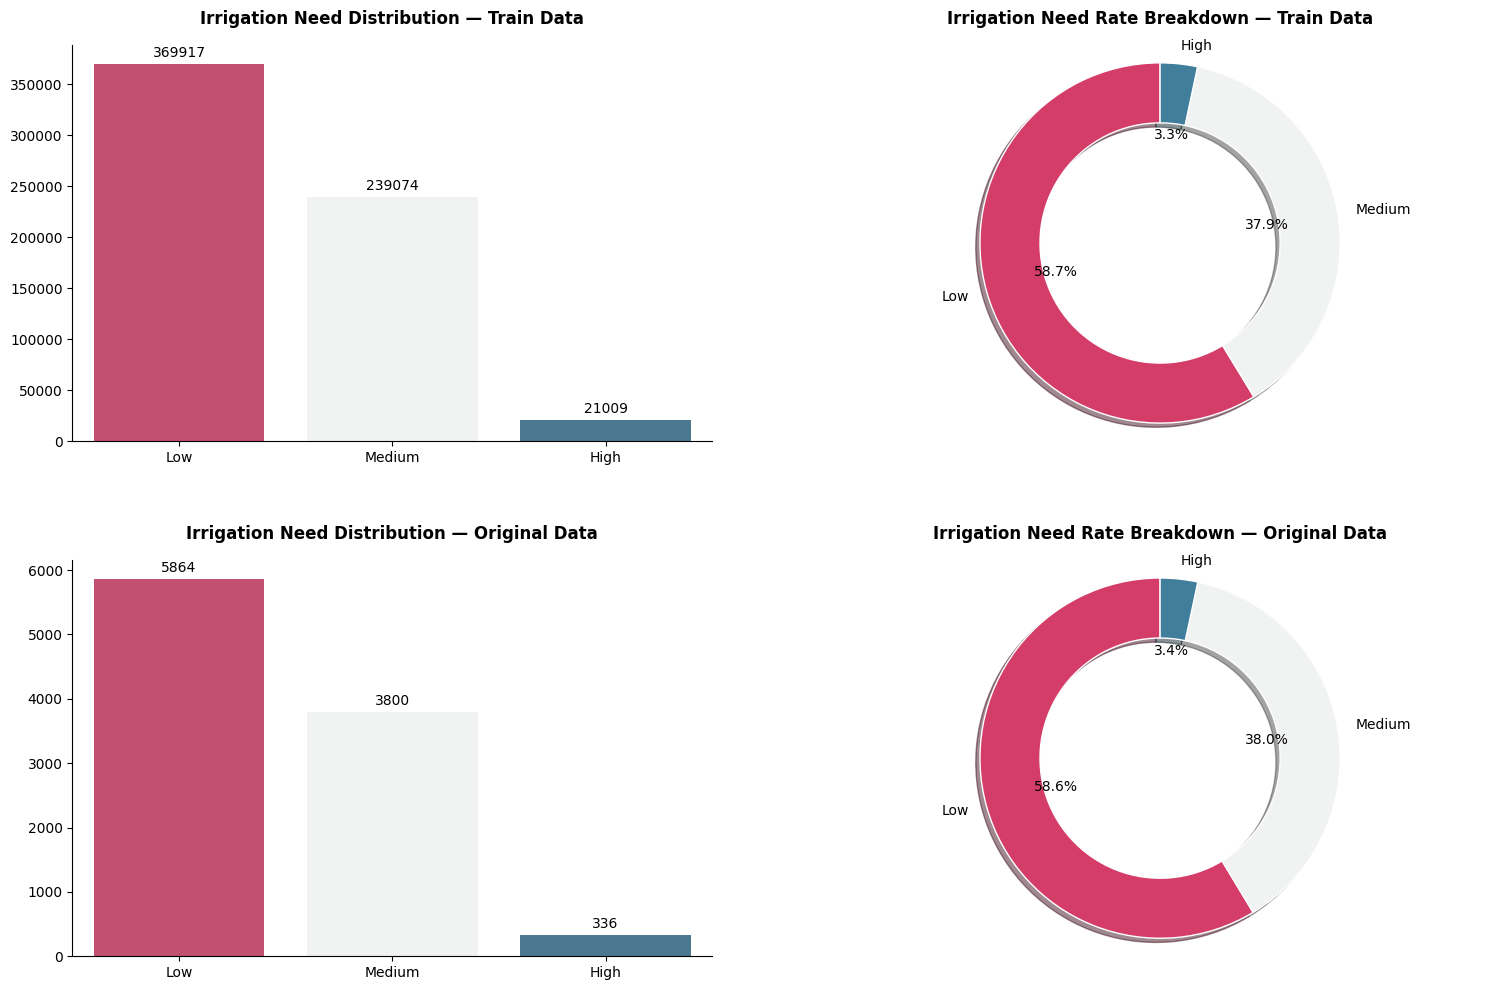

In [14]:
# Set target variable
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
datasets = [("Train Data", df_train), ("Original Data", df_original)]
n_color = df_train[CFG.TARGET_FEATURE].nunique()
order_irrigation_need = df_train[CFG.TARGET_FEATURE].unique().tolist()

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]

    # Vertical barplot
    sns.countplot(x=CFG.TARGET_FEATURE, data=data, ax=ax,
                  palette=color(n_colors=n_color), order=order_irrigation_need)
    ax.set_title(f"Irrigation Need Distribution — {title}", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + max(data[CFG.TARGET_FEATURE].value_counts()) * 0.01,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, color="black")

    # Pie chart
    y_counts = data[CFG.TARGET_FEATURE].value_counts().reindex(order_irrigation_need)
    wedges, texts, autotexts = axes[i, 1].pie(
        y_counts, autopct="%1.1f%%", startangle=90, colors=color(n_colors=n_color), wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,  shadow=True, labels=order_irrigation_need)
    for text in texts + autotexts:
        text.set_fontsize(10)

    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"Irrigation Need Rate Breakdown — {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Target Distribution
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    margin-bottom: 20px;
    font-size: 15px;
">
<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Dataset</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Low</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Medium</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">High</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">High Rate</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Train</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">369,917</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">239,074</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">21,009</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>3.3%</b></td>
</tr>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Original</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">5,864</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">3,800</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">336</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>3.4%</b></td>
</tr>
</tbody>
</table>

<ul style="line-height:1.8; padding-left:20px;">
<li><b>Majority class:</b> <code>Low</code> (~58–59%) → most scenarios require minimal irrigation.</li>

<li><b>Secondary class:</b> <code>Medium</code> (~37–38%) → moderate irrigation demand is common.</li>

<li><b>Minority class:</b> <code>High</code> (~3–4%) → extreme irrigation needs are rare.</li>

<li>Both datasets exhibit a <b>highly imbalanced multi-class distribution</b>, especially for the <code>High</code> class.</li>

<li>Distribution between <b>Train and Original datasets is nearly identical</b> → indicates stable synthetic data generation.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> The <b>"High" irrigation class is extremely underrepresented (~3%)</b>, which may lead to model bias toward predicting <code>Low</code> and <code>Medium</code>. Special handling (e.g., class weighting or resampling) may be required to improve performance on this critical minority class.
</div>

</div>

## Numerical Feature Distributions

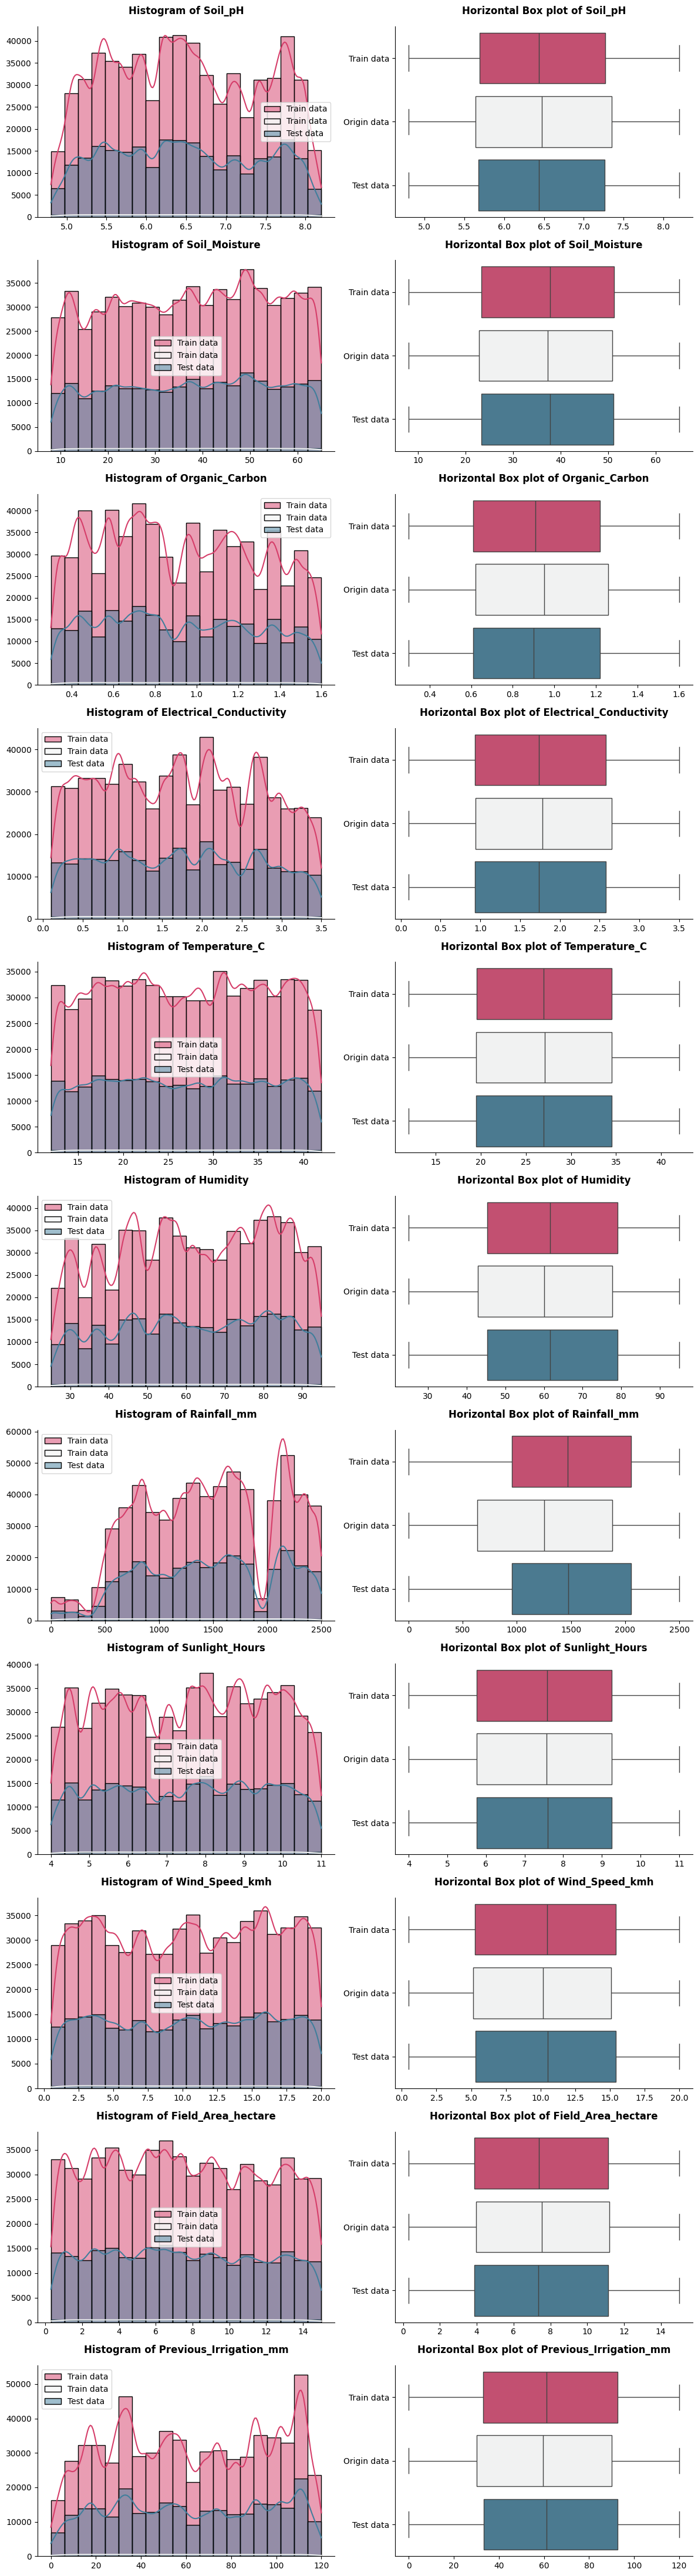

In [15]:
def plot_numerical_features(df_train: pd.DataFrame, df_test: pd.DataFrame, 
                            df_origin: pd.DataFrame, num_features: List[str]) -> None:
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """

    # Generate color palette for 3 datasets
    colors = color(n_colors=3)
    n = len(num_features)

    # Create subplot grid: each feature has 1 row, 2 columns (hist + boxplot)
    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        # Histogram + KDE Plot
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_origin[feature], color=colors[1], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_test[feature], color=colors[2], bins=20, kde=True, ax=ax[i, 0], label="Test data")
        # Format histogram
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Origin data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        # Prepare Data for Boxplot
        sns.boxplot(
            data=df_plot,
            x=feature,
            y="Dataset",
            palette=colors,
            orient="h",
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 1].set_xlabel("")
        ax[i, 1].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_original, num_features=num_features)

In [16]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: List[str] =num_features, 
                   sort=True, logger: logging.Logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df_train, "Irrigation Need")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-04-07 12:59:52 | INFO     | Skewness analysis for Irrigation Need
2026-04-07 12:59:52 | INFO     | Total numerical features checked: 11
2026-04-07 12:59:52 | DEBUG    | ----------------------------------------------------------------------
2026-04-07 12:59:52 | DEBUG    | Feature                        | Skewness  | Remark
2026-04-07 12:59:52 | DEBUG    | ----------------------------------------------------------------------
2026-04-07 12:59:52 | DEBUG    | Rainfall_mm                    |   -0.1176 | Approximately symmetric
2026-04-07 12:59:52 | DEBUG    | Organic_Carbon                 |   +0.1050 | Approximately symmetric
2026-04-07 12:59:52 | DEBUG    | Humidity                       |   -0.0888 | Approximately symmetric
2026-04-07 12:59:52 | DEBUG    | Soil_pH                        |   +0.0695 | Approximately symmetric
2026-04-07 12:59:52 | DEBUG    | Soil_Moisture                  |   -0.0636 | Approximately symmetric
2026-04-07 12:59:52 | DEBUG    | Field_Area_hectare     

## Correlation Analysis of Numerical Features

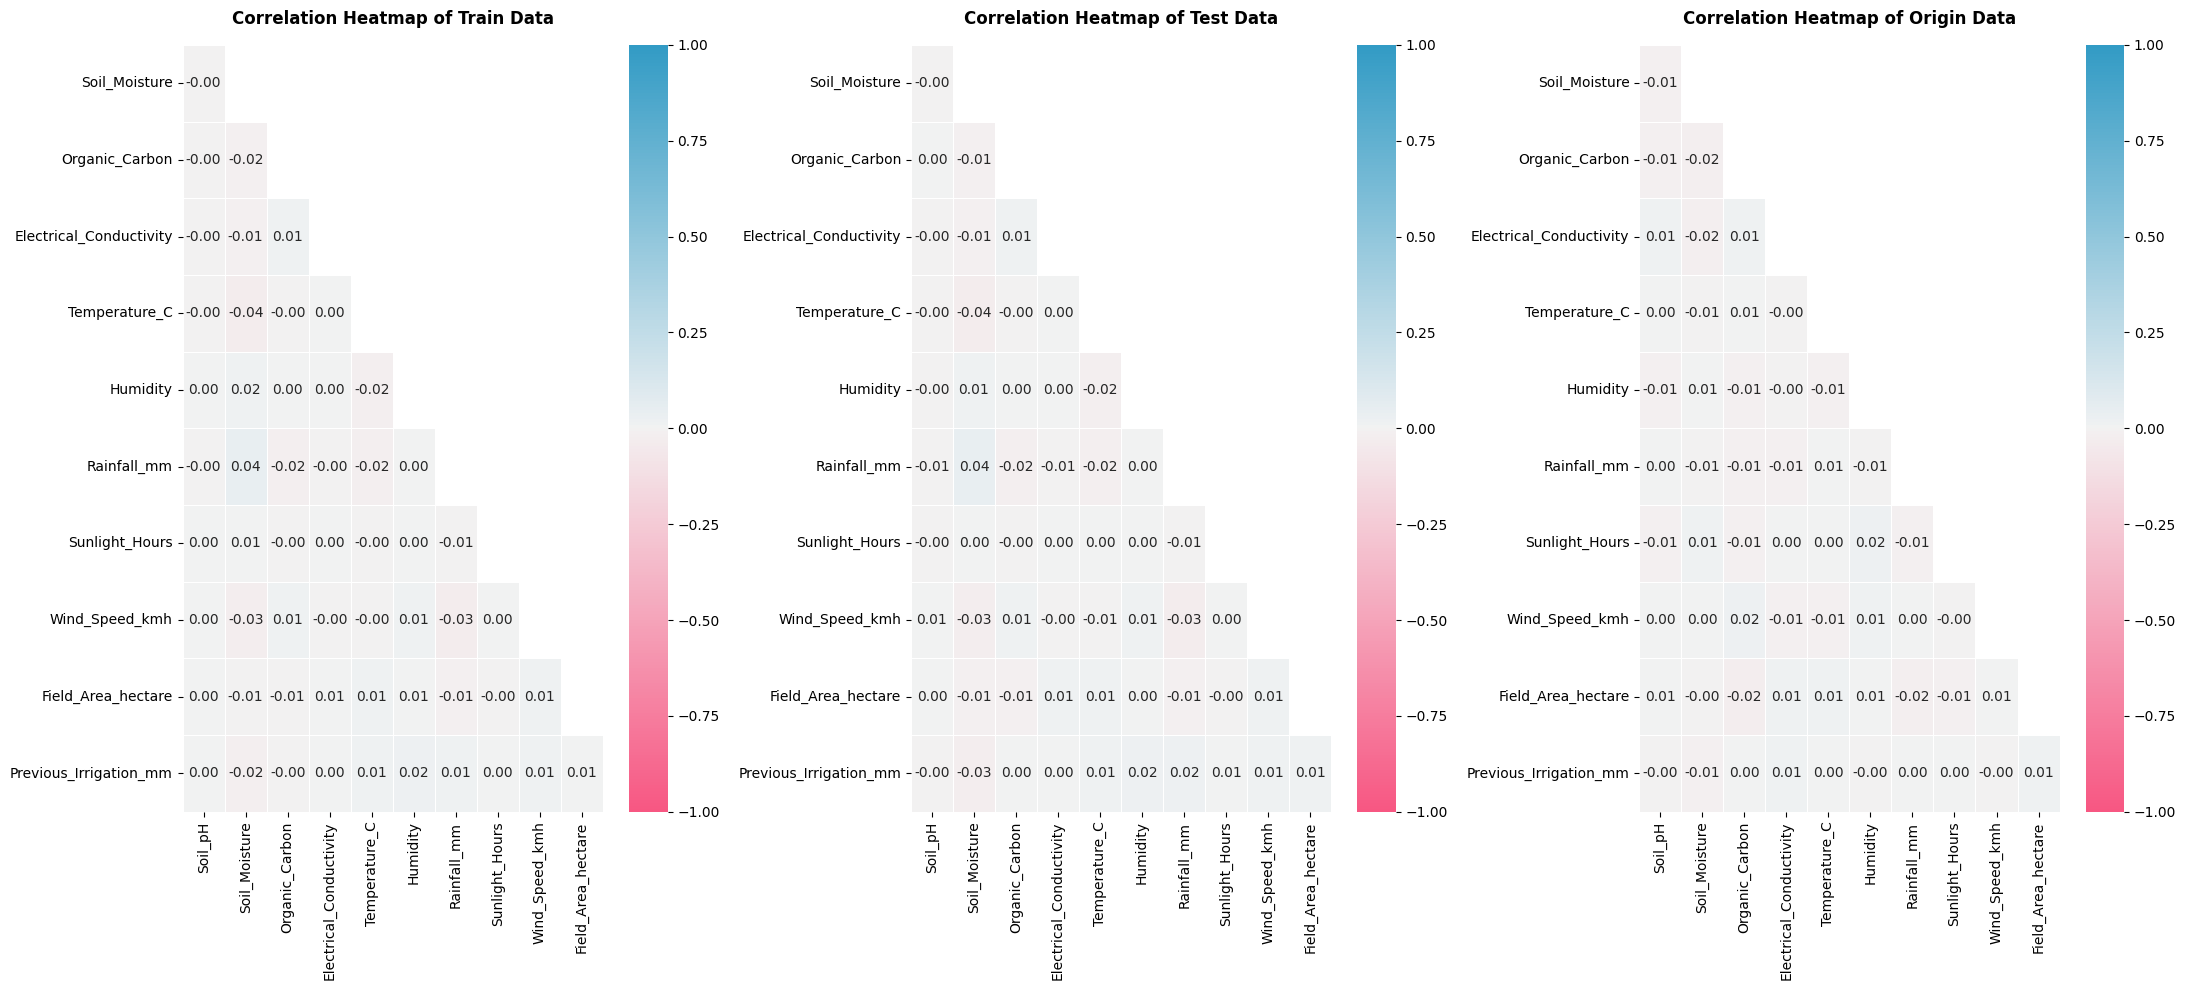

In [17]:
def plot_correlation(df_train, df_origin, df_test, origin_name="Origin Data", train_name="Train Data", test_name="Test Data"):
    """
    Plot side-by-side correlation heatmaps for training and test datasets.

    This function computes Pearson correlation matrices for numerical features
    in both training and test datasets, applies a triangular mask to avoid
    duplicated information, and visualizes the results using seaborn heatmaps.

    Parameters
    ----------
    df_train : pandas.DataFrame
        Training dataset (features only, target column should be removed).

    df_test : pandas.DataFrame
        Test dataset (features only).

    train_name : str, default="Train Data"
        Title name for the training heatmap.

    test_name : str, default="Test Data"
        Title name for the test heatmap.

    Returns
    -------
    None
        Displays correlation heatmaps for train and test datasets.
    """

    corr_train = df_train.corr(numeric_only=True)
    corr_origin = df_origin.corr(numeric_only=True)
    corr_test = df_test.corr(numeric_only=True)

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_origin = np.triu(np.ones_like(corr_origin, dtype=bool))
    adjusted_mask_origin = mask_origin[1:, :-1]
    adjusted_cereal_corr_origin = corr_origin.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 3, figsize=(22, 10))

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_origin, mask=adjusted_mask_origin,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[2])
    ax[2].set_title(f"Correlation Heatmap of {origin_name}", fontsize=12, weight="bold", pad=15)

    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train.drop(columns=CFG.TARGET_FEATURE),
                 df_origin=df_original.drop(columns=CFG.TARGET_FEATURE),
                 df_test=df_test)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Correlation Analysis (Numerical Features)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Pearson correlation was computed across all numerical features including 
<code>Soil_pH</code>, <code>Soil_Moisture</code>, <code>Temperature_C</code>, 
<code>Humidity</code>, <code>Rainfall_mm</code>, <code>Sunlight_Hours</code>, 
<code>Wind_Speed_kmh</code>, <code>Field_Area_hectare</code>, and others.</li>

<li>Overall correlations are <b>extremely low (≈ -0.05 → 0.05)</b>, indicating 
<b>near independence between features</b> and <b>no multicollinearity concerns</b>.</li>

</ul>

<h3 style="margin-top:15px;">Notable Relationships</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>No feature pairs exhibit meaningful linear relationships — all correlations are 
<b>close to zero</b>.</li>

<li>Slight correlations (e.g., <code>Rainfall_mm</code> vs <code>Soil_Moisture</code>, 
<code>Temperature_C</code> vs <code>Humidity</code>) are <b>negligible</b> and 
do not indicate strong dependencies.</li>

<li>Environmental variables behave as <b>independent signals</b>, which is realistic 
for diverse agricultural conditions.</li>

</ul>

<h3>Train–Test Consistency</h3>

<ul style="line-height: 1.8; padding-left: 20px;">
<li>Correlation matrices across <b>Train, Test, and Original datasets are nearly identical</b>.</li>
<li>No structural differences or relationship drift observed.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Modeling Implications:</b>
<ul style="margin-top:8px; padding-left:18px; line-height:1.7;">
<li>The absence of strong correlations means <b>no need for feature removal due to multicollinearity</b>.</li>
<li>Linear models may benefit from <b>feature interactions or polynomial terms</b> to capture hidden relationships.</li>
<li>All features can be safely retained for modeling without transformation based on correlation structure.</li>
</ul>
</div>

</div>

## Categorical Feature Distributions

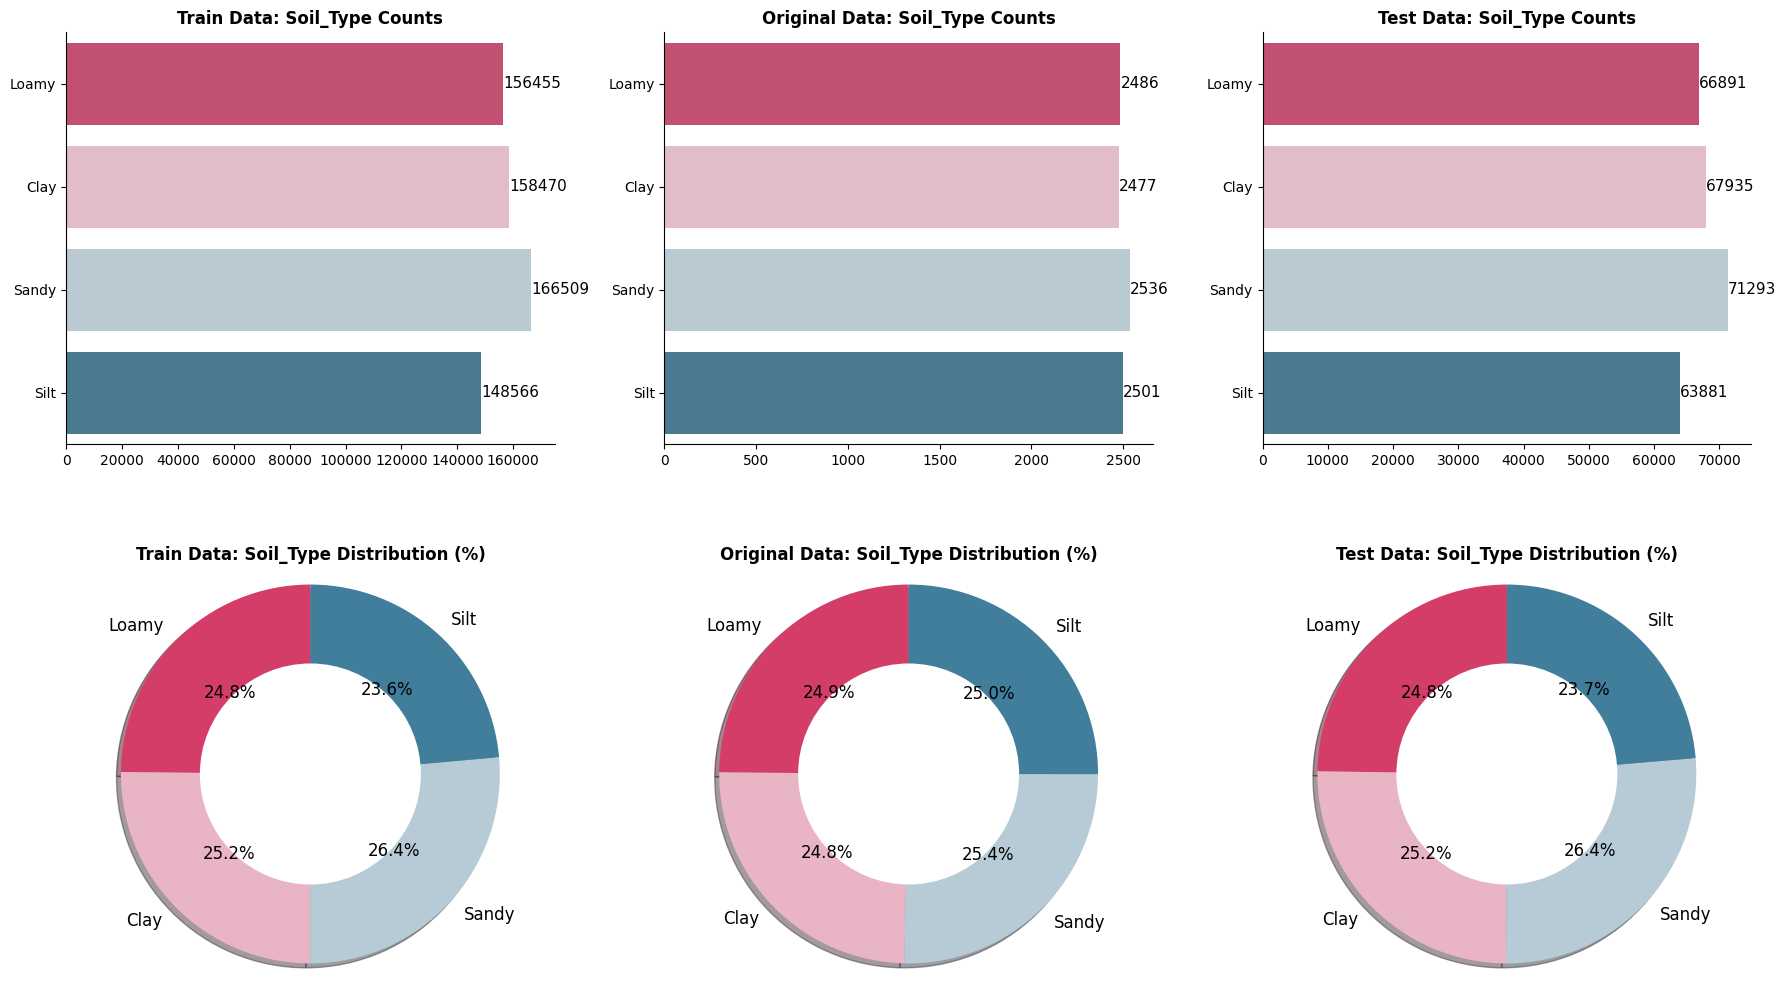

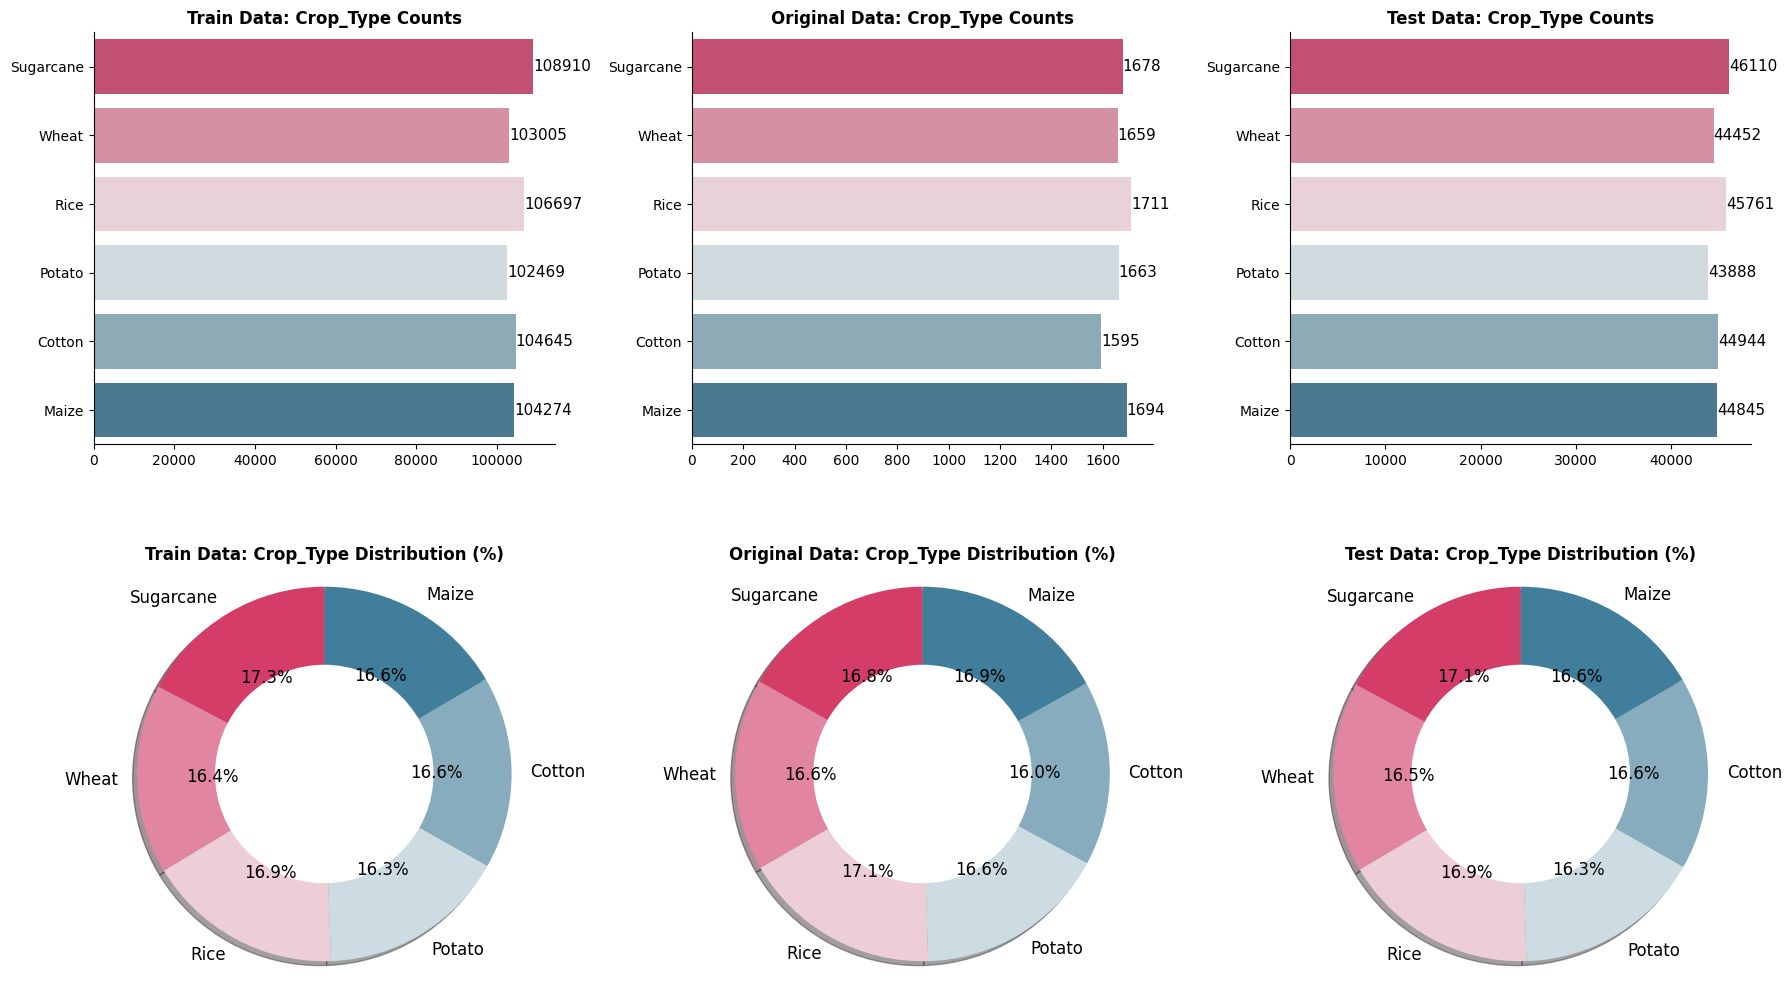

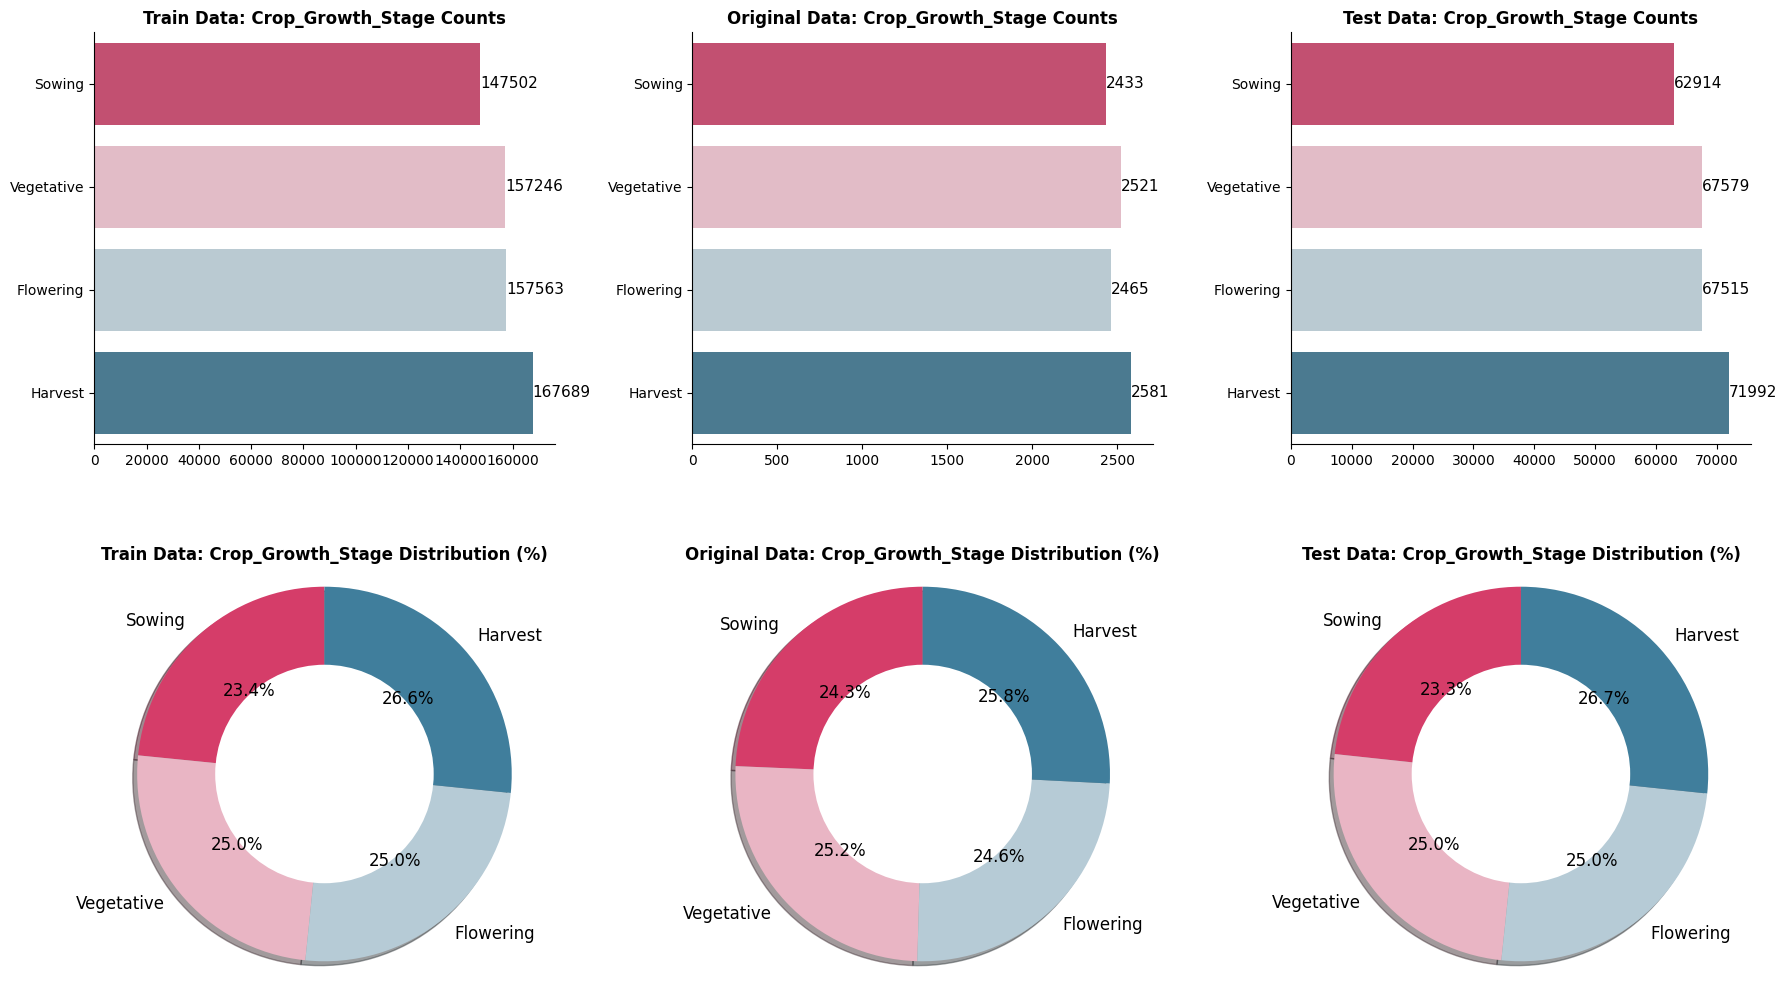

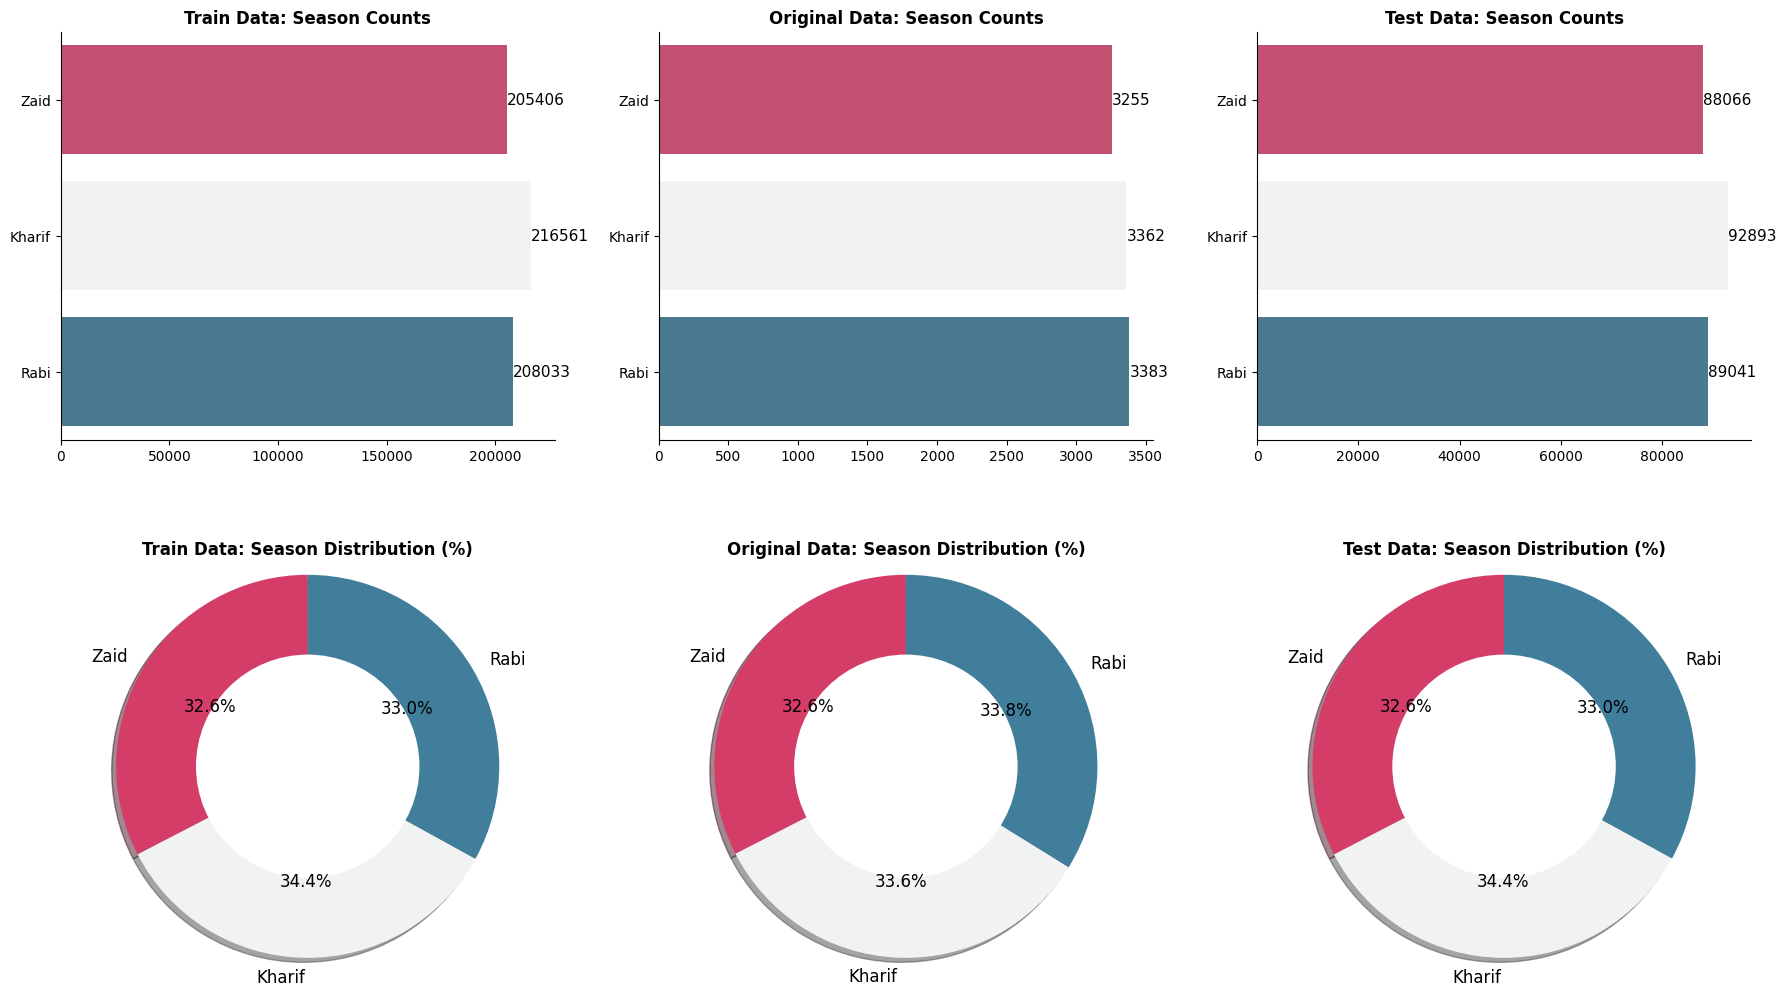

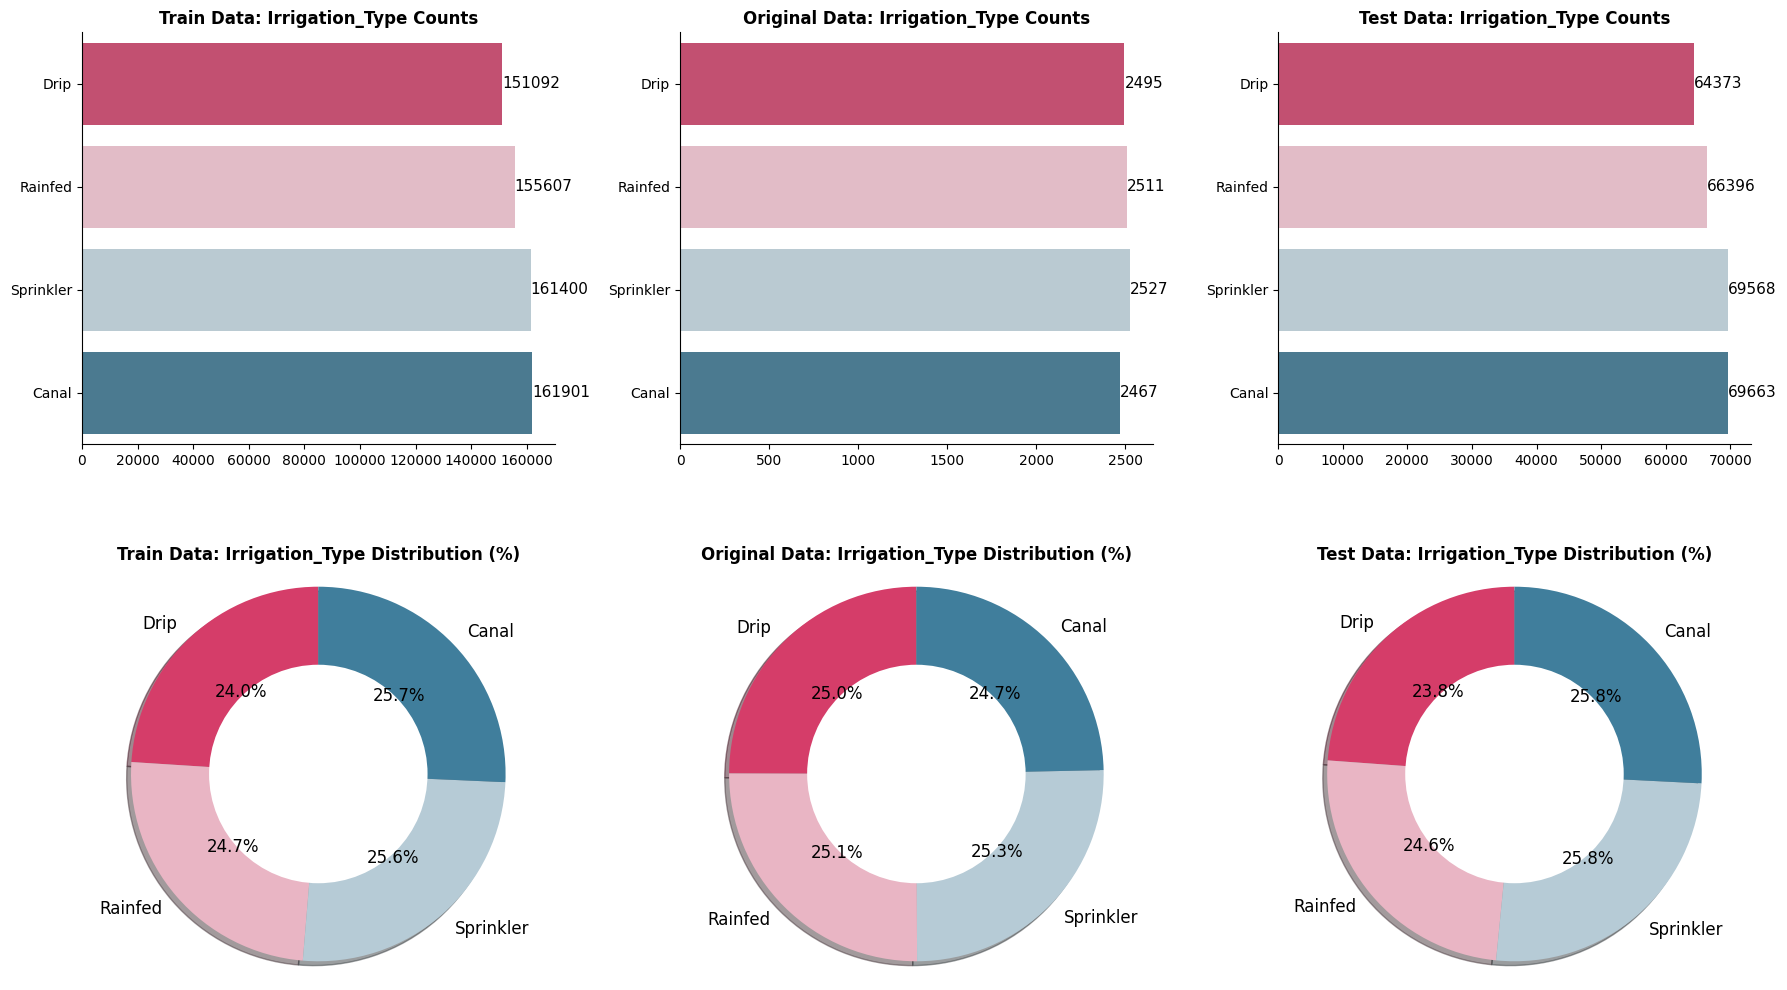

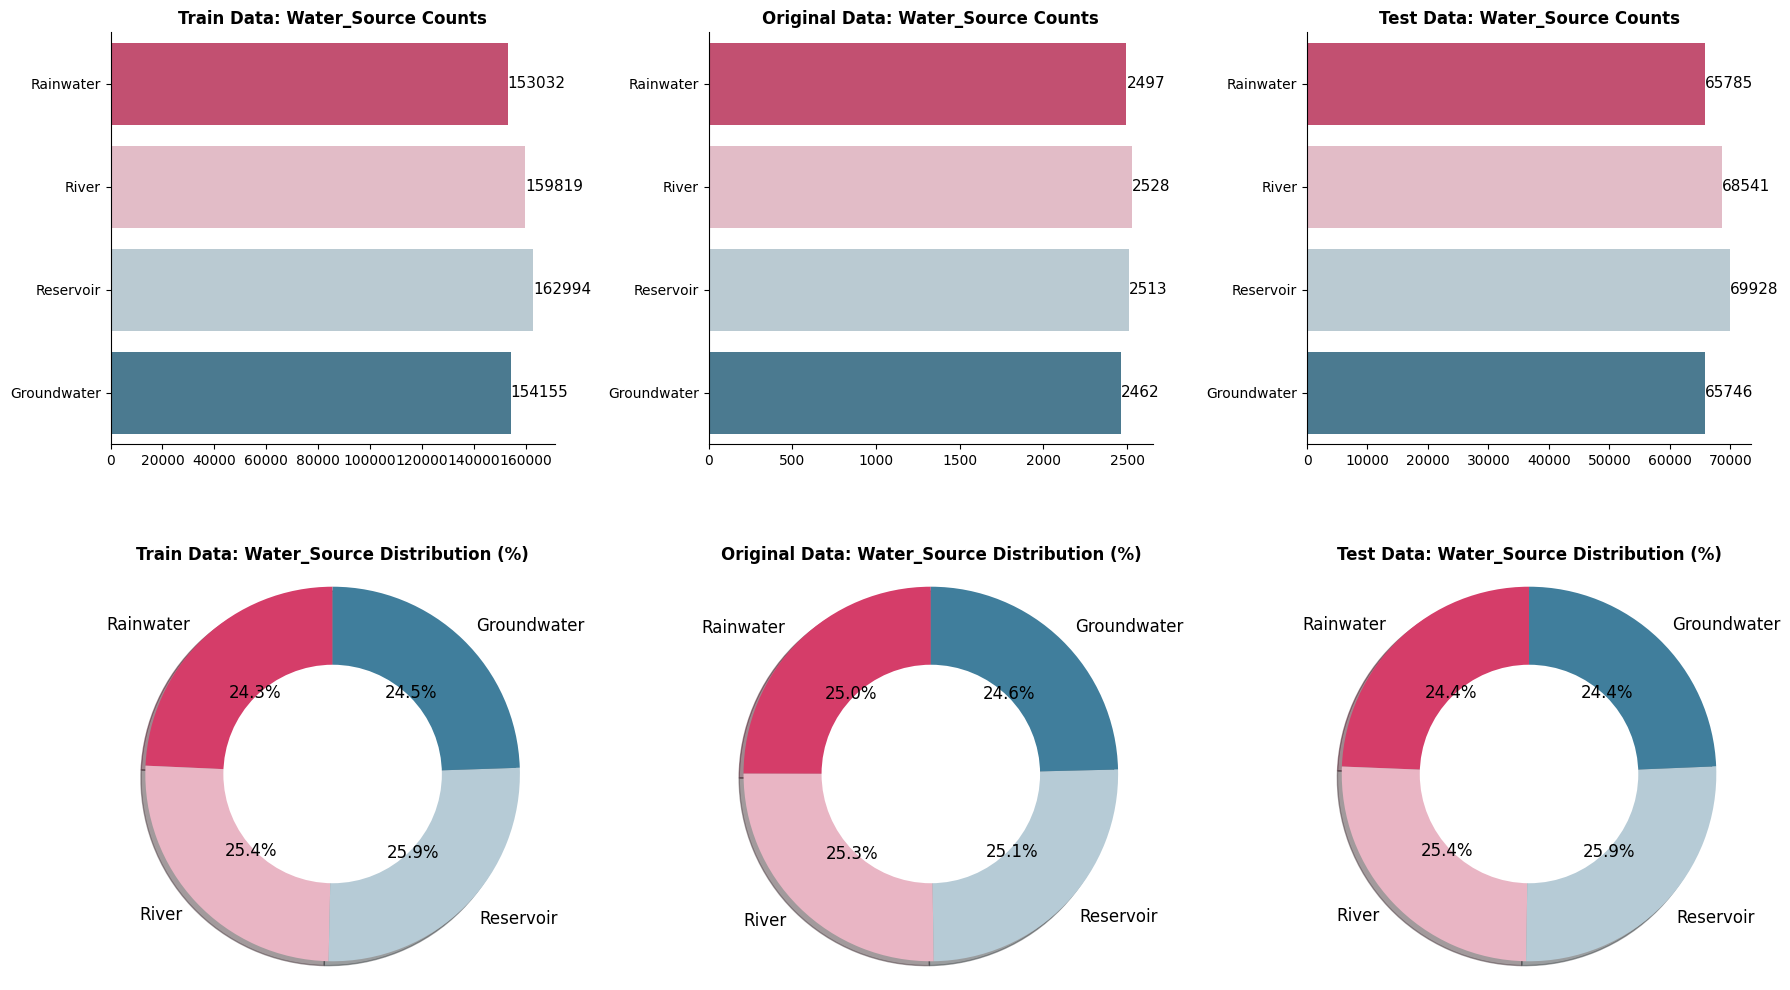

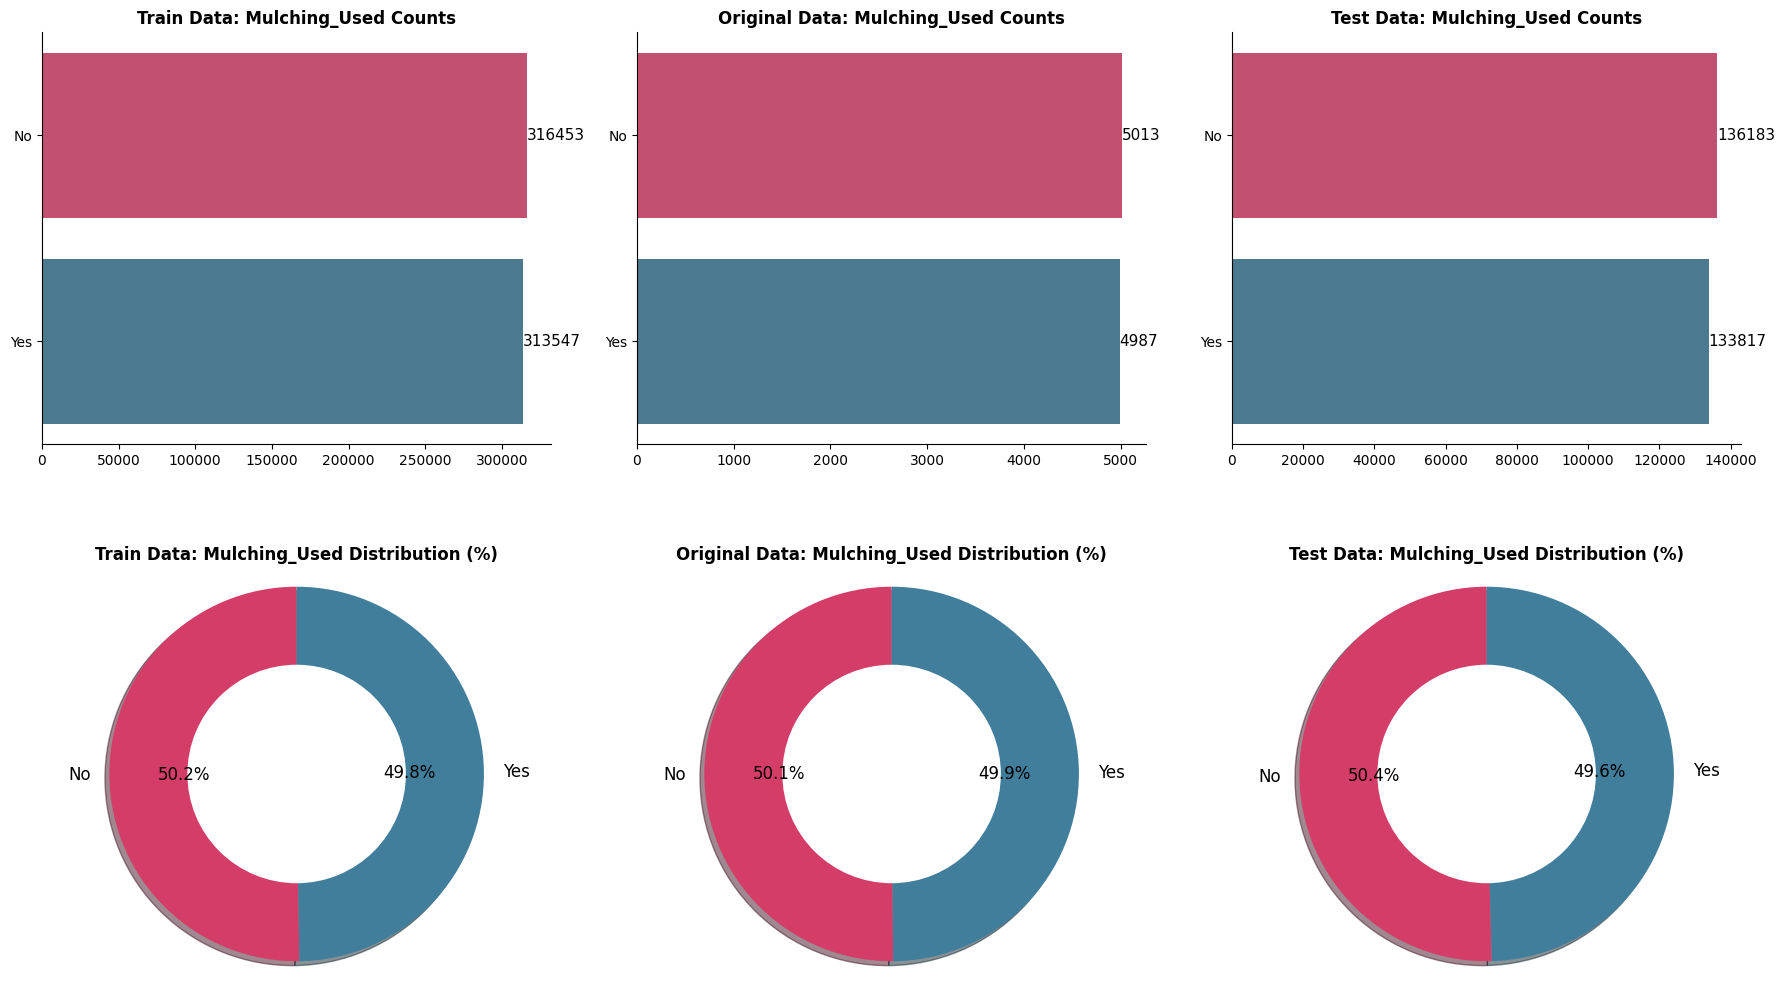

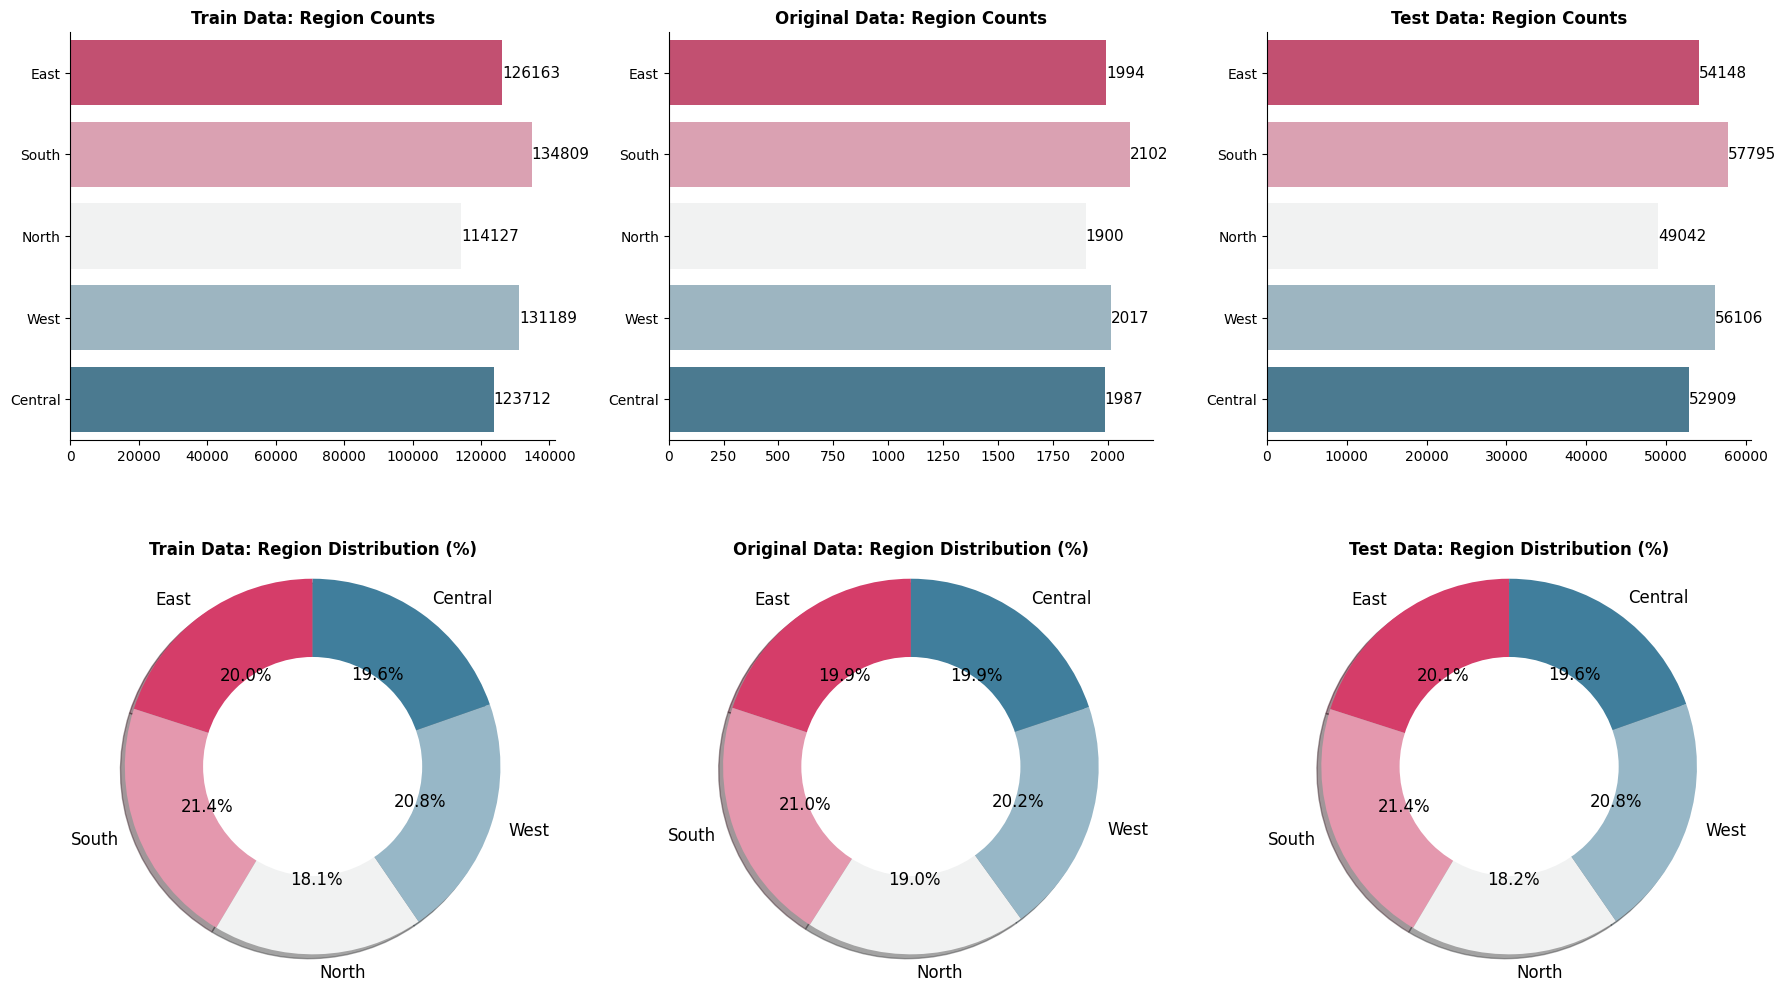

In [18]:
def plot_categorical_distribution_across_datasets(train_data: pd.DataFrame, original_data: pd.DataFrame, 
                                                  test_data: pd.DataFrame, feature: str) -> None:
    """
    Plot categorical feature distribution across Train, Original, and Test datasets.

    This function generates:
    1. Count plots (absolute frequency)
    2. Donut pie charts (percentage distribution)

    Parameters
    ----------
    train_data : pd.DataFrame
        Training dataset.
    original_data : pd.DataFrame
        Original/raw dataset.
    test_data : pd.DataFrame
        Test dataset.
    feature : str
        Categorical column name to analyze.

    Notes
    -----
    - Category order is fixed based on the Train dataset to ensure consistency.
    - Pie chart percentages are aligned with the same category order.
    - Useful for checking distribution drift across datasets.
    """

    # Define consistent color palette based on number of categories
    colors = color(n_colors=df_train[feature].nunique())

    # Dataset labels and list
    dataset_names = ["Train", "Original", "Test"]
    datasets = [train_data, original_data, test_data]

    # Fix category order using Train data to ensure consistent plotting
    order = df_train[feature].unique().tolist()

    # Create 2x3 subplot grid:
    # Row 1 → Count plots
    # Row 2 → Percentage donut charts
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Count Plots
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        sns.countplot(y=feature, data=data, ax=ax[0, i], palette=colors, order=order)
        ax[0, i].set_title(f"{name} Data: {feature.title()} Counts", fontsize=12, weight="bold")
        ax[0, i].set_xlabel("")
        ax[0, i].set_ylabel("")
        
        for p in ax[0, i].patches:
            ax[0, i].annotate(f"{int(p.get_width())}", 
                               (p.get_width(), p.get_y() + p.get_height() / 2), 
                               ha="left", va="center", 
                               color="black", fontsize=11)
        ax[0, i].set_axisbelow(True)
        sns.despine(ax=ax[0, i])

    # Row 2: Donut Pie Charts
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        counts = data[feature].value_counts().reindex(order)
        wedges, texts, autotexts = ax[1, i].pie(
            counts, labels=order, autopct="%1.1f%%", startangle=90, colors=colors,
            textprops={"fontsize": 12}, radius=1.2,  shadow=True)

        # Create donut hole
        centre_circle = plt.Circle((0, 0), 0.70, fc="white")
        ax[1, i].add_artist(centre_circle)
        ax[1, i].set_title(f"{name} Data: {feature.title()} Distribution (%)", fontsize=12, weight="bold")
        ax[1, i].axis("equal")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)  
    plt.show()

# Apply function to all categorical features
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_original, df_test, feature)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Consistency in Categorical Feature Distributions
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>The <b>count plots and percentage distribution charts</b> of categorical variables across the 
<b>Train</b>, <b>Test</b>, and <b>Original</b> datasets demonstrate a <b>high degree of consistency</b>.</li>

<li>No noticeable signs of <b>distributional shift</b> or <b>sampling bias</b> are observed across datasets.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The categorical feature distributions are well-aligned across datasets, reinforcing the reliability of downstream modeling and validation processes.
</div>

</div>

## Bivariate Analysis

,Irrigation_Need,Count,Mean,Median,Std
0,High,21009,6.578282,6.590000,0.978948
1,Low,369917,6.487805,6.460000,0.916681
2,Medium,239074,6.465867,6.400000,0.925763


2026-04-07 13:00:11 | INFO     | Checking normality of feature 'Soil_pH' by groups of 'Irrigation_Need'...
2026-04-07 13:00:11 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:11 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:11 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:11 | DEBUG    | [Irrigation_Need=High] skew=-0.0846, kurtosis=-1.3412 → Approximately symmetric, Normal tails
2026-04-07 13:00:11 | DEBUG    | [Irrigation_Need=Low] skew=0.0467, kurtosis=-1.1340 → Approximately symmetric, Normal tails
2026-04-07 13:00:11 | DEBUG    | [Irrigation_Need=Medium] skew=0.1172, kurtosis=-1.1355 → Approximately symmetric, Normal tails
2026-04-07 13:00:11 | INFO     | Generating Q–Q plots for visual assessment...


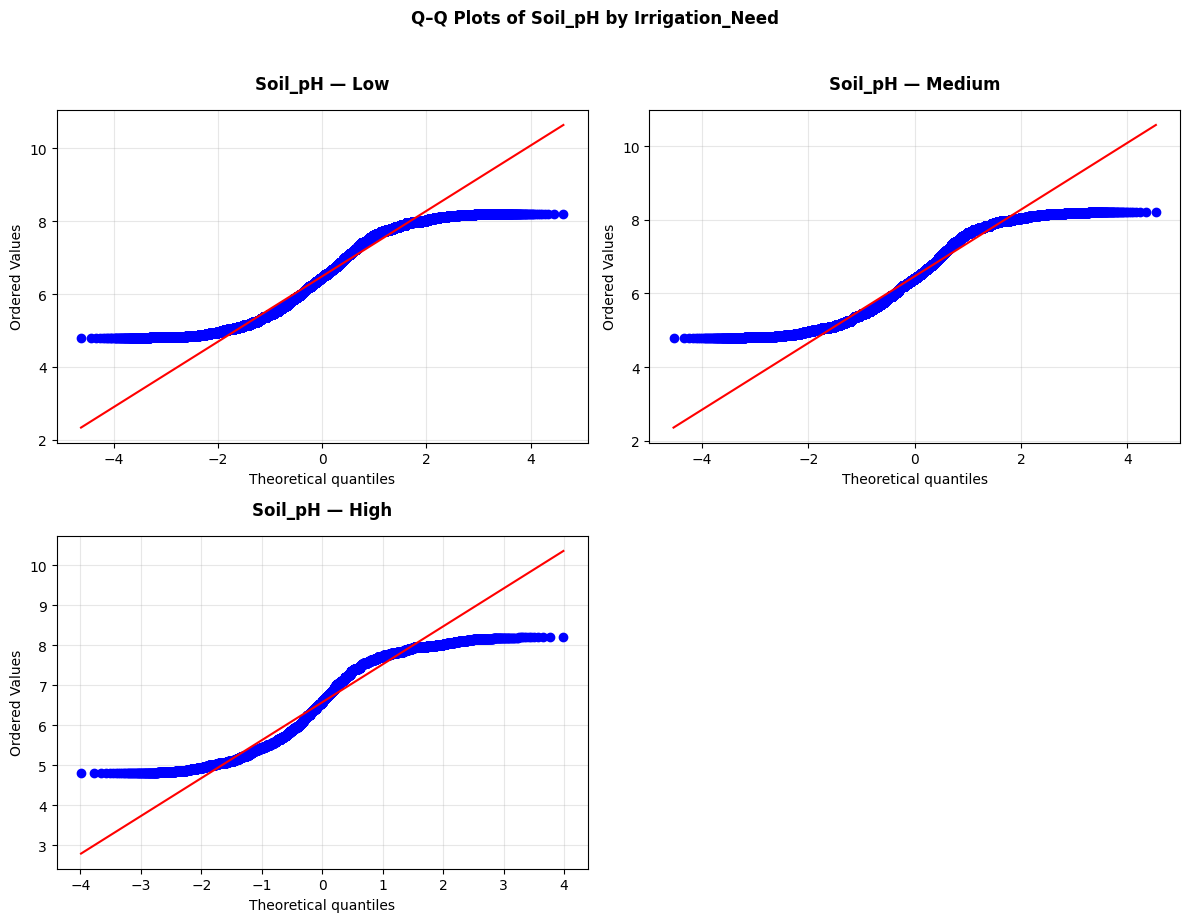

,Feature,Group,Skewness,Kurtosis,Remark
0,Soil_pH,High,-0.0846,-1.3412,"Approximately symmetric, Normal tails"
1,Soil_pH,Low,0.0467,-1.1340,"Approximately symmetric, Normal tails"
2,Soil_pH,Medium,0.1172,-1.1355,"Approximately symmetric, Normal tails"


2026-04-07 13:00:13 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:13 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:13 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,300.1343
1,p-value,0.000000
2,Max/Min Variance Ratio,1.14


2026-04-07 13:00:13 | INFO     | Interpretation:
2026-04-07 13:00:13 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:13 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:13 | INFO     | Running Welch’s ANOVA Test: Soil_pH ~ Irrigation_Need
2026-04-07 13:00:13 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:13 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:13 | INFO     | Welch ANOVA F-statistic: 145.3100
2026-04-07 13:00:13 | INFO     | p-value: 0.000000
2026-04-07 13:00:13 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2          F         p-unc       np2
0  Irrigation_Need      2  56860.327214  145.31002  1.130804e-63  0.000502
2026-04-07 13:00:13 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:13 | INFO     | Conclusion: Significant mean differen

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,6.5783,6.4878,0.0905,0.0069,13.0746,23149.1788,0.0000,0.0983
1,High,Medium,6.5783,6.4659,0.1124,0.0070,16.0265,24426.4210,0.0000,0.1209
2,Low,Medium,6.4878,6.4659,0.0219,0.0024,9.0651,506591.7448,0.0000,0.0238


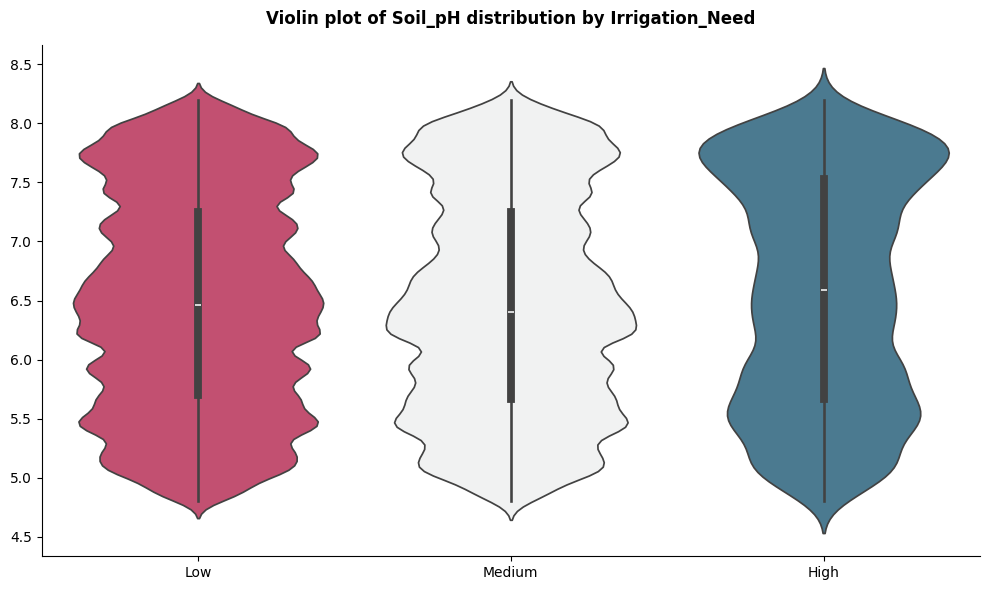

,Irrigation_Need,Count,Mean,Median,Std
0,Low,369917,43.305902,44.010000,13.421279
1,Medium,239074,29.743961,23.890000,16.624592
2,High,21009,17.669875,17.090000,7.479613


2026-04-07 13:00:16 | INFO     | Checking normality of feature 'Soil_Moisture' by groups of 'Irrigation_Need'...
2026-04-07 13:00:16 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:16 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:16 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:17 | DEBUG    | [Irrigation_Need=High] skew=2.4218, kurtosis=10.9127 → Highly skewed, Heavy/light tails
2026-04-07 13:00:17 | DEBUG    | [Irrigation_Need=Low] skew=-0.3263, kurtosis=-0.6385 → Approximately symmetric, Normal tails
2026-04-07 13:00:17 | DEBUG    | [Irrigation_Need=Medium] skew=0.5873, kurtosis=-0.9632 → Moderately skewed, Normal tails
2026-04-07 13:00:17 | INFO     | Generating Q–Q plots for visual assessment...


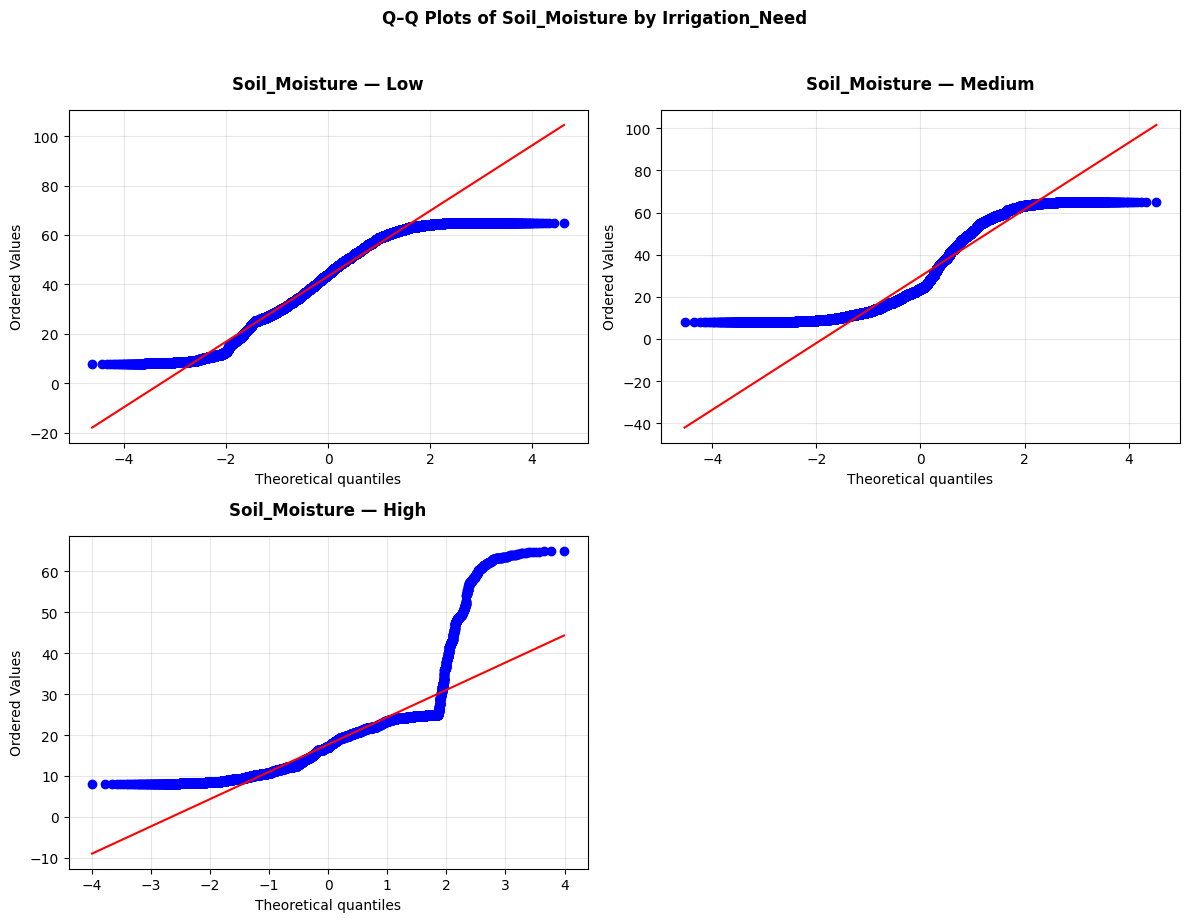

,Feature,Group,Skewness,Kurtosis,Remark
0,Soil_Moisture,High,2.4218,10.9127,"Highly skewed, Heavy/light tails"
1,Soil_Moisture,Low,-0.3263,-0.6385,"Approximately symmetric, Normal tails"
2,Soil_Moisture,Medium,0.5873,-0.9632,"Moderately skewed, Normal tails"


2026-04-07 13:00:18 | WARNING  | Normality assumption violated in at least one group.
2026-04-07 13:00:18 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-04-07 13:00:19 | INFO     | Kruskal-Wallis Test: Soil_Moisture ~ Irrigation_Need...
2026-04-07 13:00:19 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:19 | INFO     | Kruskal-Wallis H-statistic: 127598.781
2026-04-07 13:00:19 | INFO     | p-value: 0.0
2026-04-07 13:00:19 | INFO     | Significant difference detected among groups (p < 0.05).
2026-04-07 13:00:19 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
        High  Low  Medium
High     1.0  0.0     0.0
Low      0.0  1.0     0.0
Medium   0.0  0.0     1.0


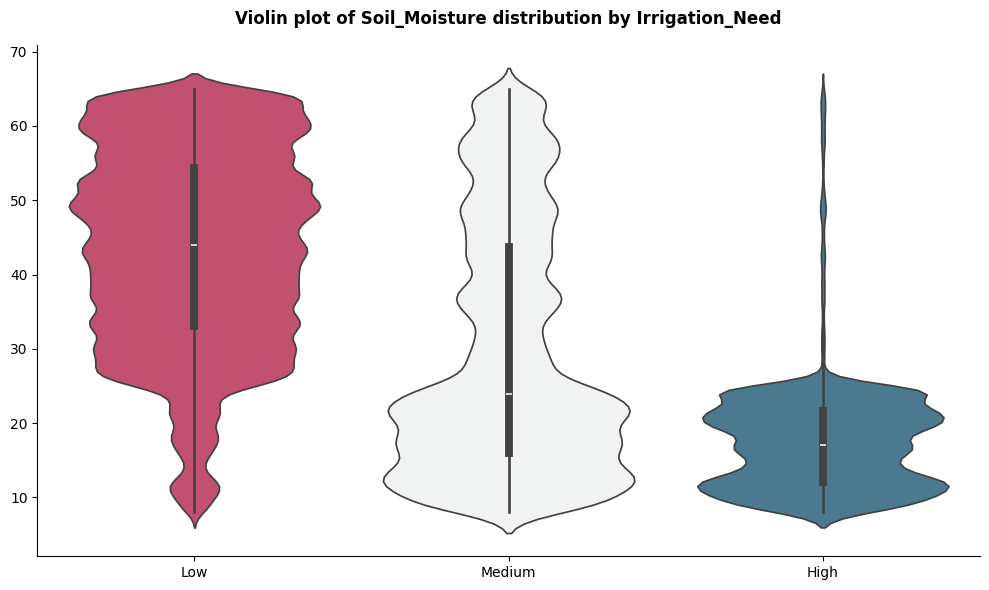

,Irrigation_Need,Count,Mean,Median,Std
0,Medium,239074,0.926116,0.930000,0.364882
1,High,21009,0.924143,0.910000,0.373870
2,Low,369917,0.920680,0.900000,0.365927


2026-04-07 13:00:23 | INFO     | Checking normality of feature 'Organic_Carbon' by groups of 'Irrigation_Need'...
2026-04-07 13:00:23 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:23 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:23 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:23 | DEBUG    | [Irrigation_Need=High] skew=0.0524, kurtosis=-1.2544 → Approximately symmetric, Normal tails
2026-04-07 13:00:23 | DEBUG    | [Irrigation_Need=Low] skew=0.1341, kurtosis=-1.1565 → Approximately symmetric, Normal tails
2026-04-07 13:00:23 | DEBUG    | [Irrigation_Need=Medium] skew=0.0648, kurtosis=-1.1692 → Approximately symmetric, Normal tails
2026-04-07 13:00:23 | INFO     | Generating Q–Q plots for visual assessment...


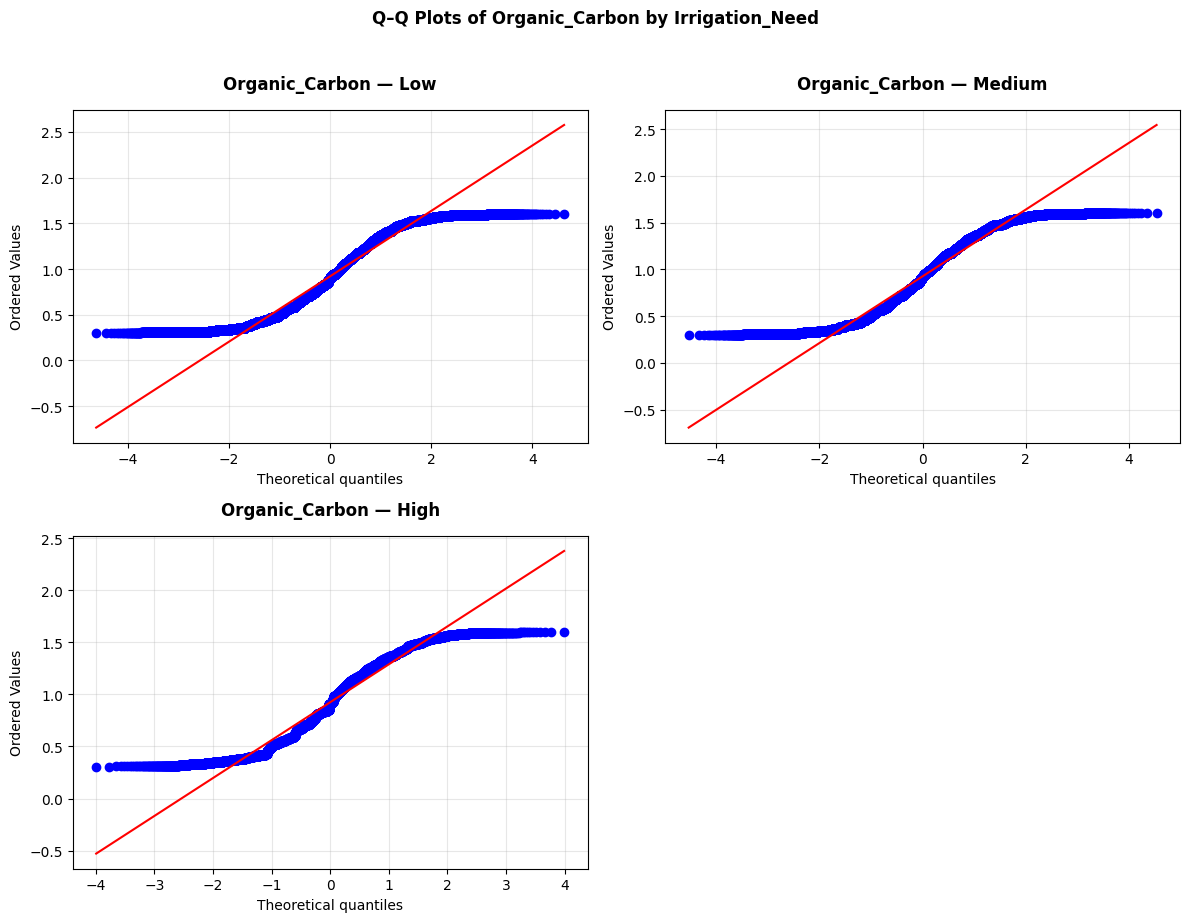

,Feature,Group,Skewness,Kurtosis,Remark
0,Organic_Carbon,High,0.0524,-1.2544,"Approximately symmetric, Normal tails"
1,Organic_Carbon,Low,0.1341,-1.1565,"Approximately symmetric, Normal tails"
2,Organic_Carbon,Medium,0.0648,-1.1692,"Approximately symmetric, Normal tails"


2026-04-07 13:00:25 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:25 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:25 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,49.0577
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05


2026-04-07 13:00:25 | INFO     | Interpretation:
2026-04-07 13:00:25 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:25 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:25 | INFO     | Running Welch’s ANOVA Test: Organic_Carbon ~ Irrigation_Need
2026-04-07 13:00:25 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:25 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:25 | INFO     | Welch ANOVA F-statistic: 16.2052
2026-04-07 13:00:25 | INFO     | p-value: 0.000000
2026-04-07 13:00:25 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2          F         p-unc       np2
0  Irrigation_Need      2  57135.072474  16.205209  9.207945e-08  0.000051
2026-04-07 13:00:25 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:25 | INFO     | Conclusion: Significant mean di

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,0.9241,0.9207,0.0035,0.0026,1.3076,23352.1974,0.3909,0.0095
1,High,Medium,0.9241,0.9261,-0.0020,0.0027,-0.7346,24656.8391,0.7429,-0.0054
2,Low,Medium,0.9207,0.9261,-0.0054,0.0010,-5.6707,511269.7230,0.0000,-0.0149


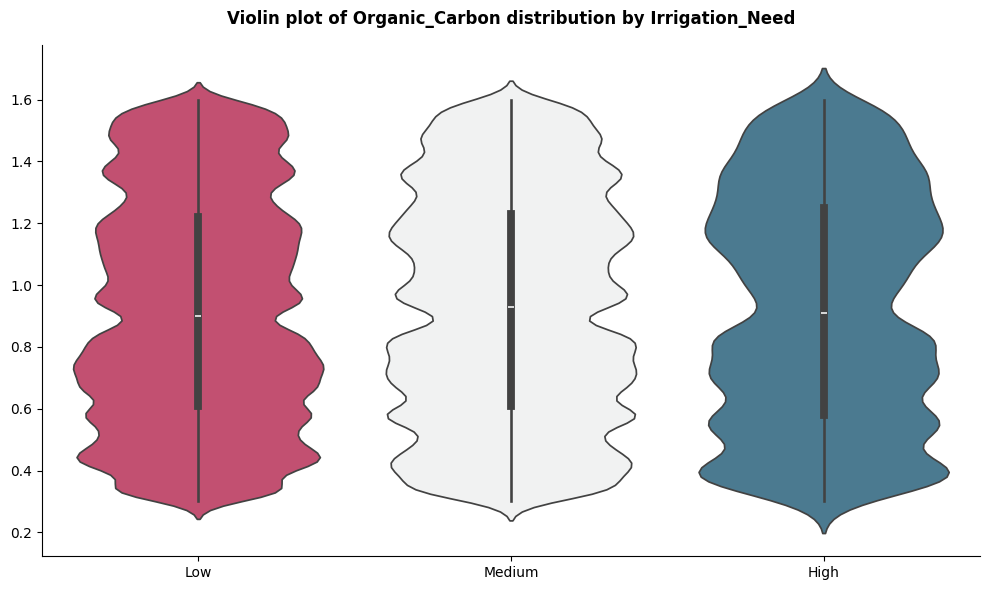

,Irrigation_Need,Count,Mean,Median,Std
0,Medium,239074,1.769208,1.760000,0.942780
1,Low,369917,1.731755,1.720000,0.961384
2,High,21009,1.690880,1.650000,0.891465


2026-04-07 13:00:28 | INFO     | Checking normality of feature 'Electrical_Conductivity' by groups of 'Irrigation_Need'...
2026-04-07 13:00:28 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:29 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:29 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:29 | DEBUG    | [Irrigation_Need=High] skew=0.2237, kurtosis=-1.0254 → Approximately symmetric, Normal tails
2026-04-07 13:00:29 | DEBUG    | [Irrigation_Need=Low] skew=0.0668, kurtosis=-1.1615 → Approximately symmetric, Normal tails
2026-04-07 13:00:29 | DEBUG    | [Irrigation_Need=Medium] skew=0.0053, kurtosis=-1.1307 → Approximately symmetric, Normal tails
2026-04-07 13:00:29 | INFO     | Generating Q–Q plots for visual assessment...


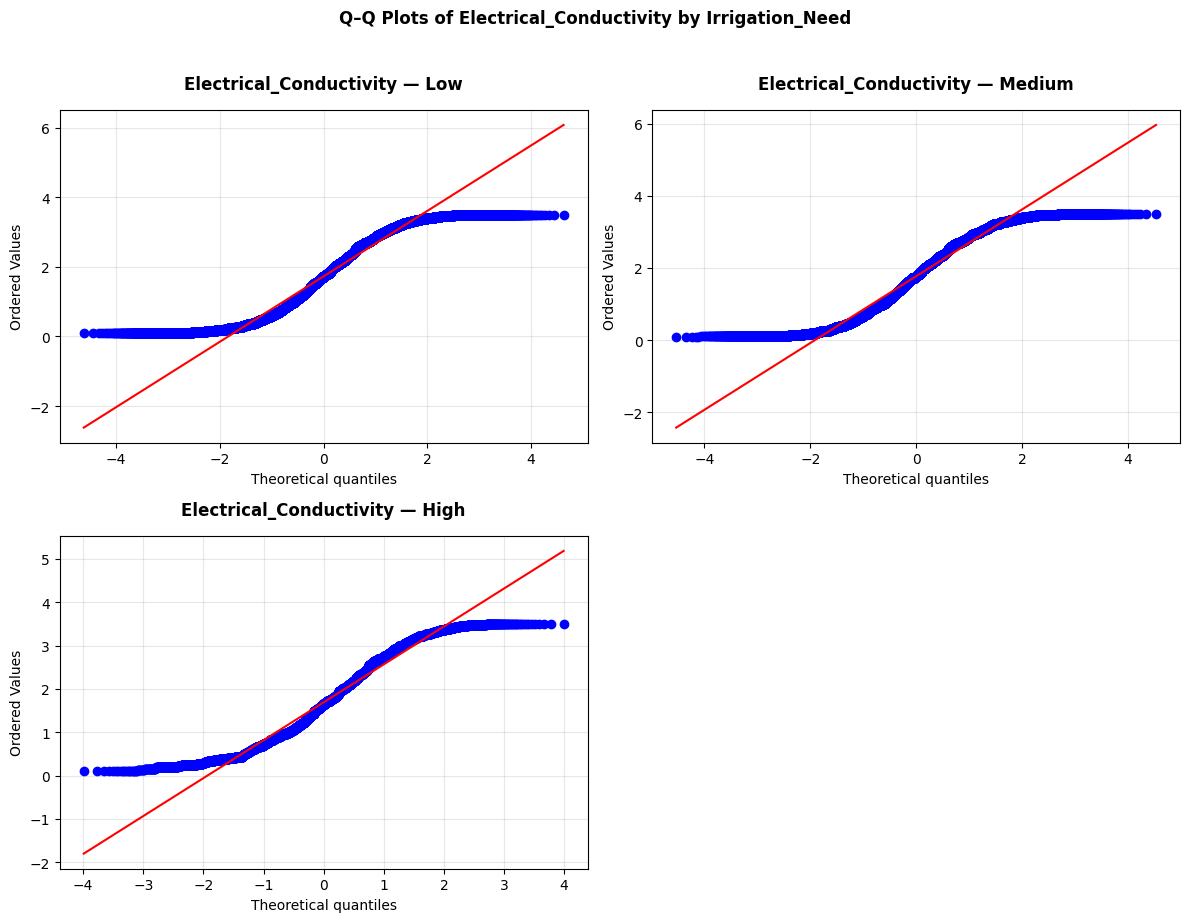

,Feature,Group,Skewness,Kurtosis,Remark
0,Electrical_Conductivity,High,0.2237,-1.0254,"Approximately symmetric, Normal tails"
1,Electrical_Conductivity,Low,0.0668,-1.1615,"Approximately symmetric, Normal tails"
2,Electrical_Conductivity,Medium,0.0053,-1.1307,"Approximately symmetric, Normal tails"


2026-04-07 13:00:31 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:31 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:31 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,260.1328
1,p-value,0.000000
2,Max/Min Variance Ratio,1.16


2026-04-07 13:00:31 | INFO     | Interpretation:
2026-04-07 13:00:31 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:31 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:31 | INFO     | Running Welch’s ANOVA Test: Electrical_Conductivity ~ Irrigation_Need
2026-04-07 13:00:31 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:31 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:31 | INFO     | Welch ANOVA F-statistic: 152.5975
2026-04-07 13:00:31 | INFO     | p-value: 0.000000
2026-04-07 13:00:31 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2           F         p-unc       np2
0  Irrigation_Need      2  57829.209002  152.597533  7.979898e-67  0.000466
2026-04-07 13:00:31 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:31 | INFO     | Conclusion: Signifi

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,1.6909,1.7318,-0.0409,0.0064,-6.4367,23868.9830,0.0000,-0.0427
1,High,Medium,1.6909,1.7692,-0.0783,0.0064,-12.1522,25318.9636,0.0000,-0.0834
2,Low,Medium,1.7318,1.7692,-0.0375,0.0025,-15.0216,517369.4592,0.0000,-0.0393


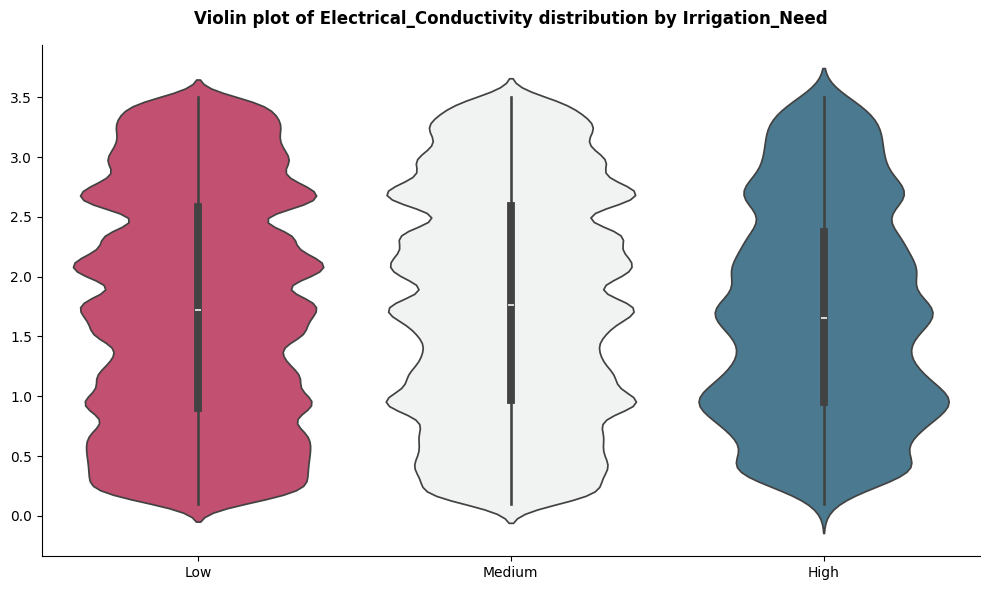

,Irrigation_Need,Count,Mean,Median,Std
0,High,21009,34.568134,34.910000,5.420716
1,Medium,239074,28.886683,30.660000,8.503269
2,Low,369917,25.347708,24.540000,8.364835


2026-04-07 13:00:34 | INFO     | Checking normality of feature 'Temperature_C' by groups of 'Irrigation_Need'...
2026-04-07 13:00:34 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:34 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:34 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:35 | DEBUG    | [Irrigation_Need=High] skew=-1.4361, kurtosis=3.0550 → Highly skewed, Heavy/light tails
2026-04-07 13:00:35 | DEBUG    | [Irrigation_Need=Low] skew=0.2495, kurtosis=-1.0326 → Approximately symmetric, Normal tails
2026-04-07 13:00:35 | DEBUG    | [Irrigation_Need=Medium] skew=-0.2962, kurtosis=-1.1376 → Approximately symmetric, Normal tails
2026-04-07 13:00:35 | INFO     | Generating Q–Q plots for visual assessment...


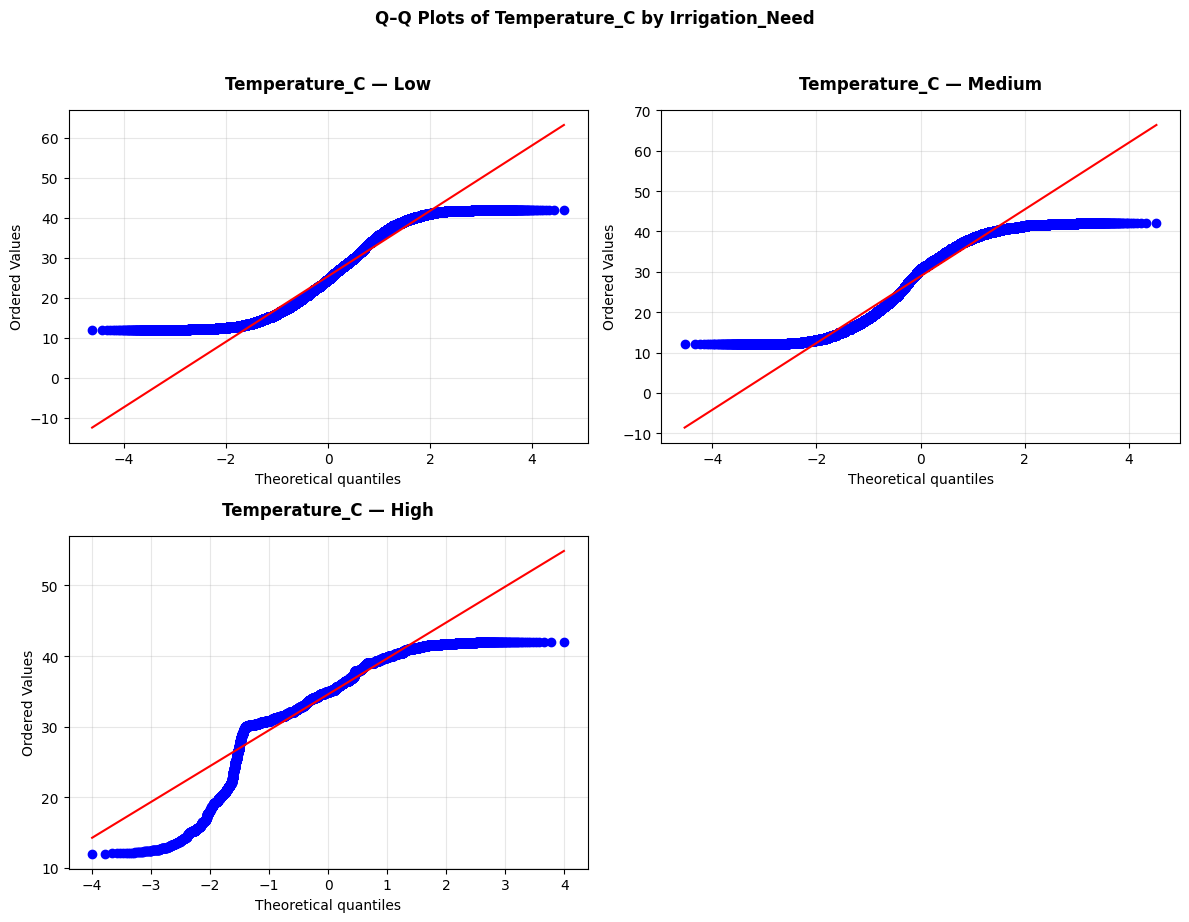

,Feature,Group,Skewness,Kurtosis,Remark
0,Temperature_C,High,-1.4361,3.0550,"Highly skewed, Heavy/light tails"
1,Temperature_C,Low,0.2495,-1.0326,"Approximately symmetric, Normal tails"
2,Temperature_C,Medium,-0.2962,-1.1376,"Approximately symmetric, Normal tails"


2026-04-07 13:00:37 | WARNING  | Normality assumption violated in at least one group.
2026-04-07 13:00:37 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-04-07 13:00:37 | INFO     | Kruskal-Wallis Test: Temperature_C ~ Irrigation_Need...
2026-04-07 13:00:37 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:37 | INFO     | Kruskal-Wallis H-statistic: 41038.110
2026-04-07 13:00:37 | INFO     | p-value: 0.0
2026-04-07 13:00:37 | INFO     | Significant difference detected among groups (p < 0.05).
2026-04-07 13:00:37 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
        High  Low  Medium
High     1.0  0.0     0.0
Low      0.0  1.0     0.0
Medium   0.0  0.0     1.0


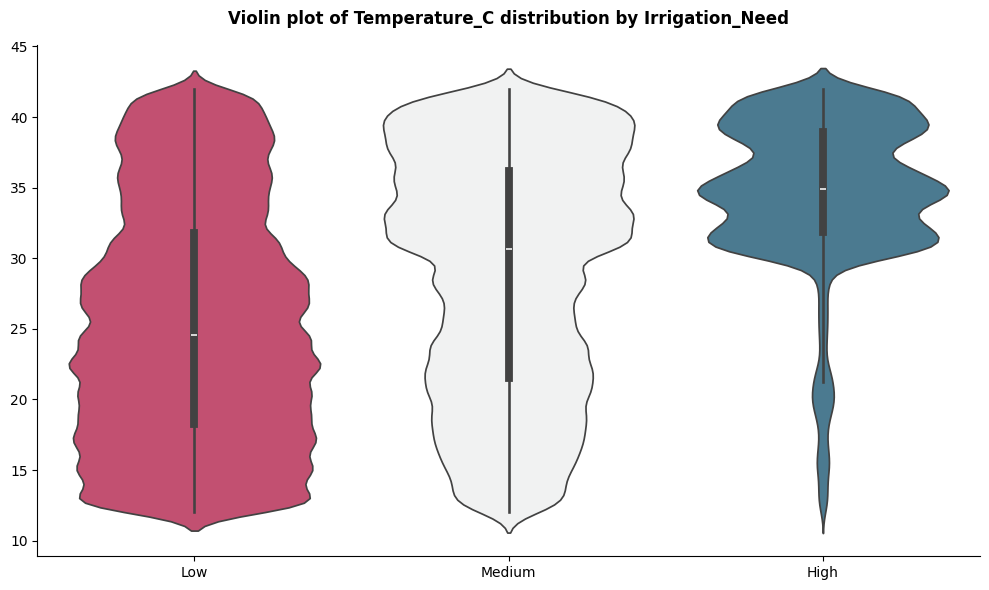

,Irrigation_Need,Count,Mean,Median,Std
0,Low,369917,61.949194,61.770000,19.913072
1,High,21009,61.119576,62.850000,19.242509
2,Medium,239074,61.004887,61.440000,19.413552


2026-04-07 13:00:41 | INFO     | Checking normality of feature 'Humidity' by groups of 'Irrigation_Need'...
2026-04-07 13:00:41 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:41 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:41 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:41 | DEBUG    | [Irrigation_Need=High] skew=-0.2513, kurtosis=-0.9559 → Approximately symmetric, Normal tails
2026-04-07 13:00:41 | DEBUG    | [Irrigation_Need=Low] skew=-0.0820, kurtosis=-1.2148 → Approximately symmetric, Normal tails
2026-04-07 13:00:41 | DEBUG    | [Irrigation_Need=Medium] skew=-0.0914, kurtosis=-1.1044 → Approximately symmetric, Normal tails
2026-04-07 13:00:41 | INFO     | Generating Q–Q plots for visual assessment...


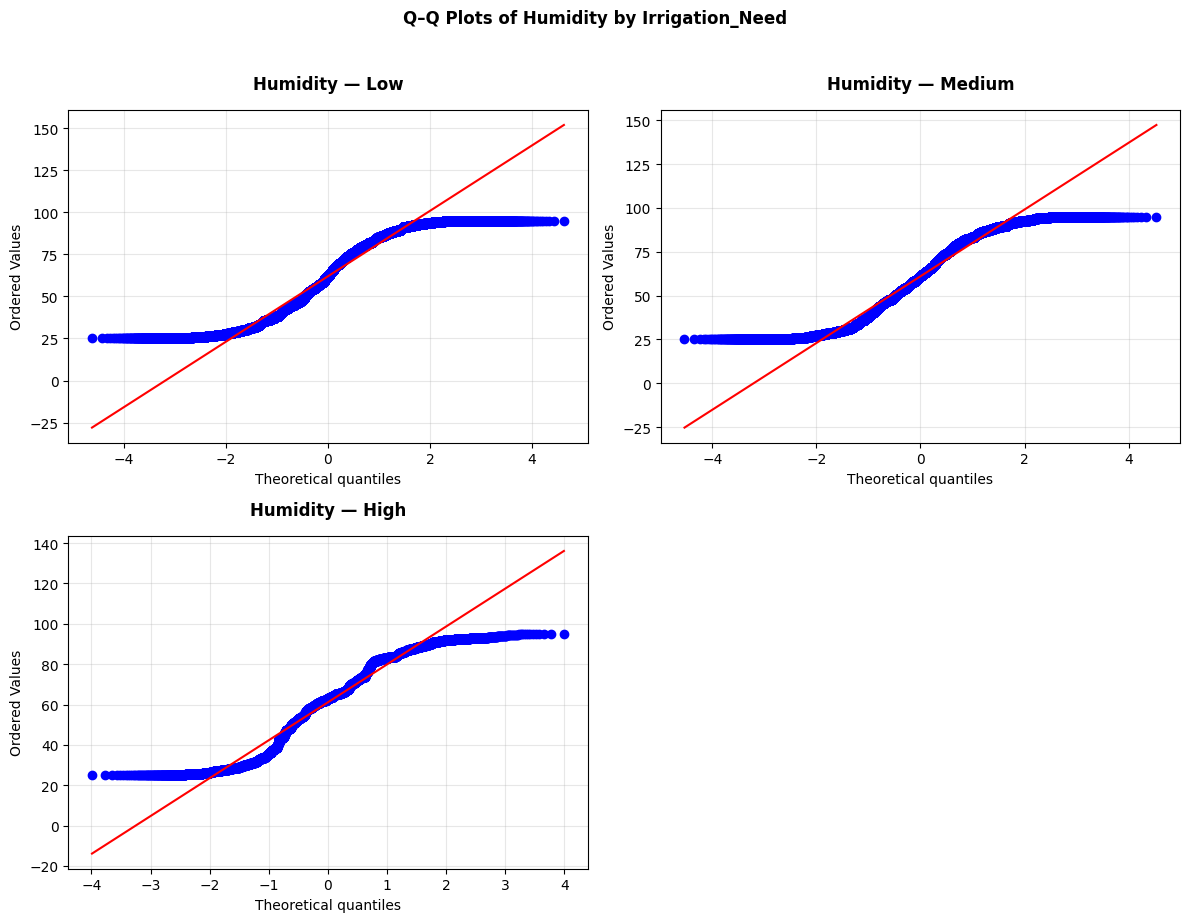

,Feature,Group,Skewness,Kurtosis,Remark
0,Humidity,High,-0.2513,-0.9559,"Approximately symmetric, Normal tails"
1,Humidity,Low,-0.0820,-1.2148,"Approximately symmetric, Normal tails"
2,Humidity,Medium,-0.0914,-1.1044,"Approximately symmetric, Normal tails"


2026-04-07 13:00:43 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:43 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:43 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,708.6145
1,p-value,0.000000
2,Max/Min Variance Ratio,1.07


2026-04-07 13:00:43 | INFO     | Interpretation:
2026-04-07 13:00:43 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:43 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:43 | INFO     | Running Welch’s ANOVA Test: Humidity ~ Irrigation_Need
2026-04-07 13:00:43 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:43 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:44 | INFO     | Welch ANOVA F-statistic: 173.8292
2026-04-07 13:00:44 | INFO     | p-value: 0.000000
2026-04-07 13:00:44 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2           F         p-unc       np2
0  Irrigation_Need      2  57501.429154  173.829245  5.422768e-76  0.000547
2026-04-07 13:00:44 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:44 | INFO     | Conclusion: Significant mean diffe

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,61.1196,61.9492,-0.8296,0.1367,-6.0673,23636.2064,0.0000,-0.0417
1,High,Medium,61.1196,61.0049,0.1147,0.1386,0.8277,24916.7105,0.6858,0.0059
2,Low,Medium,61.9492,61.0049,0.9443,0.0515,18.3494,519501.6452,0.0000,0.0479


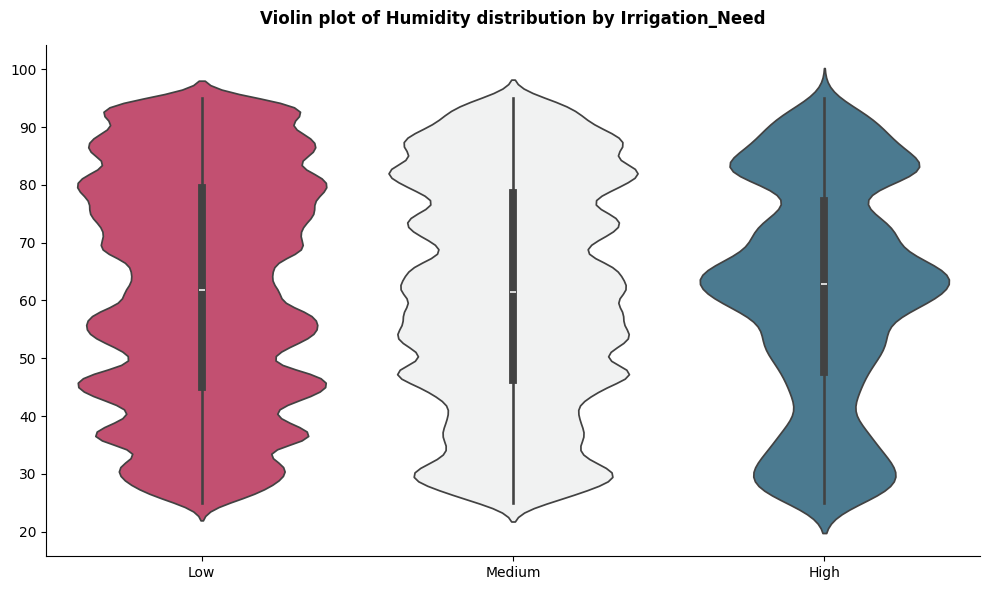

,Irrigation_Need,Count,Mean,Median,Std
0,Low,369917,1500.534313,1498.880000,584.804731
1,Medium,239074,1444.475028,1463.590000,618.449689
2,High,21009,989.156678,764.950000,800.312437


2026-04-07 13:00:47 | INFO     | Checking normality of feature 'Rainfall_mm' by groups of 'Irrigation_Need'...
2026-04-07 13:00:47 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:47 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:47 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:47 | DEBUG    | [Irrigation_Need=High] skew=0.3487, kurtosis=-1.3059 → Approximately symmetric, Normal tails
2026-04-07 13:00:47 | DEBUG    | [Irrigation_Need=Low] skew=-0.0385, kurtosis=-1.1330 → Approximately symmetric, Normal tails
2026-04-07 13:00:47 | DEBUG    | [Irrigation_Need=Medium] skew=-0.1122, kurtosis=-0.8696 → Approximately symmetric, Normal tails
2026-04-07 13:00:47 | INFO     | Generating Q–Q plots for visual assessment...


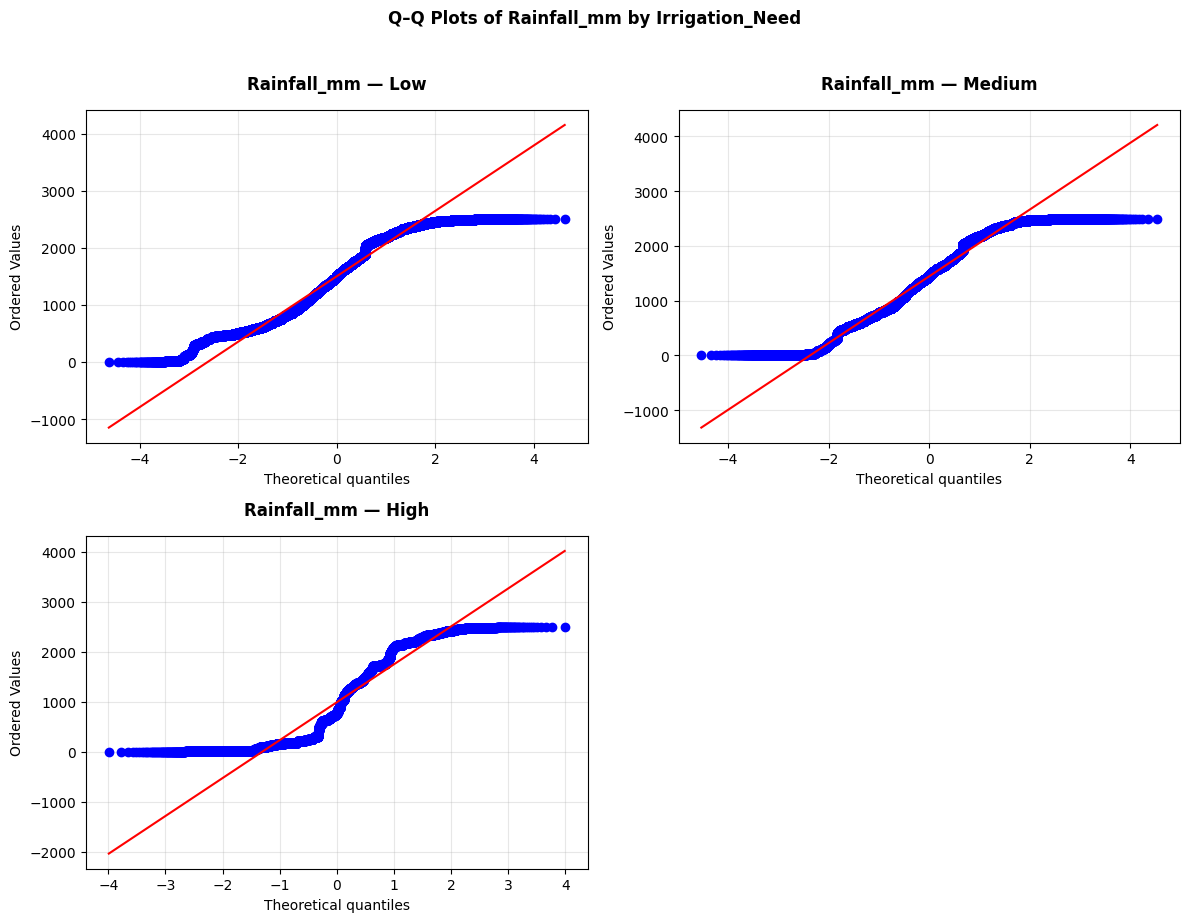

,Feature,Group,Skewness,Kurtosis,Remark
0,Rainfall_mm,High,0.3487,-1.3059,"Approximately symmetric, Normal tails"
1,Rainfall_mm,Low,-0.0385,-1.1330,"Approximately symmetric, Normal tails"
2,Rainfall_mm,Medium,-0.1122,-0.8696,"Approximately symmetric, Normal tails"


2026-04-07 13:00:49 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:49 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:49 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,4293.2409
1,p-value,0.000000
2,Max/Min Variance Ratio,1.87


2026-04-07 13:00:49 | INFO     | Interpretation:
2026-04-07 13:00:49 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:49 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:49 | INFO     | Running Welch’s ANOVA Test: Rainfall_mm ~ Irrigation_Need
2026-04-07 13:00:49 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:49 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:49 | INFO     | Welch ANOVA F-statistic: 4499.2693
2026-04-07 13:00:49 | INFO     | p-value: 0.000000
2026-04-07 13:00:49 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2            F  p-unc       np2
0  Irrigation_Need      2  55641.140907  4499.269272    0.0  0.022473
2026-04-07 13:00:49 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:49 | INFO     | Conclusion: Significant mean differences d

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,989.1567,1500.5343,-511.3776,5.6046,-91.2426,22300.2984,0.0000,-0.8546
1,High,Medium,989.1567,1444.4750,-455.3183,5.6645,-80.3808,23265.0626,0.0000,-0.7169
2,Low,Medium,1500.5343,1444.4750,56.0593,1.5888,35.2835,489562.9135,0.0000,0.0937


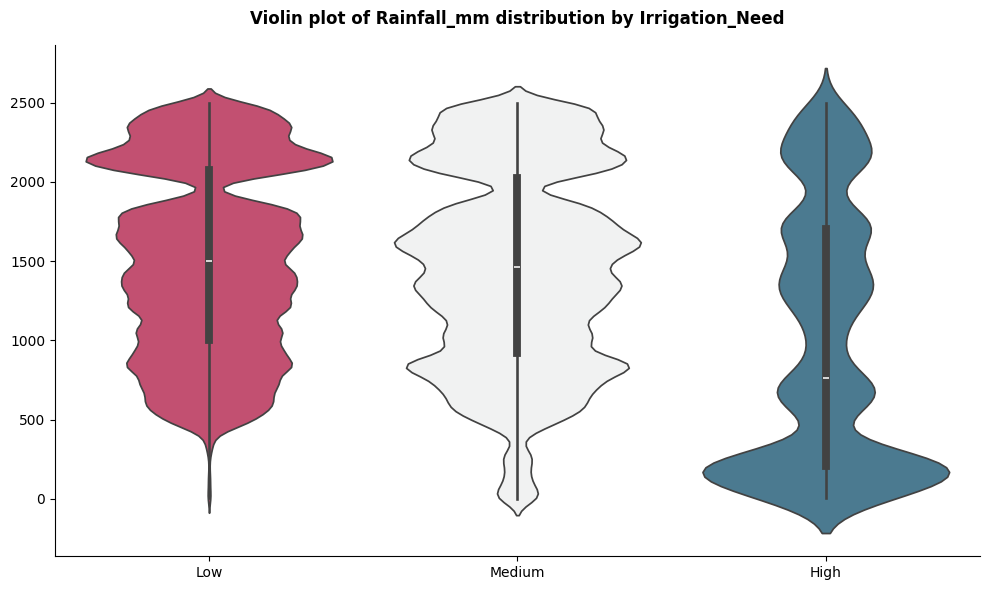

,Irrigation_Need,Count,Mean,Median,Std
0,Medium,239074,7.521290,7.610000,1.995064
1,Low,369917,7.511125,7.580000,2.000223
2,High,21009,7.463138,7.480000,2.030893


2026-04-07 13:00:52 | INFO     | Checking normality of feature 'Sunlight_Hours' by groups of 'Irrigation_Need'...
2026-04-07 13:00:52 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:52 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:52 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:53 | DEBUG    | [Irrigation_Need=High] skew=0.1376, kurtosis=-1.1998 → Approximately symmetric, Normal tails
2026-04-07 13:00:53 | DEBUG    | [Irrigation_Need=Low] skew=-0.0423, kurtosis=-1.2197 → Approximately symmetric, Normal tails
2026-04-07 13:00:53 | DEBUG    | [Irrigation_Need=Medium] skew=-0.0391, kurtosis=-1.1842 → Approximately symmetric, Normal tails
2026-04-07 13:00:53 | INFO     | Generating Q–Q plots for visual assessment...


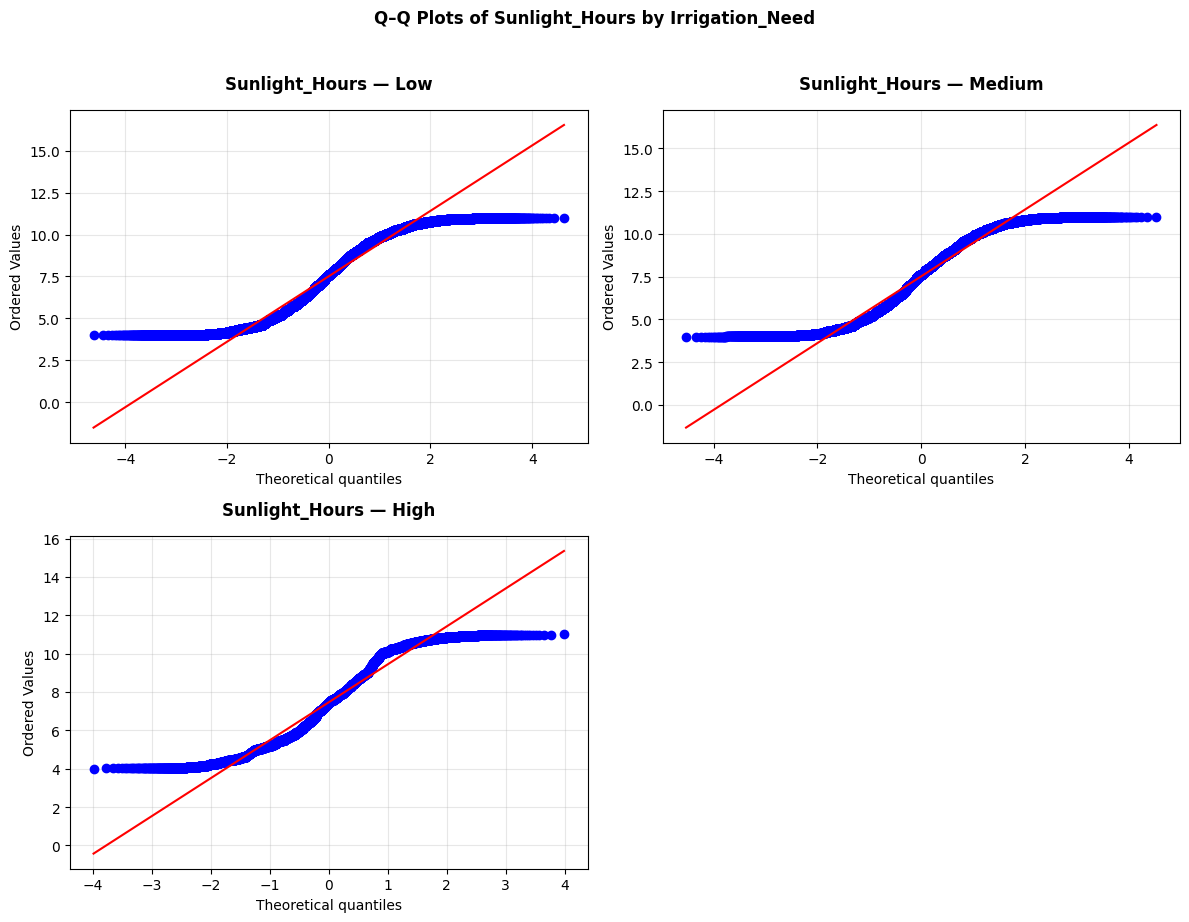

,Feature,Group,Skewness,Kurtosis,Remark
0,Sunlight_Hours,High,0.1376,-1.1998,"Approximately symmetric, Normal tails"
1,Sunlight_Hours,Low,-0.0423,-1.2197,"Approximately symmetric, Normal tails"
2,Sunlight_Hours,Medium,-0.0391,-1.1842,"Approximately symmetric, Normal tails"


2026-04-07 13:00:54 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:00:55 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:00:55 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,18.4865
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04


2026-04-07 13:00:55 | INFO     | Interpretation:
2026-04-07 13:00:55 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:00:55 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:00:55 | INFO     | Running Welch’s ANOVA Test: Sunlight_Hours ~ Irrigation_Need
2026-04-07 13:00:55 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:55 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:00:55 | INFO     | Welch ANOVA F-statistic: 8.5427
2026-04-07 13:00:55 | INFO     | p-value: 0.000195
2026-04-07 13:00:55 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2         F     p-unc       np2
0  Irrigation_Need      2  57177.638647  8.542731  0.000195  0.000028
2026-04-07 13:00:55 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:00:55 | INFO     | Conclusion: Significant mean differences d

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,7.4631,7.5111,-0.0480,0.0144,-3.3342,23382.4494,0.0025,-0.0240
1,High,Medium,7.4631,7.5213,-0.0582,0.0146,-3.9848,24706.5600,0.0002,-0.0291
2,Low,Medium,7.5111,7.5213,-0.0102,0.0052,-1.9397,511167.7962,0.1276,-0.0051


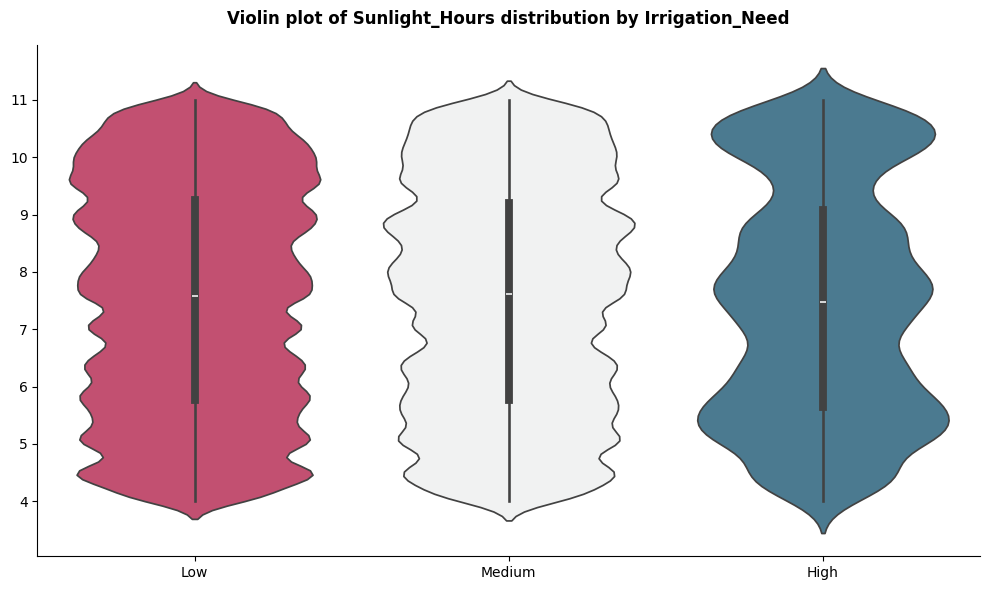

,Irrigation_Need,Count,Mean,Median,Std
0,High,21009,14.642639,15.010000,4.118403
1,Medium,239074,11.793668,12.520000,5.388586
2,Low,369917,9.216424,8.420000,5.632220


2026-04-07 13:00:58 | INFO     | Checking normality of feature 'Wind_Speed_kmh' by groups of 'Irrigation_Need'...
2026-04-07 13:00:58 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:00:58 | DEBUG    | Number of groups detected: 3
2026-04-07 13:00:58 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:00:58 | DEBUG    | [Irrigation_Need=High] skew=-1.0225, kurtosis=1.1783 → Highly skewed, Normal tails
2026-04-07 13:00:58 | DEBUG    | [Irrigation_Need=Low] skew=0.2806, kurtosis=-1.1639 → Approximately symmetric, Normal tails
2026-04-07 13:00:58 | DEBUG    | [Irrigation_Need=Medium] skew=-0.4090, kurtosis=-0.8968 → Approximately symmetric, Normal tails
2026-04-07 13:00:58 | INFO     | Generating Q–Q plots for visual assessment...


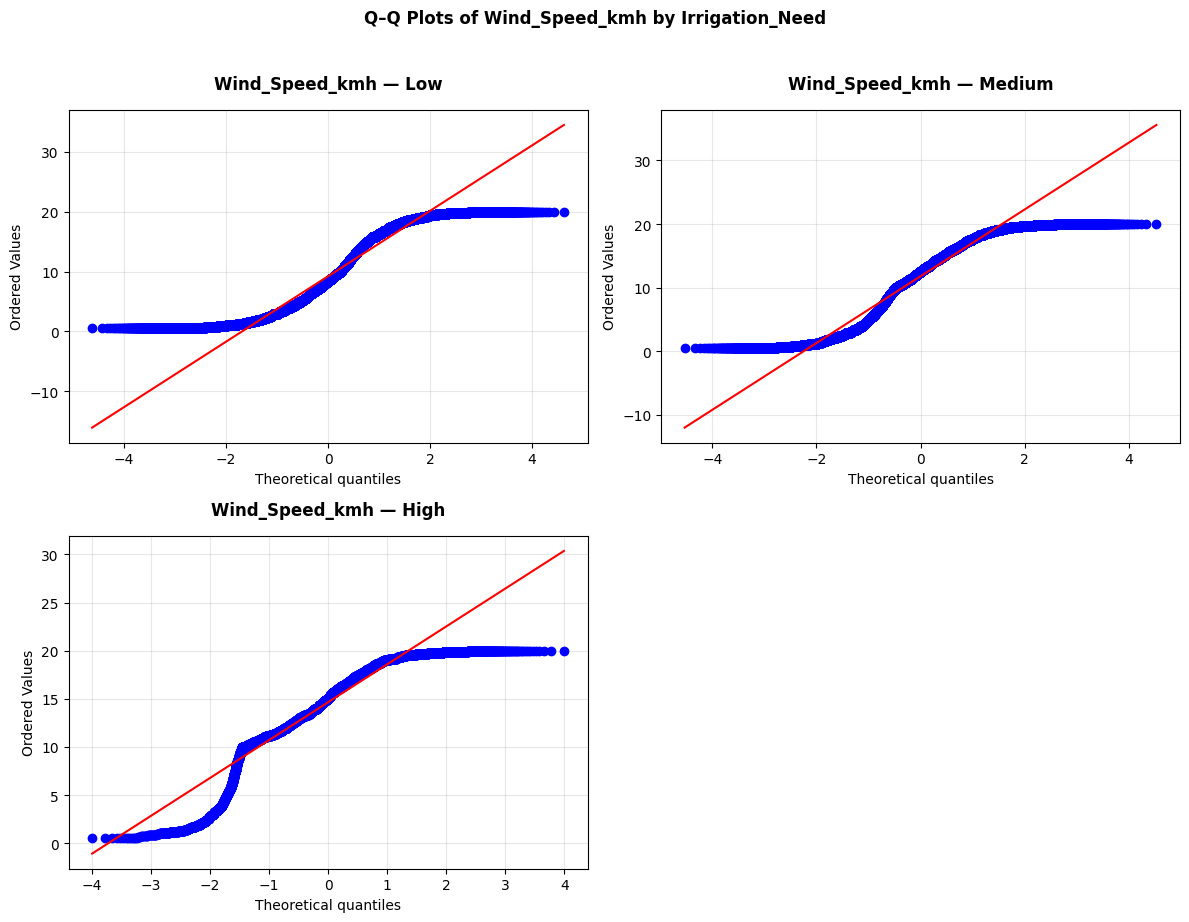

,Feature,Group,Skewness,Kurtosis,Remark
0,Wind_Speed_kmh,High,-1.0225,1.1783,"Highly skewed, Normal tails"
1,Wind_Speed_kmh,Low,0.2806,-1.1639,"Approximately symmetric, Normal tails"
2,Wind_Speed_kmh,Medium,-0.4090,-0.8968,"Approximately symmetric, Normal tails"


2026-04-07 13:01:00 | WARNING  | Normality assumption violated in at least one group.
2026-04-07 13:01:00 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-04-07 13:01:00 | INFO     | Kruskal-Wallis Test: Wind_Speed_kmh ~ Irrigation_Need...
2026-04-07 13:01:00 | DEBUG    | Number of groups detected: 3
2026-04-07 13:01:01 | INFO     | Kruskal-Wallis H-statistic: 41600.360
2026-04-07 13:01:01 | INFO     | p-value: 0.0
2026-04-07 13:01:01 | INFO     | Significant difference detected among groups (p < 0.05).
2026-04-07 13:01:01 | DEBUG    | Running Dunn's Post-Hoc Test (Bonferroni corrected)...
        High  Low  Medium
High     1.0  0.0     0.0
Low      0.0  1.0     0.0
Medium   0.0  0.0     1.0


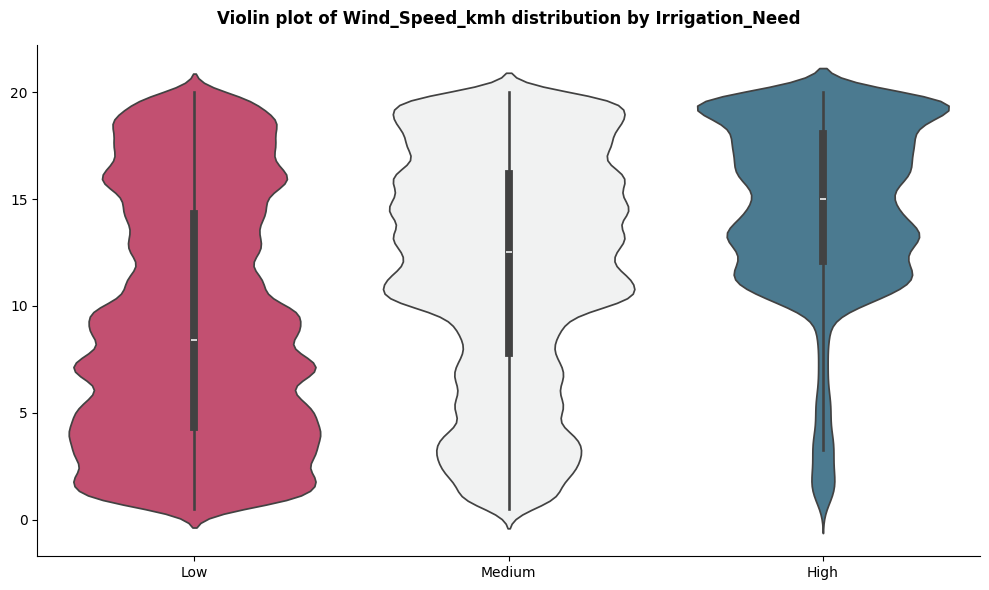

,Irrigation_Need,Count,Mean,Median,Std
0,Medium,239074,7.625725,7.560000,4.224577
1,High,21009,7.530391,7.490000,4.476655
2,Low,369917,7.447241,7.250000,4.197295


2026-04-07 13:01:04 | INFO     | Checking normality of feature 'Field_Area_hectare' by groups of 'Irrigation_Need'...
2026-04-07 13:01:04 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:01:04 | DEBUG    | Number of groups detected: 3
2026-04-07 13:01:04 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:01:04 | DEBUG    | [Irrigation_Need=High] skew=0.0389, kurtosis=-1.3276 → Approximately symmetric, Normal tails
2026-04-07 13:01:04 | DEBUG    | [Irrigation_Need=Low] skew=0.0798, kurtosis=-1.1548 → Approximately symmetric, Normal tails
2026-04-07 13:01:04 | DEBUG    | [Irrigation_Need=Medium] skew=0.0106, kurtosis=-1.1898 → Approximately symmetric, Normal tails
2026-04-07 13:01:04 | INFO     | Generating Q–Q plots for visual assessment...


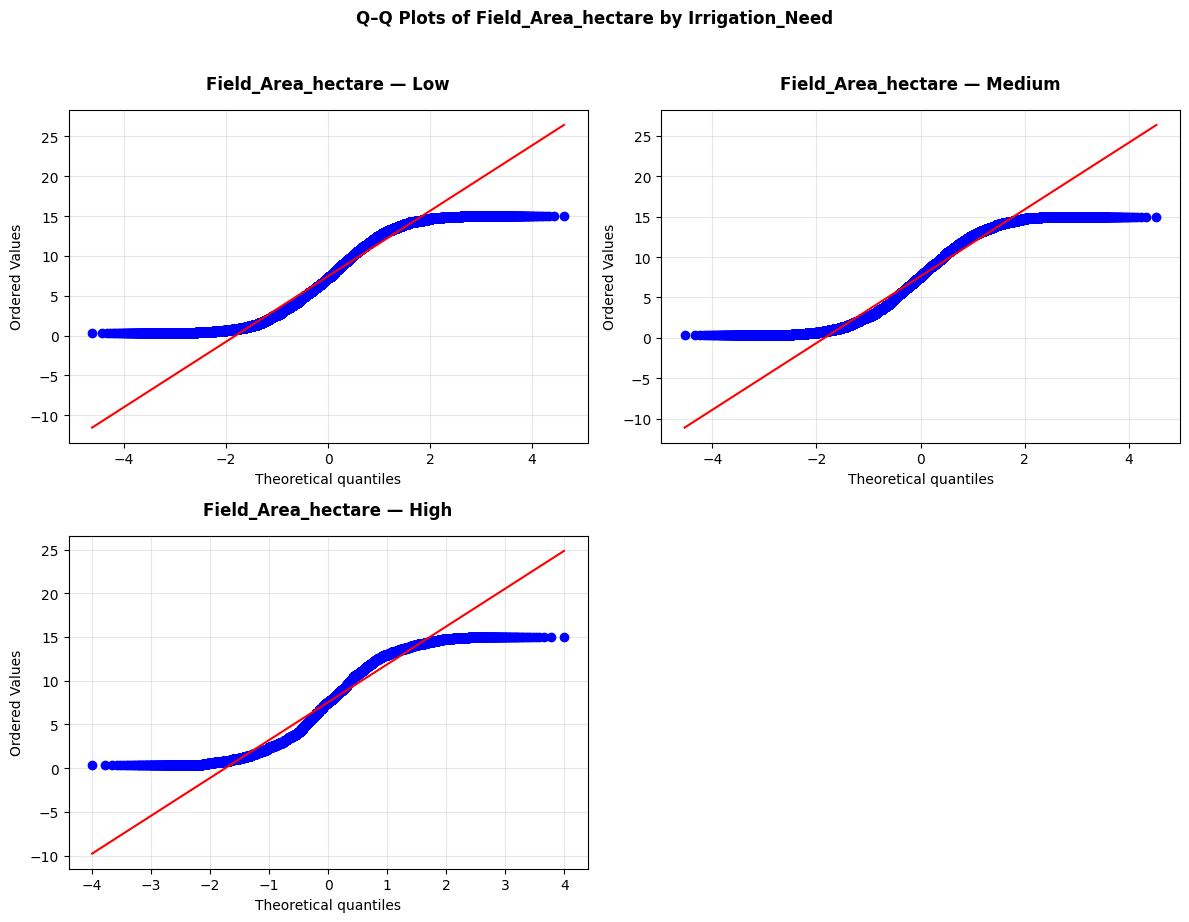

,Feature,Group,Skewness,Kurtosis,Remark
0,Field_Area_hectare,High,0.0389,-1.3276,"Approximately symmetric, Normal tails"
1,Field_Area_hectare,Low,0.0798,-1.1548,"Approximately symmetric, Normal tails"
2,Field_Area_hectare,Medium,0.0106,-1.1898,"Approximately symmetric, Normal tails"


2026-04-07 13:01:06 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:01:06 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:01:06 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,226.4748
1,p-value,0.000000
2,Max/Min Variance Ratio,1.14


2026-04-07 13:01:06 | INFO     | Interpretation:
2026-04-07 13:01:06 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:01:06 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:01:07 | INFO     | Running Welch’s ANOVA Test: Field_Area_hectare ~ Irrigation_Need
2026-04-07 13:01:07 | DEBUG    | Number of groups detected: 3
2026-04-07 13:01:07 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:01:07 | INFO     | Welch ANOVA F-statistic: 130.3587
2026-04-07 13:01:07 | INFO     | p-value: 0.000000
2026-04-07 13:01:07 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2           F         p-unc       np2
0  Irrigation_Need      2  56865.830974  130.358712  3.275796e-57  0.000413
2026-04-07 13:01:07 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:01:07 | INFO     | Conclusion: Significant 

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,7.5304,7.4472,0.0832,0.0316,2.6275,23154.8079,0.0234,0.0197
1,High,Medium,7.5304,7.6257,-0.0953,0.0321,-2.9726,24411.6388,0.0083,-0.0225
2,Low,Medium,7.4472,7.6257,-0.1785,0.0111,-16.1410,507836.7407,0.0000,-0.0424


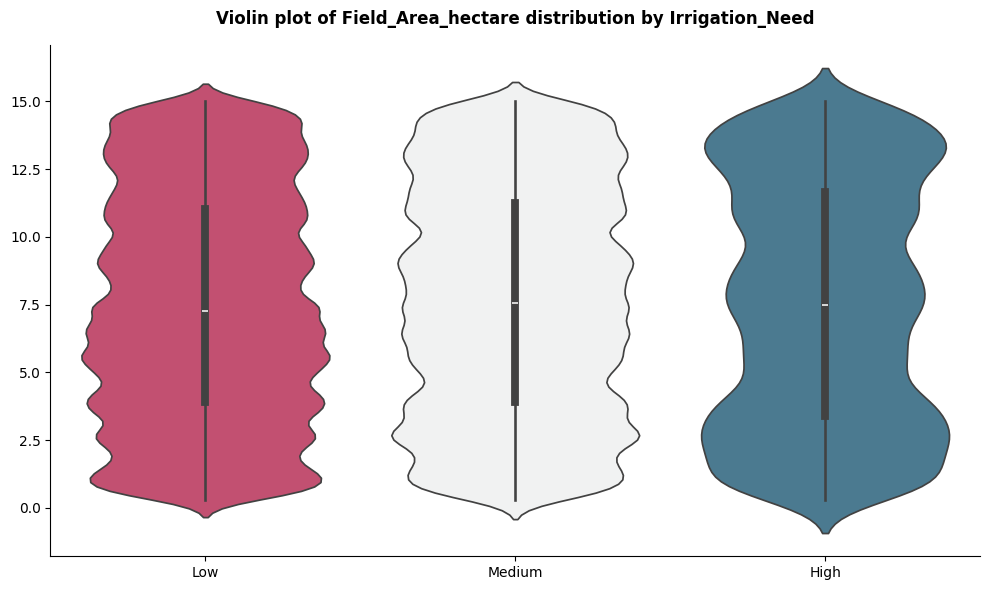

,Irrigation_Need,Count,Mean,Median,Std
0,Medium,239074,63.181715,62.200000,32.295011
1,High,21009,63.053300,66.650000,32.197213
2,Low,369917,61.718330,59.380000,35.548062


2026-04-07 13:01:10 | INFO     | Checking normality of feature 'Previous_Irrigation_mm' by groups of 'Irrigation_Need'...
2026-04-07 13:01:10 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-04-07 13:01:10 | DEBUG    | Number of groups detected: 3
2026-04-07 13:01:10 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-04-07 13:01:10 | DEBUG    | [Irrigation_Need=High] skew=-0.2395, kurtosis=-1.0421 → Approximately symmetric, Normal tails
2026-04-07 13:01:10 | DEBUG    | [Irrigation_Need=Low] skew=0.0038, kurtosis=-1.3242 → Approximately symmetric, Normal tails
2026-04-07 13:01:10 | DEBUG    | [Irrigation_Need=Medium] skew=-0.0225, kurtosis=-1.1662 → Approximately symmetric, Normal tails
2026-04-07 13:01:10 | INFO     | Generating Q–Q plots for visual assessment...


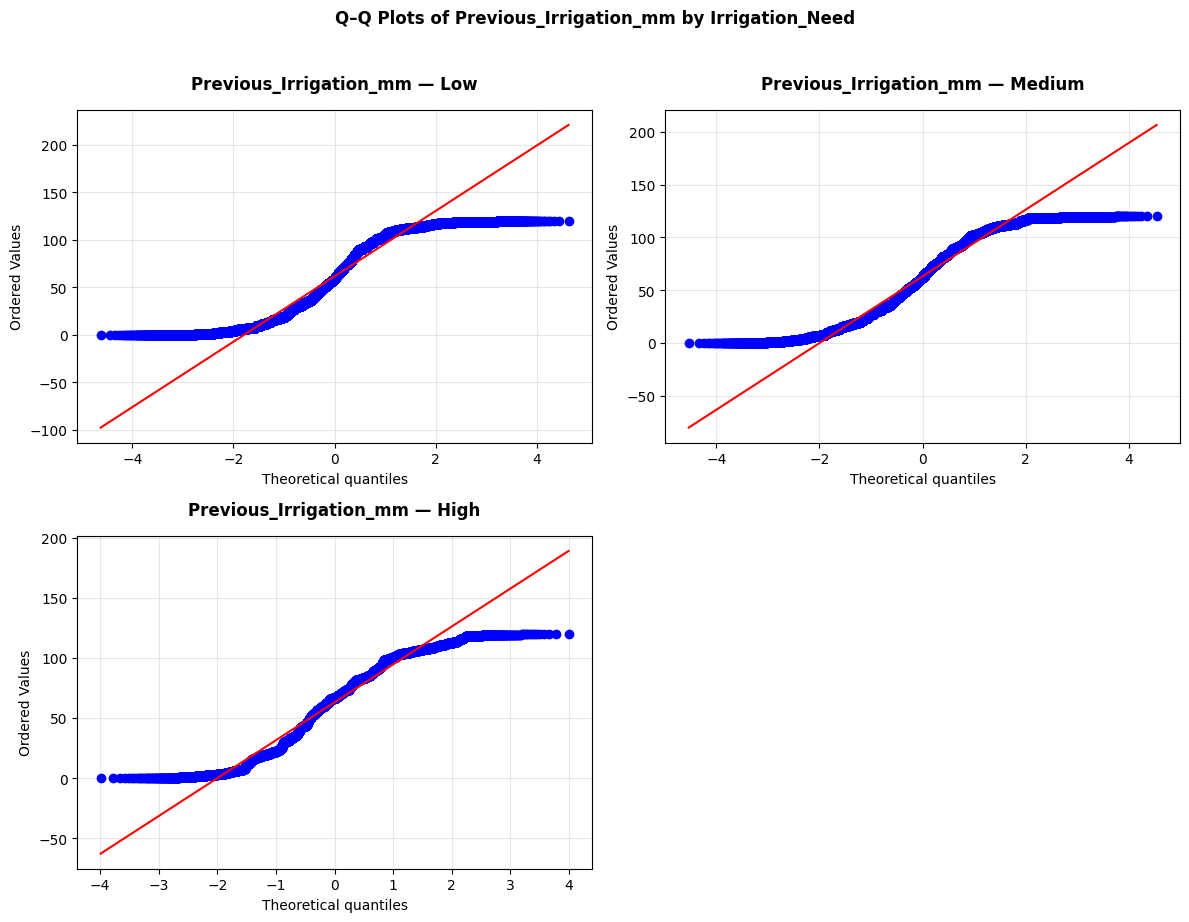

,Feature,Group,Skewness,Kurtosis,Remark
0,Previous_Irrigation_mm,High,-0.2395,-1.0421,"Approximately symmetric, Normal tails"
1,Previous_Irrigation_mm,Low,0.0038,-1.3242,"Approximately symmetric, Normal tails"
2,Previous_Irrigation_mm,Medium,-0.0225,-1.1662,"Approximately symmetric, Normal tails"


2026-04-07 13:01:12 | INFO     | All groups approximately follow a normal distribution.
2026-04-07 13:01:12 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-04-07 13:01:12 | DEBUG    | Number of groups detected: 3


,Metric,Value
0,Levene’s Statistic,3154.1592
1,p-value,0.000000
2,Max/Min Variance Ratio,1.22


2026-04-07 13:01:12 | INFO     | Interpretation:
2026-04-07 13:01:12 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-04-07 13:01:12 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-04-07 13:01:12 | INFO     | Running Welch’s ANOVA Test: Previous_Irrigation_mm ~ Irrigation_Need
2026-04-07 13:01:12 | DEBUG    | Number of groups detected: 3
2026-04-07 13:01:12 | INFO     | Assessing mean differences under heteroscedastic conditions...
2026-04-07 13:01:13 | INFO     | Welch ANOVA F-statistic: 142.3263
2026-04-07 13:01:13 | INFO     | p-value: 0.000000
2026-04-07 13:01:13 | DEBUG    | Welch ANOVA table:
            Source  ddof1         ddof2           F         p-unc       np2
0  Irrigation_Need      2  57876.276647  142.326306  2.187649e-62  0.000437
2026-04-07 13:01:13 | INFO     | Result: p-value < 0.05 → Reject H0
2026-04-07 13:01:13 | INFO     | Conclusion: Signific

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,High,Low,63.0533,61.7183,1.3350,0.2297,5.8119,24010.9339,0.0000,0.0377
1,High,Medium,63.0533,63.1817,-0.1284,0.2317,-0.5541,24869.8135,0.8444,-0.0040
2,Low,Medium,61.7183,63.1817,-1.4634,0.0882,-16.5923,544356.8725,0.0000,-0.0427


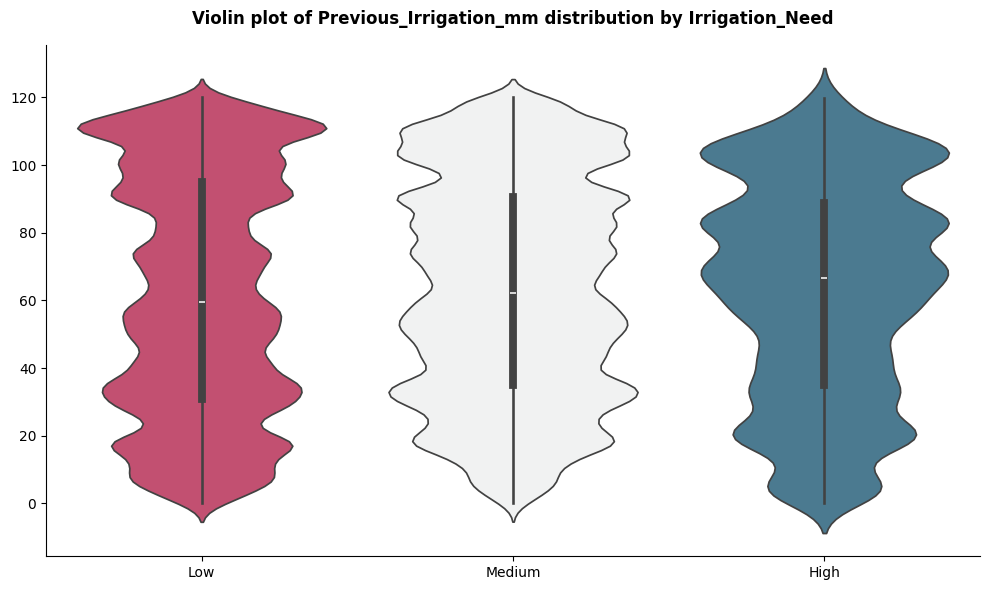

In [19]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train, 
                             target_feature: str = CFG.TARGET_FEATURE) -> None:
    """
    Automatically select and perform appropriate statistical tests
    for comparing a numerical feature across categorical groups.

    This function implements a decision-based statistical testing pipeline
    that selects parametric or non-parametric tests based on:

    - Distribution normality (via skewness, kurtosis, and Q–Q plots)
    - Homogeneity of variances
    - Number of categorical groups

    The procedure follows standard statistical analysis guidelines:

    1. Check normality of the numerical feature within each group.
    2. Determine the number of comparison groups.
    3. Evaluate homogeneity of variance when parametric tests are applicable.
    4. Select and execute the most appropriate hypothesis test.

    Decision Logic
    --------------
    For more than two groups:

    - Non-normal distribution → Kruskal–Wallis test
    - Normal + equal variances → One-way ANOVA + Tukey HSD
    - Normal + unequal variances → Welch’s ANOVA
    - Otherwise → Kruskal–Wallis test

    For two groups:

    - Non-normal distribution → Mann–Whitney U test
    - Normal + equal variances → Independent t-test (with Cohen’s d)
    - Normal + unequal variances → Welch’s t-test (with Cohen’s d)
    - Otherwise → Mann–Whitney U test

    The function also reports effect sizes and post-hoc comparisons
    where applicable.

    Parameters
    ----------
    feature : str
        Name of the numerical feature to be analyzed.

    df : pandas.DataFrame, default=df_train
        Dataset containing the numerical feature and categorical target.

    target_feature : str, default=config.target_feature
        Categorical variable defining comparison groups.

    Returns
    -------
    None
        Executes statistical tests and logs/prints results.
        No value is returned.

    Notes
    -----
    - This function is designed for exploratory and confirmatory
      statistical analysis in machine learning and research workflows.
    - Assumption checks (normality and homoscedasticity) are performed
      automatically prior to testing.
    - For small sample sizes, non-parametric tests are generally preferred.

    Examples
    --------
    >>> perform_statical_testing(
    ...     feature="cholesterol",
    ...     df=df_train,
    ...     target_feature="heart_disease"
    ... )
    """

    # Step 1: Check normality of the feature in each group
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    # Count number of categories in target feature
    total_categories = df[target_feature].nunique()
    # Case 1: More than two groups (Multi-class comparison)
    if total_categories > 2:
        # If data is not normally distributed → use Kruskal–Wallis
        if non_normal_detected:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → One-way ANOVA + Tukey test
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            # Normal + unequal variance → Welch ANOVA
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            # Otherwise → fallback to Kruskal–Wallis
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    # Case 2: Two groups (Binary comparison)
    else:
        # If data is not normal → use Mann–Whitney U test
        if non_normal_detected:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → Independent t-test + Cohen's d
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            # Normal + unequal variance → Welch t-test + Cohen's d
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            # Otherwise → fallback to Mann–Whitney U
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train,
                                target_feature: str = CFG.TARGET_FEATURE, order: list = None) -> None:
    """
    Analyze and visualize the distribution of a numerical feature
    across categories of a target variable.

    This function performs:
    - Descriptive statistics (mean, median, std) by group
    - Overall summary statistics
    - Automated statistical hypothesis testing
    - Violin plot visualization

    Parameters
    ----------
    feature : str
        Numerical feature to be analyzed.

    df : pandas.DataFrame
        Input dataset containing the feature and target variable.

    target_feature : str
        Categorical variable used for grouping.

    order : list, optional
        Custom order of categories for plotting.

    Returns
    -------
    None
        Displays summary tables, test results, and plots.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))

    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Irrigation Need</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight: Numerical Drivers of Irrigation Demand
</div>

<div style="line-height:1.8;">

<p><b><code>Soil_pH</code></b><br>
While soil pH varies across irrigation levels, the effect size is negligible, 
indicating no meaningful practical impact.</p>

<p><b><code>Soil_Moisture</code></b><br>
Soil moisture demonstrates a strong and well-defined relationship with irrigation demand, 
with clear separation across levels, making it a key predictive driver.</p>

<p><b><code>Organic_Carbon</code></b><br>
Differences in organic carbon are statistically detectable but practically insignificant, 
suggesting minimal contribution to irrigation decisions.</p>

<p><b><code>Electrical_Conductivity</code></b><br>
Electrical conductivity shows slight variation across groups; however, 
the magnitude of impact remains limited.</p>

<p><b><code>Temperature_C</code></b><br>
Temperature exhibits a strong and consistent association with irrigation needs, 
highlighting its role as a critical environmental driver.</p>

<p><b><code>Humidity</code></b><br>
Humidity shows measurable differences, though weak group separation indicates 
it functions primarily as a secondary supporting factor.</p>

<p><b><code>Rainfall_mm</code></b><br>
Rainfall emerges as the most influential driver, with a clear and direct inverse relationship 
to irrigation demand.</p>

<p><b><code>Sunlight_Hours</code></b><br>
Despite statistical significance, sunlight hours show negligible effect size, 
offering no meaningful real-world contribution.</p>

<p><b><code>Wind_Speed_kmh</code></b><br>
Wind speed demonstrates a moderate association with irrigation demand, 
though its standalone predictive power remains limited.</p>

<p><b><code>Field_Area_hectare</code></b><br>
Field size shows no meaningful variation across irrigation levels, 
indicating no influence on demand.</p>

<p><b><code>Previous_Irrigation_mm</code></b><br>
Historical irrigation levels exhibit minimal impact on current demand, 
with no strong predictive signal observed.</p>

</div>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Irrigation demand is primarily driven by dynamic environmental factors—especially rainfall, temperature, and soil moisture—while most other numerical variables provide limited incremental value.
</div>

</div>

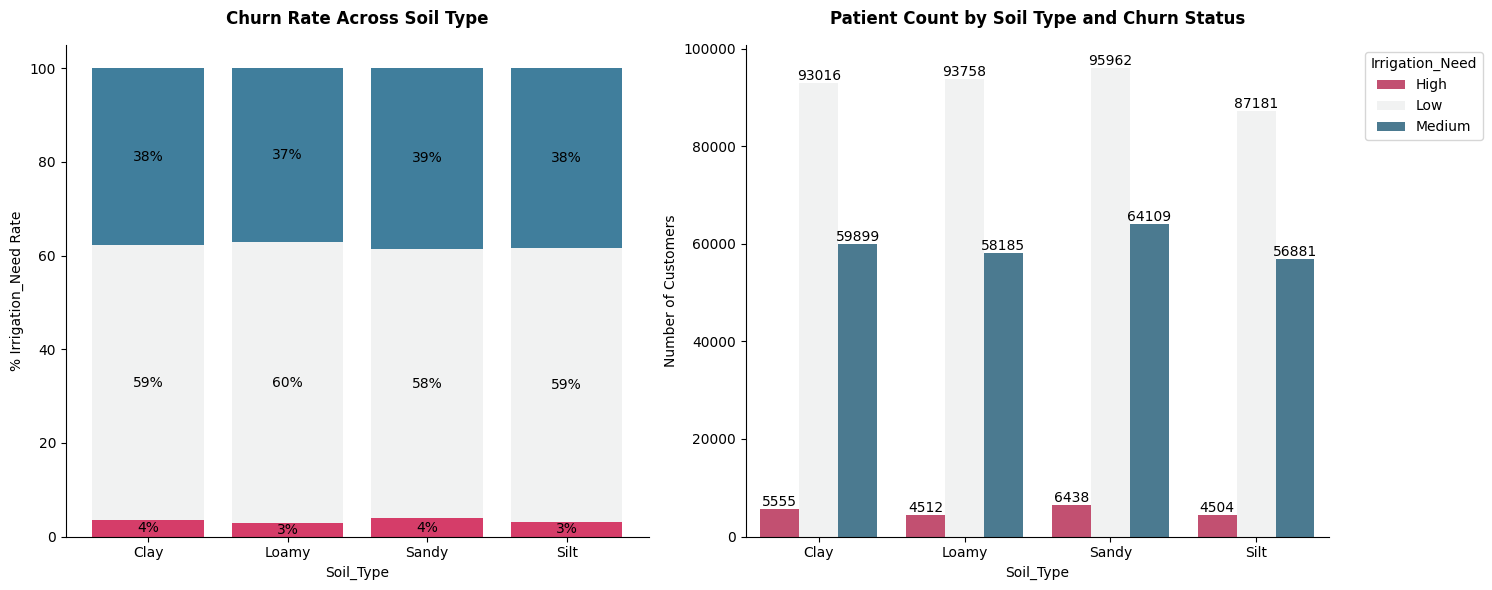

2026-04-07 13:01:18 | INFO     | Chi-Square Test of Independence: 'Soil_Type' vs. 'Irrigation_Need'...
2026-04-07 13:01:18 | INFO     | Chi-squared statistic: 406.316
2026-04-07 13:01:18 | INFO     | Degrees of freedom: 6
2026-04-07 13:01:18 | INFO     | p-value: 0.000000
2026-04-07 13:01:18 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:18 | INFO     | Variables 'Soil_Type' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:18 | DEBUG    | Displaying standardized residuals heatmap.


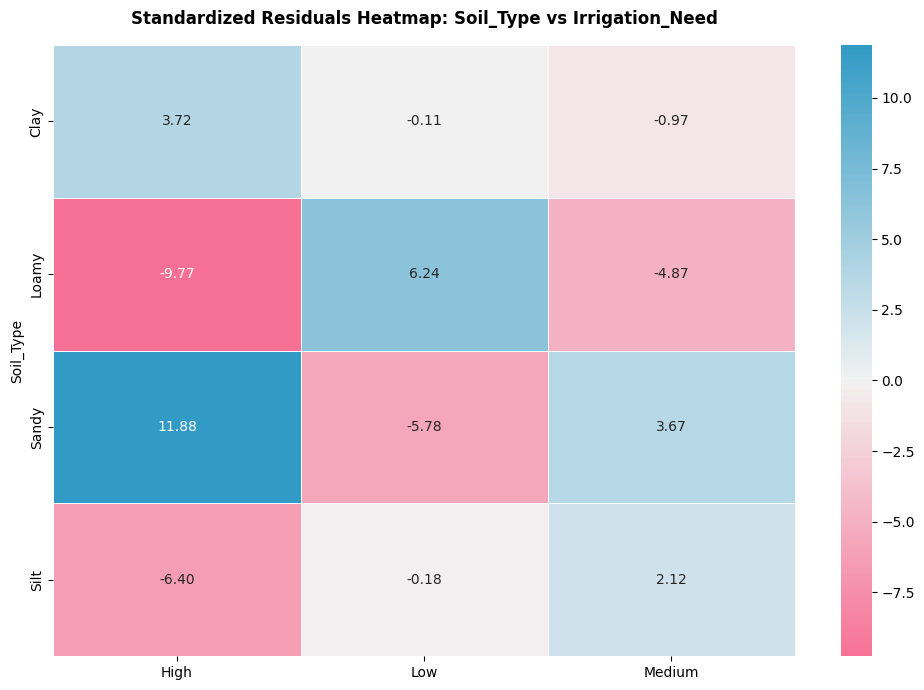

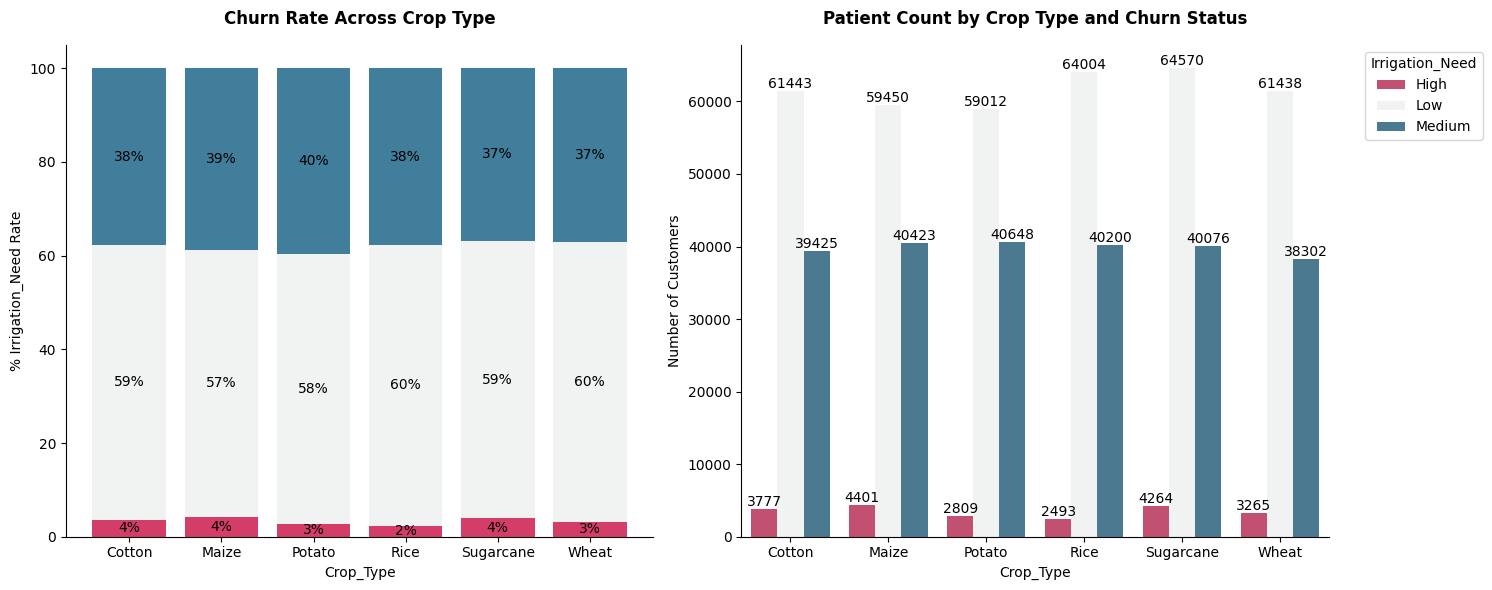

2026-04-07 13:01:20 | INFO     | Chi-Square Test of Independence: 'Crop_Type' vs. 'Irrigation_Need'...
2026-04-07 13:01:20 | INFO     | Chi-squared statistic: 1094.944
2026-04-07 13:01:20 | INFO     | Degrees of freedom: 10
2026-04-07 13:01:20 | INFO     | p-value: 0.000000
2026-04-07 13:01:20 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:20 | INFO     | Variables 'Crop_Type' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:20 | DEBUG    | Displaying standardized residuals heatmap.


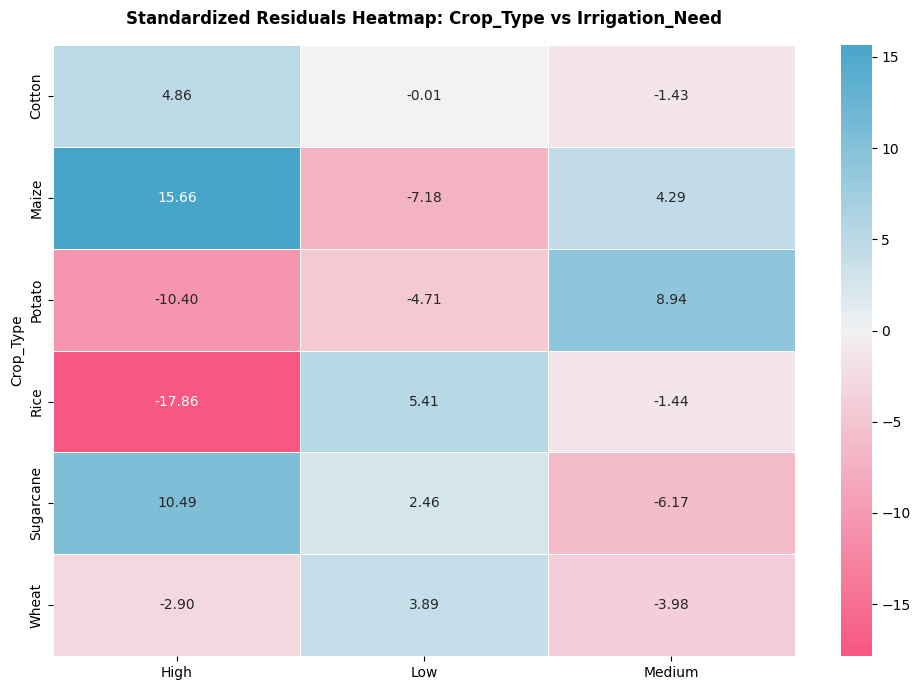

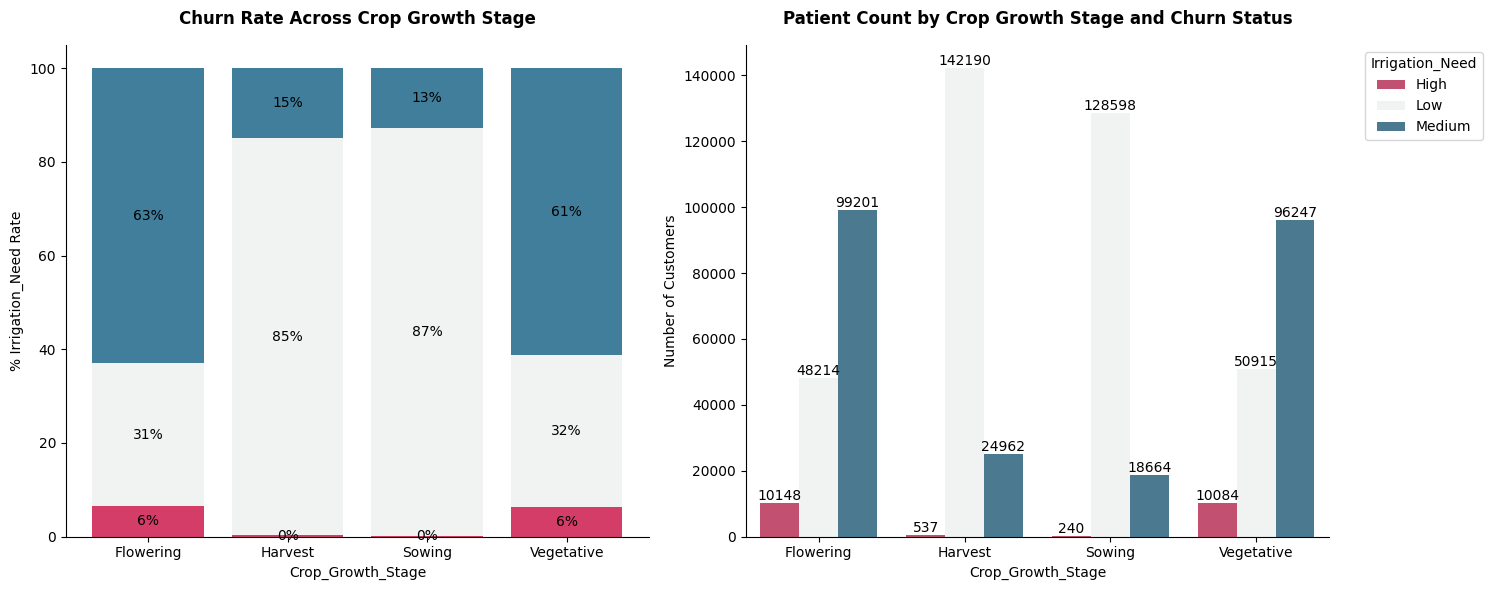

2026-04-07 13:01:22 | INFO     | Chi-Square Test of Independence: 'Crop_Growth_Stage' vs. 'Irrigation_Need'...
2026-04-07 13:01:22 | INFO     | Chi-squared statistic: 194378.520
2026-04-07 13:01:22 | INFO     | Degrees of freedom: 6
2026-04-07 13:01:22 | INFO     | p-value: 0.000000
2026-04-07 13:01:22 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:22 | INFO     | Variables 'Crop_Growth_Stage' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:22 | DEBUG    | Displaying standardized residuals heatmap.


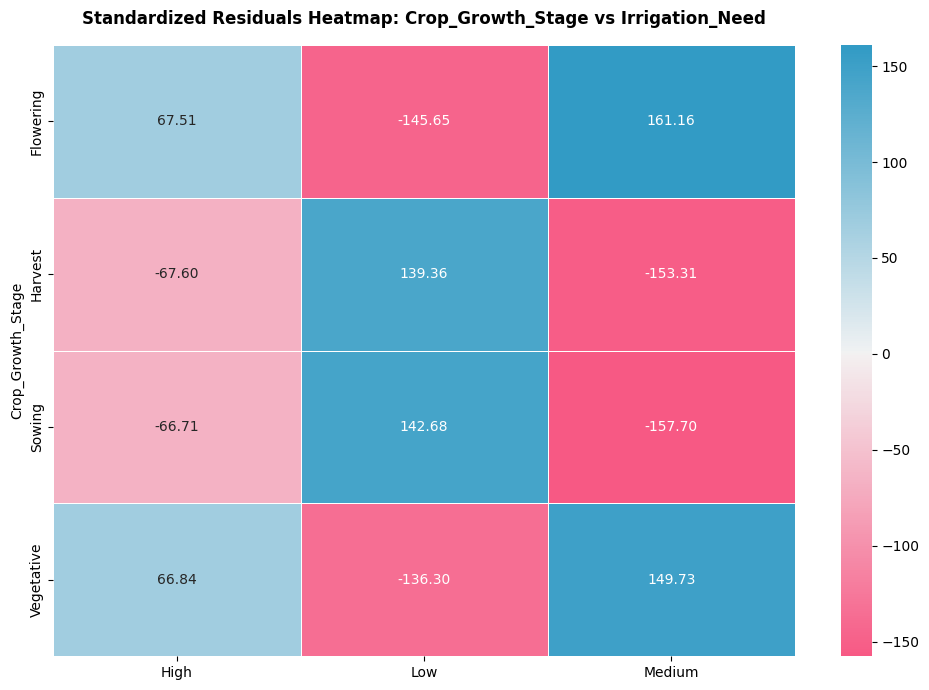

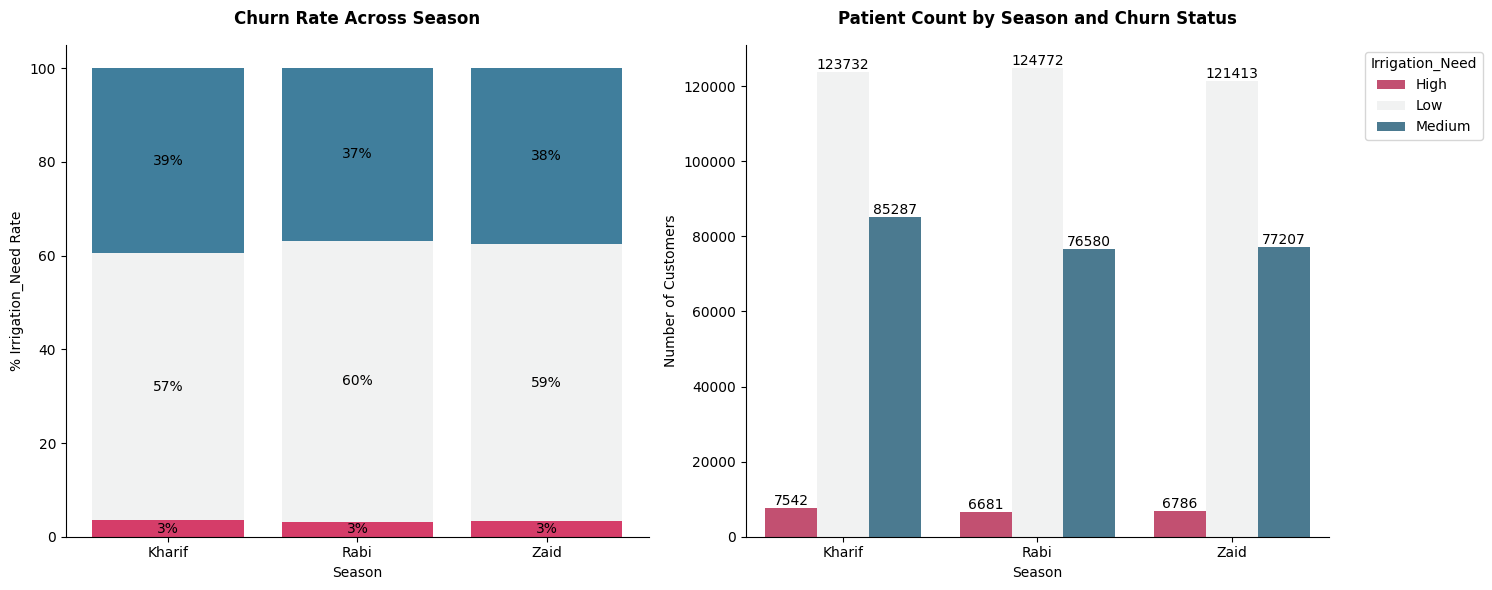

2026-04-07 13:01:23 | INFO     | Chi-Square Test of Independence: 'Season' vs. 'Irrigation_Need'...
2026-04-07 13:01:24 | INFO     | Chi-squared statistic: 373.470
2026-04-07 13:01:24 | INFO     | Degrees of freedom: 4
2026-04-07 13:01:24 | INFO     | p-value: 0.000000
2026-04-07 13:01:24 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:24 | INFO     | Variables 'Season' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:24 | DEBUG    | Displaying standardized residuals heatmap.


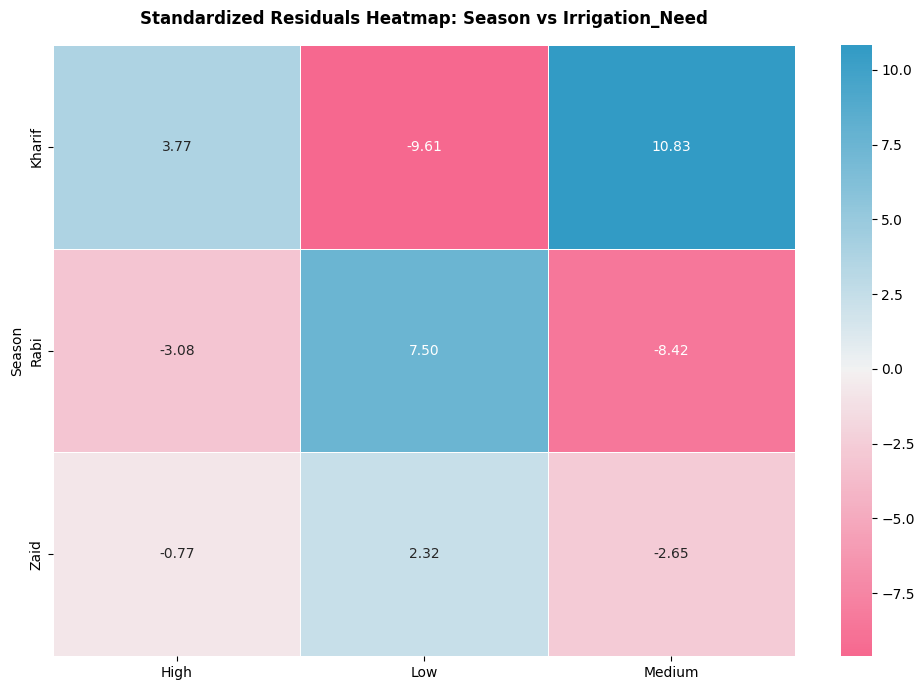

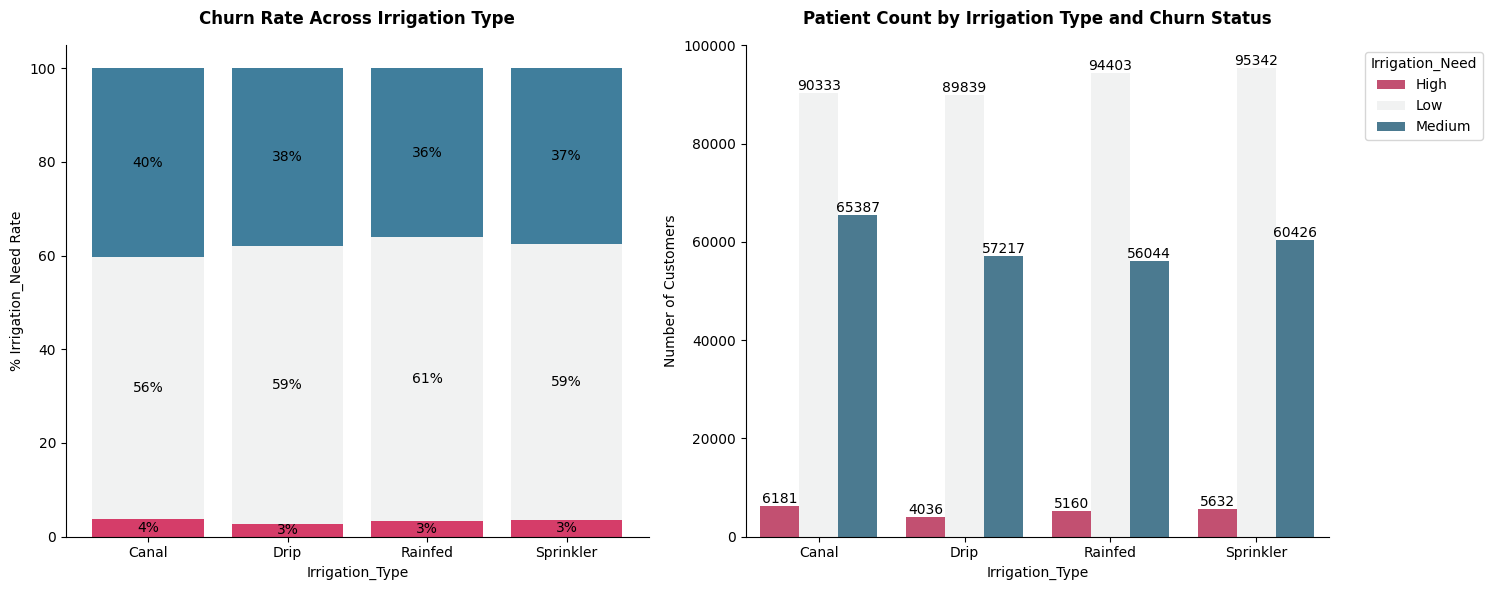

2026-04-07 13:01:25 | INFO     | Chi-Square Test of Independence: 'Irrigation_Type' vs. 'Irrigation_Need'...
2026-04-07 13:01:26 | INFO     | Chi-squared statistic: 1096.453
2026-04-07 13:01:26 | INFO     | Degrees of freedom: 6
2026-04-07 13:01:26 | INFO     | p-value: 0.000000
2026-04-07 13:01:26 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:26 | INFO     | Variables 'Irrigation_Type' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:26 | DEBUG    | Displaying standardized residuals heatmap.


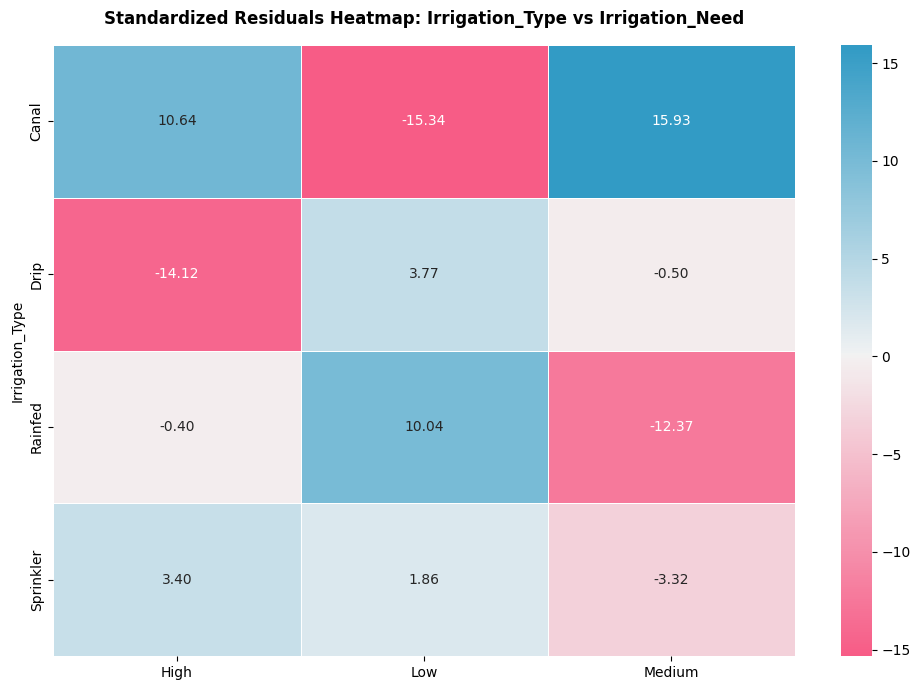

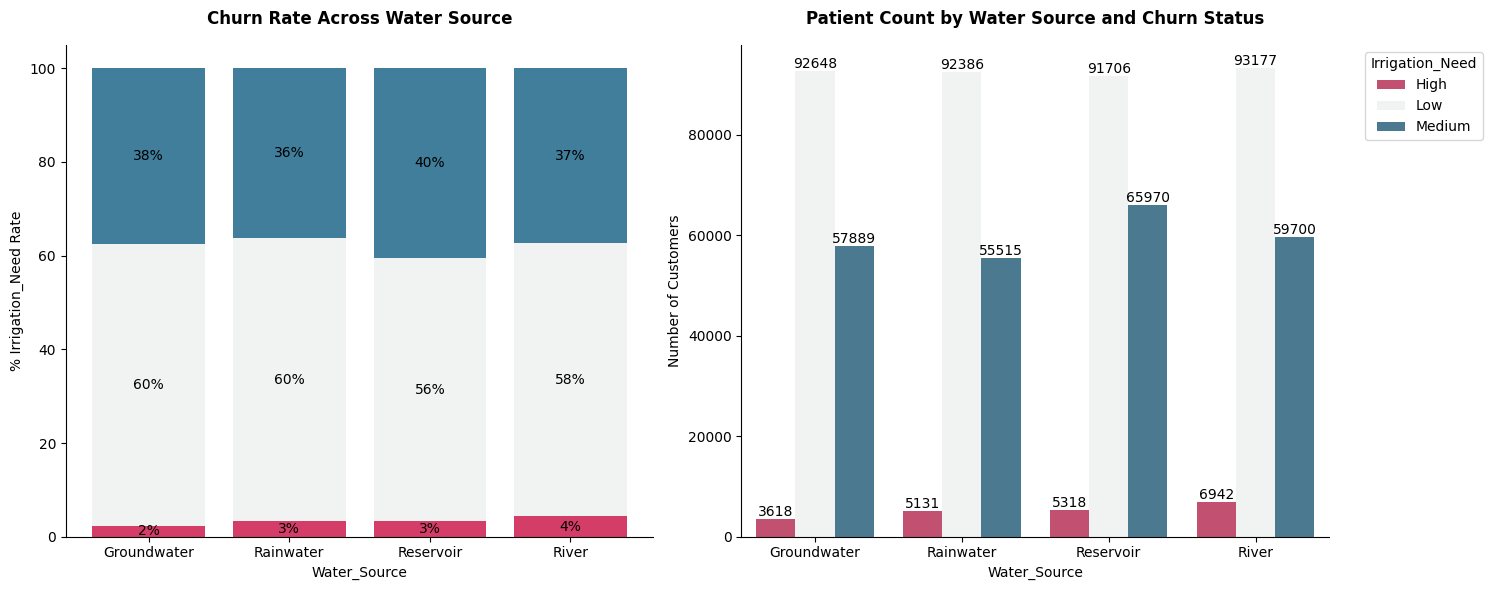

2026-04-07 13:01:27 | INFO     | Chi-Square Test of Independence: 'Water_Source' vs. 'Irrigation_Need'...
2026-04-07 13:01:28 | INFO     | Chi-squared statistic: 1642.705
2026-04-07 13:01:28 | INFO     | Degrees of freedom: 6
2026-04-07 13:01:28 | INFO     | p-value: 0.000000
2026-04-07 13:01:28 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:28 | INFO     | Variables 'Water_Source' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:28 | DEBUG    | Displaying standardized residuals heatmap.


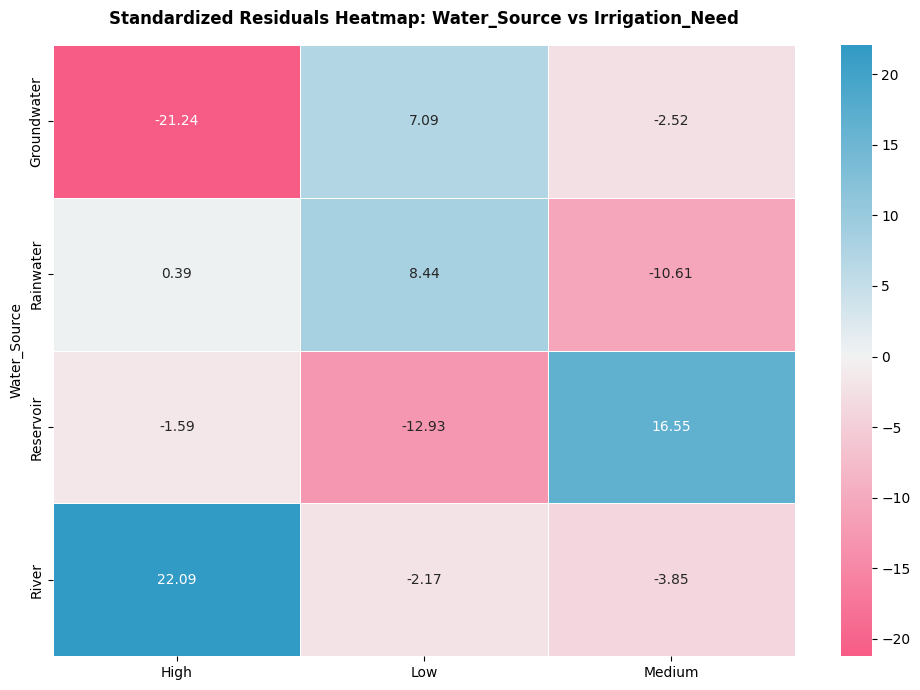

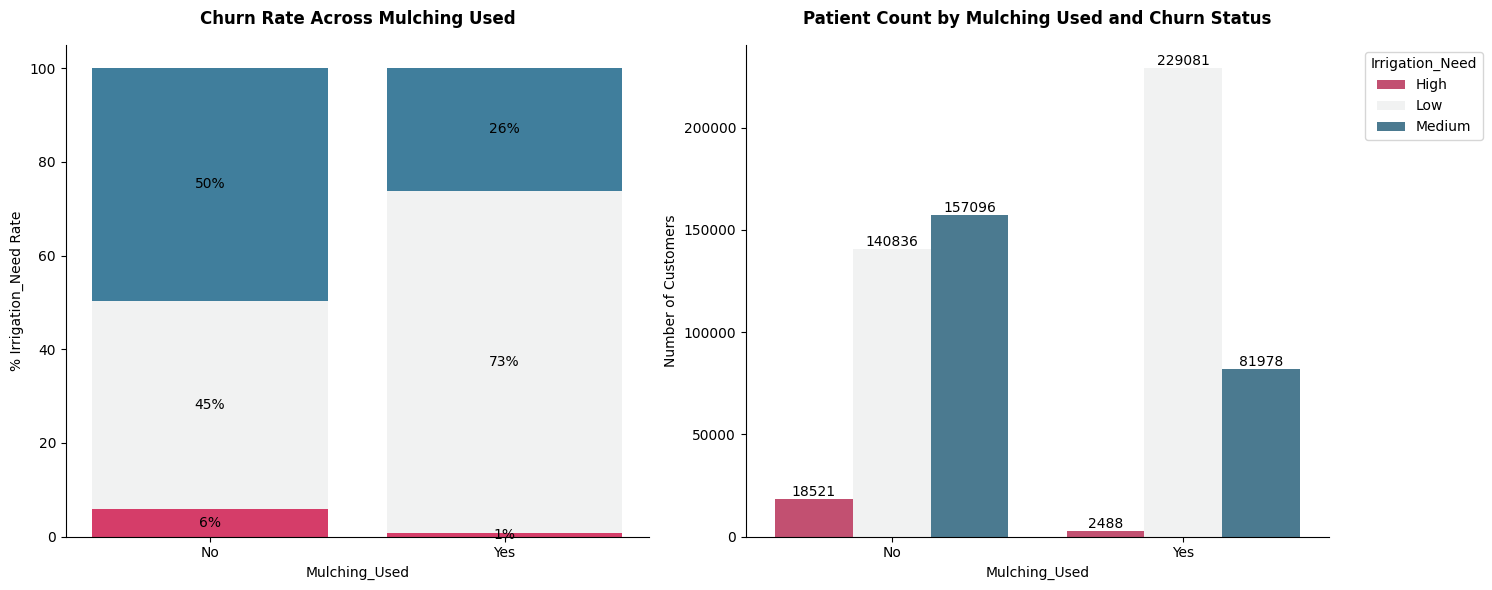

2026-04-07 13:01:29 | INFO     | Chi-Square Test of Independence: 'Mulching_Used' vs. 'Irrigation_Need'...
2026-04-07 13:01:29 | INFO     | Chi-squared statistic: 56876.904
2026-04-07 13:01:29 | INFO     | Degrees of freedom: 2
2026-04-07 13:01:29 | INFO     | p-value: 0.000000
2026-04-07 13:01:29 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:29 | INFO     | Variables 'Mulching_Used' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:29 | DEBUG    | Displaying standardized residuals heatmap.


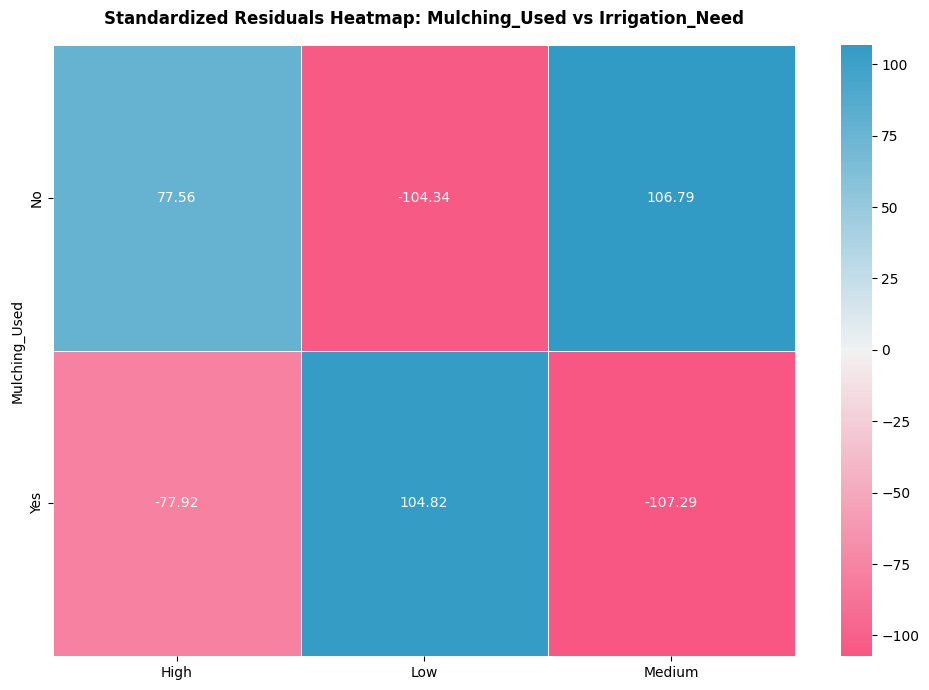

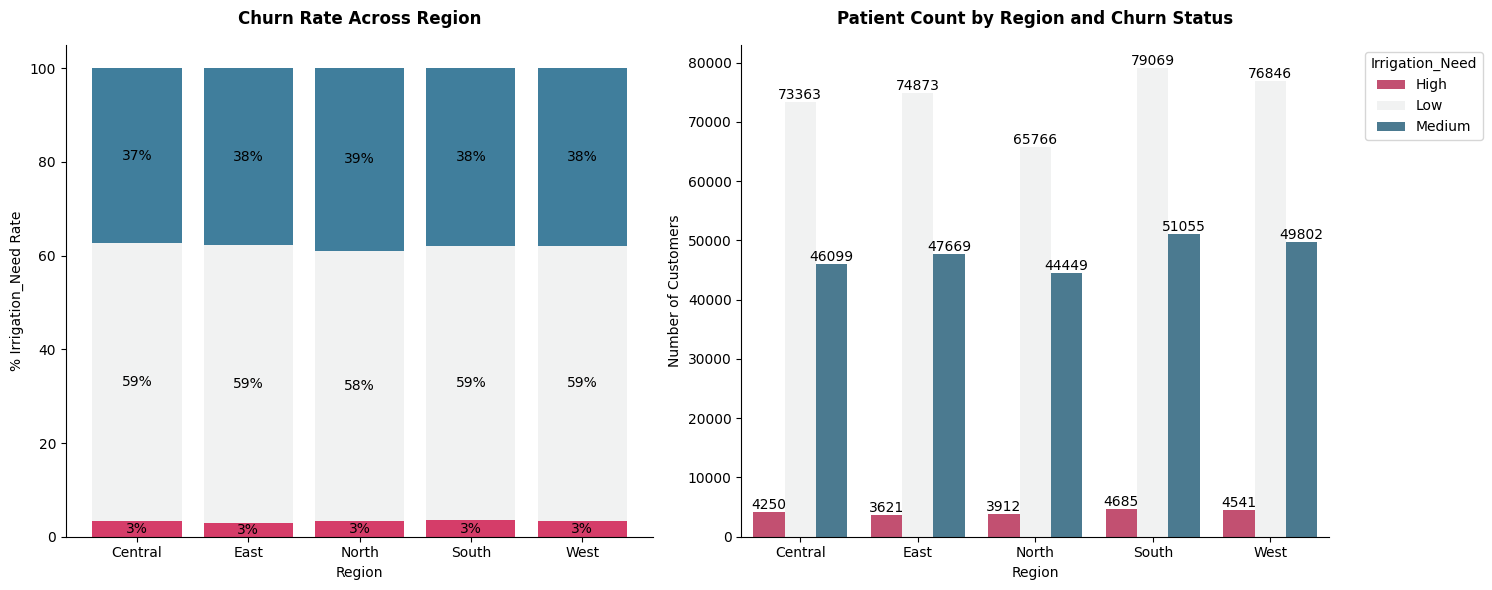

2026-04-07 13:01:31 | INFO     | Chi-Square Test of Independence: 'Region' vs. 'Irrigation_Need'...
2026-04-07 13:01:31 | INFO     | Chi-squared statistic: 188.514
2026-04-07 13:01:31 | INFO     | Degrees of freedom: 8
2026-04-07 13:01:31 | INFO     | p-value: 0.000000
2026-04-07 13:01:31 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-04-07 13:01:31 | INFO     | Variables 'Region' and 'Irrigation_Need' are statistically associated.
2026-04-07 13:01:31 | DEBUG    | Displaying standardized residuals heatmap.


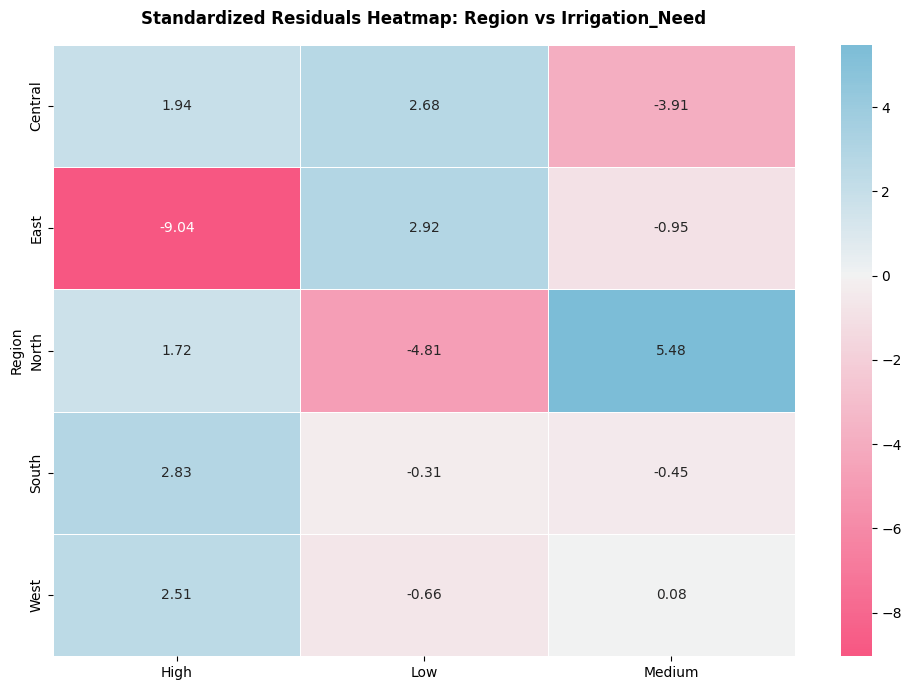

In [20]:
def bivariate_percent_plot(cat: str, target_feature: str,
                           df: pd.DataFrame, figsize=(15, 6), order=None) -> None:
    """
    Plot the relationship between a categorical feature and the target variable.

    This function displays:
    - A stacked bar chart showing percentage distribution of target classes.
    - A count plot showing absolute frequencies.
    - A Chi-Square test for feature–target dependence.

    Parameters
    ----------
    cat : str
        Categorical feature name.

    target_feature : str
        Target variable name.

    df : pd.DataFrame
        Input dataset.

    figsize : tuple, optional
        Figure size (width, height). Default is (15, 6).

    order : list, optional
        Custom order of categories on x-axis.

    Returns
    -------
    None
    """

    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat.title()} by {target_feature.title()}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = [c for c in ["Yes", "No"] if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order))
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index.astype(str), percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"Churn Rate Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(f"{cat}", fontsize=10)
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=10)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="black")

    ax[1].set_title(f"Patient Count by {cat.replace('_', ' ').title()} and Churn Status", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(f"{cat}", fontsize=10)
    ax[1].set_ylabel("Number of Customers", fontsize=10)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
for feature in cat_features:
    bivariate_percent_plot(cat=feature, target_feature=CFG.TARGET_FEATURE, df=df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight: Categorical Drivers of Irrigation Demand
</div>

<div style="line-height:1.8;">

<p><b><code>Soil_Type</code></b><br>
Soil type exhibits a strong structural influence on irrigation demand, 
with sandy soils requiring significantly higher water input due to low retention capacity.</p>

<p><b><code>Crop_Type</code></b><br>
Crop type is a key determinant of irrigation needs, 
as water-intensive crops consistently demand higher irrigation levels.</p>

<p><b><code>Crop_Growth_Stage</code></b><br>
Irrigation demand varies substantially across growth stages, 
peaking during active development phases and declining during early and late stages.</p>

<p><b><code>Season</code></b><br>
Seasonality introduces measurable variation in irrigation demand; however, 
its influence remains secondary to crop and environmental drivers.</p>

<p><b><code>Irrigation_Type</code></b><br>
Irrigation type reflects operational response rather than causation, 
indicating how farmers adapt methods based on underlying demand conditions.</p>

<p><b><code>Water_Source</code></b><br>
Water source represents resource availability constraints, 
shaping how irrigation demand is fulfilled rather than driving it.</p>

<p><b><code>Mulching_Used</code></b><br>
Mulching emerges as a high-impact intervention, significantly reducing irrigation demand 
through improved soil moisture retention.</p>

<p><b><code>Region</code></b><br>
Irrigation demand remains largely consistent across regions, 
suggesting minimal geographic differentiation in underlying patterns.</p>

</div>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Irrigation demand is primarily shaped by crop characteristics and environmental conditions, while operational choices and resource constraints determine how that demand is executed.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Consolidated Feature Impact Summary – Irrigation Demand
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    font-size: 14px;
">

<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Feature</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Summary</th>
</tr>
</thead>

<tbody>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Rainfall_mm</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Primary driver</b> — rainfall shows a strong inverse relationship with irrigation demand, making it the most influential factor.</td>
</tr>

<tr>
<td><b>Temperature_C</b></td>
<td><b>Core environmental driver</b> — strongly associated with irrigation needs, with clear and consistent separation across levels.</td>
</tr>

<tr>
<td><b>Soil_Moisture</b></td>
<td><b>Key predictive signal</b> — closely aligned with irrigation demand and highly actionable for monitoring.</td>
</tr>

<tr>
<td><b>Crop_Growth_Stage</b></td>
<td><b>Strategic lifecycle driver</b> — irrigation demand peaks during active growth phases and declines at early and late stages.</td>
</tr>

<tr>
<td><b>Crop_Type</b></td>
<td><b>Structural driver</b> — water-intensive crops consistently require higher irrigation levels.</td>
</tr>

<tr>
<td><b>Soil_Type</b></td>
<td><b>Structural driver</b> — soil characteristics significantly influence water retention, with sandy soils requiring more irrigation.</td>
</tr>

<tr>
<td><b>Mulching_Used</b></td>
<td><b>High-impact intervention</b> — significantly reduces irrigation demand by improving soil moisture retention.</td>
</tr>

<tr>
<td><b>Humidity</b></td>
<td><b>Supporting factor</b> — shows statistical differences but limited separation reduces standalone predictive value.</td>
</tr>

<tr>
<td><b>Wind_Speed_kmh</b></td>
<td><b>Secondary influence</b> — exhibits moderate association but limited standalone impact.</td>
</tr>

<tr>
<td><b>Season</b></td>
<td><b>Contextual modifier</b> — introduces variation but remains secondary to environmental and crop drivers.</td>
</tr>

<tr>
<td><b>Electrical_Conductivity</b></td>
<td><b>Weak signal</b> — statistically different but with marginal practical impact.</td>
</tr>

<tr>
<td><b>Soil_pH</b></td>
<td><b>Weak signal</b> — negligible effect size despite statistical significance.</td>
</tr>

<tr>
<td><b>Organic_Carbon</b></td>
<td><b>No practical value</b> — differences are statistically detectable but practically insignificant.</td>
</tr>

<tr>
<td><b>Sunlight_Hours</b></td>
<td><b>No meaningful impact</b> — negligible real-world contribution despite statistical differences.</td>
</tr>

<tr>
<td><b>Field_Area_hectare</b></td>
<td><b>Irrelevant</b> — shows no meaningful variation across irrigation levels.</td>
</tr>

<tr>
<td><b>Previous_Irrigation_mm</b></td>
<td><b>Minimal predictive value</b> — historical irrigation has little influence on current demand.</td>
</tr>

<tr>
<td><b>Irrigation_Type</b></td>
<td><b>Execution variable</b> — reflects how farmers respond to demand rather than driving it.</td>
</tr>

<tr>
<td><b>Water_Source</b></td>
<td><b>Resource constraint</b> — represents availability rather than influencing demand.</td>
</tr>

<tr>
<td><b>Region</b></td>
<td><b>Geographically neutral</b> — irrigation demand remains consistent across regions.</td>
</tr>

</tbody>
</table>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Irrigation demand is primarily driven by environmental conditions and crop characteristics, while practices like mulching can significantly reduce demand, and operational factors mainly determine how that demand is fulfilled.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Feature Engineering¶</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Feature Engineering
    </h1>
</div>

In [21]:
def compute_logit_scores(df):
    """Compute logit scores from original data coefficients."""
    soil = (df["Soil_Moisture"] < CFG.SOIL_THRESH).astype(float)
    temp = (df["Temperature_C"] > CFG.TEMP_THRESH).astype(float)
    rain = (df["Rainfall_mm"] < CFG.RAIN_THRESH).astype(float)
    wind = (df["Wind_Speed_kmh"] > CFG.WIND_THRESH).astype(float)

    stage = df["Crop_Growth_Stage"].astype(str)
    is_flowering  = (stage == "Flowering").astype(float)
    is_harvest    = (stage == "Harvest").astype(float)
    is_sowing     = (stage == "Sowing").astype(float)
    is_vegetative = (stage == "Vegetative").astype(float)

    mulch = df["Mulching_Used"].astype(str)
    mulch_no  = (mulch == "No").astype(float)
    mulch_yes = (mulch == "Yes").astype(float)

    for cls_name, coefs in CFG.LOGIT_COEFS.items():
        df[f"logit_{cls_name}"] = (
            coefs["intercept"]
            + coefs["soil_lt_25"] * soil + coefs["temp_gt_30"] * temp
            + coefs["rain_lt_300"] * rain + coefs["wind_gt_10"] * wind
            + coefs["Flowering"] * is_flowering + coefs["Harvest"] * is_harvest
            + coefs["Sowing"] * is_sowing + coefs["Vegetative"] * is_vegetative
            + coefs["Mulch_No"] * mulch_no + coefs["Mulch_Yes"] * mulch_yes
        )
    return df

logger.info("Logit function defined")

2026-04-07 13:01:33 | INFO     | Logit function defined


In [22]:
def engineer_features(df):
    """Full-stack feature engineering."""
    df = df.copy()

    # Binary thresholds
    df["soil_lt_25"]    = (df["Soil_Moisture"] < CFG.SOIL_THRESH).astype(int)
    df["rain_lt_300"]   = (df["Rainfall_mm"] < CFG.RAIN_THRESH).astype(int)
    df["temp_gt_30"]    = (df["Temperature_C"] > CFG.TEMP_THRESH).astype(int)
    df["wind_gt_10"]    = (df["Wind_Speed_kmh"] > CFG.WIND_THRESH).astype(int)

    df["is_harvest"]    = (df["Crop_Growth_Stage"] == "Harvest").astype(int)
    df["is_sowing"]     = (df["Crop_Growth_Stage"] == "Sowing").astype(int)
    df["mulching_yes"]  = (df["Mulching_Used"] == "Yes").astype(int)

    # Magic score
    high_score = 2 * df["soil_lt_25"] + 2 * df["rain_lt_300"] + df["temp_gt_30"] + df["wind_gt_10"]
    low_score  = 2 * df["is_harvest"] + 2 * df["is_sowing"] + df["mulching_yes"]
    df["magic_score"] = high_score - low_score

    # Decimal extraction
    for col in ["Soil_Moisture", "Temperature_C", "Rainfall_mm", "Wind_Speed_kmh",
                "Humidity", "Soil_pH", "Organic_Carbon", "Electrical_Conductivity",
                "Sunlight_Hours", "Field_Area_hectare", "Previous_Irrigation_mm"]:
        vals = df[col].values
        df[f"{col}_dec"] = np.floor((vals - np.floor(vals)) * 10).astype(int)

    # Boundary distances
    df["dist_boundary_0"]       = np.abs(df["magic_score"] - 0)
    df["dist_boundary_3"]       = np.abs(df["magic_score"] - 3)
    df["dist_boundary_min"]     = np.minimum(df["dist_boundary_0"], df["dist_boundary_3"])

    df["soil_dist_25"]          = df["Soil_Moisture"] - CFG.SOIL_THRESH
    df["rain_dist_300"]         = df["Rainfall_mm"] - CFG.RAIN_THRESH
    df["temp_dist_30"]          = df["Temperature_C"] - CFG.TEMP_THRESH
    df["wind_dist_10"]          = df["Wind_Speed_kmh"] - CFG.WIND_THRESH

    # Logit scores
    df = compute_logit_scores(df)

    # Domain features
    df["Total_Water_Input"]     = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    df["Moisture_Deficit"]      = 100 - df["Soil_Moisture"]
    df["Irrigation_Ratio"]      = df["Previous_Irrigation_mm"] / (df["Rainfall_mm"] + 1)
    df["ET_Proxy"]              = (df["Temperature_C"] * df["Sunlight_Hours"]) / (df["Humidity"] + 1)
    df["Evap_Stress"]           = (df["Temperature_C"] * df["Wind_Speed_kmh"]) / (df["Humidity"] + 1)
    df["Wind_ET"]               = df["Wind_Speed_kmh"] * (1 - df["Humidity"] / 100)
    df["Net_Water_Need"]        = df["ET_Proxy"] - df["Rainfall_mm"] / 10
    df["VPD_Proxy"]             = df["Temperature_C"] * (1 - df["Humidity"] / 100)
    df["Heat_Stress"]           = df["Temperature_C"] * (100 - df["Humidity"]) / 100
    df["Dryness_Index"]         = df["Temperature_C"] * df["Sunlight_Hours"] / (df["Rainfall_mm"] + 1)
    df["Aridity_Index"]         = df["Rainfall_mm"] / (df["ET_Proxy"] + 0.1)
    df["Drought_Risk"]          = df["Dryness_Index"] * df["Moisture_Deficit"] / 100
    df["Soil_Health"]           = df["Organic_Carbon"] * df["Soil_Moisture"] / (df["Electrical_Conductivity"] + 0.1)
    df["Salinity_Risk"]         = df["Electrical_Conductivity"] * df["Temperature_C"] / (df["Rainfall_mm"] + 1)
    df["pH_Deviation"]          = np.abs(df["Soil_pH"] - 6.5)
    df["Moisture_Retention"]    = df["Soil_Moisture"] * df["Organic_Carbon"]
    df["EC_pH_Interaction"]     = df["Electrical_Conductivity"] * df["Soil_pH"]
    df["Irrig_Per_Ha"]          = df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + 0.1)
    df["Rain_Per_Ha"]           = df["Rainfall_mm"] / (df["Field_Area_hectare"] + 0.1)
    df["Area_Log"]              = np.log1p(df["Field_Area_hectare"])
    df["Water_Per_Ha"]          = df["Total_Water_Input"] / (df["Field_Area_hectare"] + 0.1)

    mulch_map = {"Yes": 1.0, "No": 0.0}
    df["Mulch_Flag"]            = df["Mulching_Used"].map(mulch_map).fillna(0.0)
    df["Mulch_Moisture"]        = df["Soil_Moisture"] * (1 + 0.5 * df["Mulch_Flag"])
    df["Mulch_ET_Saving"]       = df["ET_Proxy"] * (1 - 0.3 * df["Mulch_Flag"])

    df["Moisture_ET_Ratio"]     = df["Soil_Moisture"] / (df["ET_Proxy"] + 0.1)
    df["Rain_ET_Balance"]       = df["Rainfall_mm"] - df["ET_Proxy"] * 2
    df["Sunlight_Temp_Ratio"]   = df["Sunlight_Hours"] / (df["Temperature_C"] + 1)
    df["Water_Stress_Index"]    = (df["ET_Proxy"] - df["Total_Water_Input"] / 10) / (df["Soil_Moisture"] + 1)

    for col in ["Rainfall_mm", "Previous_Irrigation_mm", "Field_Area_hectare", "Wind_Speed_kmh"]:
        df[f"log_{col}"] = np.log1p(df[col])

    return df

logger.info("Feature engineering function defined")

2026-04-07 13:01:33 | INFO     | Feature engineering function defined


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Baseline Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Baseline Preprocessing
    </h1>
</div>

In [23]:
# Combining competition train with original dataset
df_train_combined = pd.concat([df_train, df_original], ignore_index=True)

# Apply feature engineering
logger.info("Engineering features...")
train_eng = engineer_features(df_train_combined)
test_eng  = engineer_features(df_test)

# Label encode categoricals
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([train_eng[col].astype(str), test_eng[col].astype(str)])
    le.fit(combined)
    train_eng[col] = le.transform(train_eng[col].astype(str)).astype("int32")
    test_eng[col]  = le.transform(test_eng[col].astype(str)).astype("int32")

logger.info(f"Train: {train_eng.shape}")

2026-04-07 13:01:33 | INFO     | Engineering features...
2026-04-07 13:01:36 | INFO     | Train: (640000, 81)


In [24]:
# Build pairwise interactions
ALL_COLS = num_features + cat_features
TE_COLUMNS = []
n_train = len(train_eng)

logger.info("Building interaction features...")
for cols in tqdm(list(combinations(ALL_COLS, 2))):
    name     = f'{cols[0]}|{cols[1]}'
    tr_s     = train_eng[cols[0]].astype(str) + '_' + train_eng[cols[1]].astype(str)
    te_s     = test_eng[cols[0]].astype(str)  + '_' + test_eng[cols[1]].astype(str)
    combined = pd.concat([tr_s, te_s], ignore_index=True)
    codes, _ = combined.factorize()
    if pd.Series(codes).nunique() > len(codes) // 2:
        continue
    train_eng[name] = codes[:n_train]
    test_eng[name]  = codes[n_train:]
    TE_COLUMNS.append(name)

logger.info(f"Created {len(TE_COLUMNS)} interaction features")

2026-04-07 13:01:36 | INFO     | Building interaction features...


100%|██████████| 171/171 [02:35<00:00,  1.10it/s]

2026-04-07 13:04:11 | INFO     | Created 135 interaction features


In [25]:
# Prepare matrices
y_full = train_eng[CFG.TARGET_FEATURE].map(CFG.TARGET_MAPPING).values
BASE_FEATURES = [c for c in train_eng.columns 
                 if c not in ["id", CFG.TARGET_FEATURE] 
                 and c not in TE_COLUMNS 
                 and train_eng[c].dtype != object]

X_base  = train_eng[BASE_FEATURES].copy().fillna(train_eng[BASE_FEATURES].median()).astype("float32")
X_tbase = test_eng[[c for c in BASE_FEATURES if c in test_eng.columns]].copy().fillna(train_eng[BASE_FEATURES].median()).astype("float32")
X_pair, X_tpair = train_eng[TE_COLUMNS].copy(), test_eng[TE_COLUMNS].copy()

logger.info(f"Base features: {len(BASE_FEATURES)}")
logger.info(f"Interaction features: {len(TE_COLUMNS)}")

2026-04-07 13:04:15 | INFO     | Base features: 80
2026-04-07 13:04:15 | INFO     | Interaction features: 135


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [26]:
def apply_te(X_tr_p, y_tr, X_va_p, X_te_p, cols):
    enc    = TargetEncoder(target_type="multiclass", cv=CFG.N_SPLIT_KFOLD, random_state=CFG.RANDOM_STATE)
    tr_enc = pd.DataFrame(enc.fit_transform(X_tr_p[cols], y_tr)).reset_index(drop=True)
    va_enc = pd.DataFrame(enc.transform(X_va_p[cols])).reset_index(drop=True)
    te_enc = pd.DataFrame(enc.transform(X_te_p[cols])).reset_index(drop=True)
    return tr_enc, va_enc, te_enc

def feval_bal_acc(preds, dmatrix):
    labels = dmatrix.get_label().astype(int)
    probs  = preds.reshape(-1, 3)
    y_pred = probs.argmax(axis=1)
    score  = balanced_accuracy_score(labels, y_pred)
    return "bal_ACC", score

logger.info("Helper functions defined")

2026-04-07 13:04:16 | INFO     | Helper functions defined


In [27]:
# XGBoost parameters
XGB_PARAMS = dict(
    max_depth=4,
    learning_rate=0.030495387759654796,
    min_child_weight=2.333941903991847,
    subsample=0.9766412297733108,
    colsample_bytree=0.535324419516146,
    gamma=4.258489082295074,
    reg_alpha=4.082875850185249e-08,
    reg_lambda=0.00013528868091784412,
    objective="multi:softprob",
    num_class=3,
    tree_method="hist",
    device="cuda",
    enable_categorical=True,
    eval_metric="mlogloss",
    seed=CFG.RANDOM_STATE,
    n_jobs = -1,
    verbose = 0
)

logger.info("Training XGBoost...")
skf = StratifiedKFold(n_splits=CFG.N_SPLIT_KFOLD, shuffle=True, random_state=CFG.RANDOM_STATE)
oof_probs = np.zeros((len(X_base), 3))
test_probs = np.zeros((len(X_tbase), 3))
best_iters = []
fold_scores = []
sample_weights = compute_sample_weight("balanced", y_full)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y_full)):
    logger.debug(f"══ Fold {fold+1}/{CFG.N_SPLIT_KFOLD} ══")
    tr_enc, va_enc, te_enc = apply_te(X_pair.iloc[tr_idx], y_full[tr_idx], X_pair.iloc[val_idx], X_tpair, TE_COLUMNS)
    Xt = pd.concat([X_base.iloc[tr_idx].reset_index(drop=True), tr_enc], axis=1).astype("float32")
    Xv = pd.concat([X_base.iloc[val_idx].reset_index(drop=True), va_enc], axis=1).astype("float32")
    Xe = pd.concat([X_tbase.reset_index(drop=True), te_enc], axis=1).astype("float32")

    dtrain = xgb.DMatrix(Xt, label=y_full[tr_idx], weight=sample_weights[tr_idx])
    dval   = xgb.DMatrix(Xv, label=y_full[val_idx])
    dtest  = xgb.DMatrix(Xe)

    model = xgb.train(
        params=XGB_PARAMS, dtrain=dtrain, num_boost_round=10000,
        evals=[(dtrain, "train"), (dval, "val")], custom_metric=feval_bal_acc,
        maximize=True, early_stopping_rounds=300, verbose_eval=500
    )
    oof_probs[val_idx] = model.predict(dval).reshape(-1, 3)
    test_probs += model.predict(dtest).reshape(-1, 3) / CFG.N_SPLIT_KFOLD
    best_iters.append(model.best_iteration)

    f_score = balanced_accuracy_score(y_full[val_idx], oof_probs[val_idx].argmax(1))
    fold_scores.append(f_score)
    logger.info(f"   Fold {fold+1} BA: {f_score:.5f}")
    gc.collect()

std_oof = balanced_accuracy_score(y_full, oof_probs.argmax(1))
logger.info(f"Standard OOF BA: {std_oof:.5f}")

2026-04-07 13:04:16 | INFO     | Training XGBoost...
2026-04-07 13:04:16 | DEBUG    | ══ Fold 1/5 ══
[0]	train-mlogloss:1.05659	train-bal_ACC:0.97209	val-mlogloss:1.05628	val-bal_ACC:0.97254
[500]	train-mlogloss:0.05143	train-bal_ACC:0.98363	val-mlogloss:0.05759	val-bal_ACC:0.97898
[798]	train-mlogloss:0.04358	train-bal_ACC:0.98722	val-mlogloss:0.05438	val-bal_ACC:0.97870
2026-04-07 13:07:25 | INFO     |    Fold 1 BA: 0.97870
2026-04-07 13:07:25 | DEBUG    | ══ Fold 2/5 ══
[0]	train-mlogloss:1.05661	train-bal_ACC:0.97155	val-mlogloss:1.05626	val-bal_ACC:0.97316
[500]	train-mlogloss:0.05120	train-bal_ACC:0.98362	val-mlogloss:0.05674	val-bal_ACC:0.97852
[1000]	train-mlogloss:0.04056	train-bal_ACC:0.98886	val-mlogloss:0.05260	val-bal_ACC:0.97818
[1029]	train-mlogloss:0.04030	train-bal_ACC:0.98899	val-mlogloss:0.05250	val-bal_ACC:0.97819
2026-04-07 13:11:04 | INFO     |    Fold 2 BA: 0.97819
2026-04-07 13:11:05 | DEBUG    | ══ Fold 3/5 ══
[0]	train-mlogloss:1.05661	train-bal_ACC:0.97148	va

In [28]:
# Pseudolabeling
logger.info(f"Pseudolabeling (threshold={CFG.PSEUDO_THRESH})...")
max_probs   = test_probs.max(axis=1)
pseudo_mask = max_probs >= CFG.PSEUDO_THRESH
pseudo_labels = test_probs[pseudo_mask].argmax(axis=1)

if pseudo_mask.sum() > 500:
    logger.info(f"Found {pseudo_mask.sum()} high-confidence samples")
    tr_enc_full, _, te_enc_full = apply_te(X_pair, y_full, X_pair, X_tpair, TE_COLUMNS)
    X_full   = pd.concat([X_base.reset_index(drop=True), tr_enc_full], axis=1).astype("float32")
    X_test_f = pd.concat([X_tbase.reset_index(drop=True), te_enc_full], axis=1).astype("float32")
    X_aug = pd.concat([X_full, X_test_f[pseudo_mask]], ignore_index=True)
    y_aug = np.concatenate([y_full, pseudo_labels])
    w_aug = compute_sample_weight("balanced", y_aug)

    best_iter_avg = int(np.mean(best_iters))
    model_pseudo = xgb.XGBClassifier(**XGB_PARAMS, n_estimators=best_iter_avg)
    model_pseudo.fit(X_aug, y_aug, sample_weight=w_aug, verbose=False)
    final_test_probs = model_pseudo.predict_proba(X_test_f)
else:
    final_test_probs = test_probs

logger.info("Pseudolabeling complete")

2026-04-07 13:22:47 | INFO     | Pseudolabeling (threshold=0.92)...
2026-04-07 13:22:47 | INFO     | Found 253302 high-confidence samples
2026-04-07 13:27:51 | INFO     | Pseudolabeling complete


In [29]:
def weighted_score(w, p, labels):
    return -balanced_accuracy_score(labels, (p * np.array(w)).argmax(1))

logger.info("Optimizing thresholds...")
best_w = [1.0, 1.0, 1.0]
best_score = std_oof

for wh in np.arange(1.0, 8.1, 1.0):
    for wm in np.arange(0.5, 1.5, 0.2):
        s = balanced_accuracy_score(y_full, (oof_probs * np.array([0.9, wm, wh])).argmax(1))
        if s > best_score:
            best_score = s
            best_w = [0.9, wm, wh]

res = minimize(fun=weighted_score, x0=best_w, args=(oof_probs, y_full), method='Nelder-Mead')
final_w = res.x if -res.fun > best_score else best_w

opt_oof = balanced_accuracy_score(y_full, (oof_probs * np.array(final_w)).argmax(1))
logger.info(f"Standard OOF: {std_oof:.5f}")
logger.info(f"Optimized OOF: {opt_oof:.5f}")
logger.info(f"Multipliers: {final_w}")

2026-04-07 13:27:51 | INFO     | Optimizing thresholds...
2026-04-07 13:27:54 | INFO     | Standard OOF: 0.97799
2026-04-07 13:27:54 | INFO     | Optimized OOF: 0.97892
2026-04-07 13:27:54 | INFO     | Multipliers: [0.93439981 1.10429911 2.02338747]


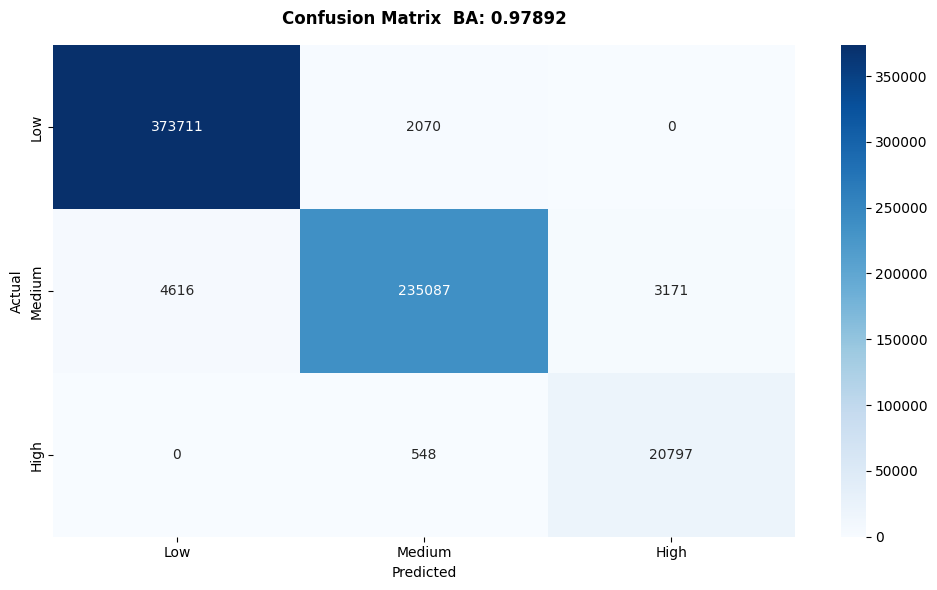

In [30]:
# Confusion matrix
opt_preds = (oof_probs * np.array(final_w)).argmax(axis=1)
cm = confusion_matrix(y_full, opt_preds)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
ax.set_title(f"Confusion Matrix  BA: {opt_oof:.5f}", fontweight="bold", pad=15, fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [31]:
logger.info("\n" + str(classification_report(y_full, opt_preds)))

2026-04-07 13:27:55 | INFO     | 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    375781
           1       0.99      0.97      0.98    242874
           2       0.87      0.97      0.92     21345

    accuracy                           0.98    640000
   macro avg       0.95      0.98      0.96    640000
weighted avg       0.98      0.98      0.98    640000



In [32]:
# Per-class recall
logger.info("Per-Class Recall:")
logger.info("*"*80)
for cls in range(3):
    mask = (y_full == cls)
    recall = (opt_preds[mask] == cls).sum() / mask.sum()
    logger.info(f"{CFG.INV_TARGET_MAPPING[cls]:<10}: {recall:.4f}")
logger.info("*"*80)
logger.info(f"Mean (BA): {opt_oof:.5f}")

2026-04-07 13:27:55 | INFO     | Per-Class Recall:
2026-04-07 13:27:55 | INFO     | ********************************************************************************
2026-04-07 13:27:55 | INFO     | Low       : 0.9945
2026-04-07 13:27:55 | INFO     | Medium    : 0.9679
2026-04-07 13:27:55 | INFO     | High      : 0.9743
2026-04-07 13:27:55 | INFO     | ********************************************************************************
2026-04-07 13:27:55 | INFO     | Mean (BA): 0.97892


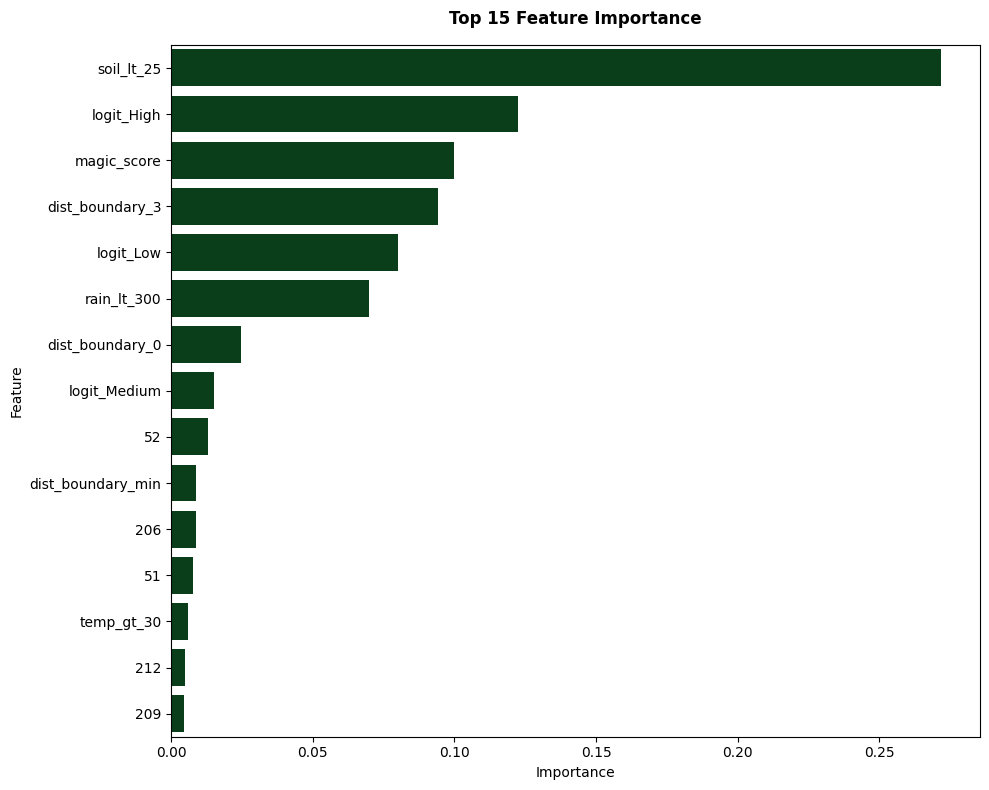

In [33]:
df_importance = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": model_pseudo.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.title("Top 15 Feature Importance", fontweight="bold", pad=15, fontsize=12) 
ax = sns.barplot(x="Importance", y="Feature", data=df_importance, color="#014717")
plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Submission</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Submission
    </h1>
</div>

In [34]:
# Generate submission
test_adj = final_test_probs * np.array(final_w)[np.newaxis, :]
test_preds = test_adj.argmax(axis=1)
test_labels = [CFG.INV_TARGET_MAPPING[p] for p in test_preds]

sub_df = pd.DataFrame({
    "id": list_test_id,
    "Irrigation_Need": test_labels
})

# Save files
sub_df.to_csv("submission.csv", index=False)

logger.info("Submission preview:")
logger.info(sub_df.head(10))
logger.info(f"Distribution:")
logger.info(sub_df["Irrigation_Need"].value_counts())

2026-04-07 13:27:57 | INFO     | Submission preview:
2026-04-07 13:27:57 | INFO     |        id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low
2026-04-07 13:27:57 | INFO     | Distribution:
2026-04-07 13:27:57 | INFO     | Irrigation_Need
Low       159449
Medium    100182
High       10369
Name: count, dtype: int64


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendations</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendations
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🎯 Key Business Recommendations
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">1. Implement Smart Irrigation Trigger System</b>
<ul>
<li>Leverage <b>rainfall, temperature, and soil moisture</b> to automate irrigation decisions</li>
<li>Set threshold-based triggers (e.g., low rainfall + high temperature → increase irrigation)</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Environmental conditions are the primary drivers of irrigation demand.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">2. Optimize Irrigation by Crop Type & Growth Stage</b>
<ul>
<li>Adjust irrigation dynamically based on <b>crop type and growth stage</b></li>
<li>Prioritize higher irrigation during <b>vegetative and flowering stages</b></li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Crop characteristics and lifecycle stages strongly determine water requirements.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">3. Deploy Machine Learning for Decision Support</b>
<ul>
<li>Integrate ML models to capture <b>nonlinear patterns and thresholds</b> in irrigation demand</li>
<li>Use model outputs (Low / Medium / High) to support farmer decision-making</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ ML enhances accuracy by capturing complex interactions beyond rule-based logic.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">4. Scale Mulching as a High-Impact Intervention</b>
<ul>
<li>Promote adoption through <b>training programs and subsidies</b></li>
<li>Target regions with high water scarcity for faster impact</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Mulching significantly reduces irrigation demand by improving soil moisture retention.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">5. Focus on High-Value Features, Reduce Noise</b>
<ul>
<li>Prioritize key drivers: <b>rainfall, temperature, soil moisture, crop factors</b></li>
<li>Deprioritize weak signals such as <b>soil pH, organic carbon, sunlight hours</b></li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Not all statistically significant features deliver meaningful business value.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">6. Separate Demand Drivers from Operational Factors</b>
<ul>
<li>Distinguish between <b>what drives irrigation demand</b> vs <b>how it is delivered</b></li>
<li>Use irrigation type and water source for <b>execution optimization</b>, not prediction</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Operational variables reflect response strategies rather than root causes.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">7. Apply Secondary Factors for Fine-Tuning Only</b>
<ul>
<li>Use <b>humidity, wind speed, and season</b> to refine decisions</li>
<li>Avoid relying on them as primary decision drivers</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ These factors provide incremental improvement but limited standalone impact.
</div>
</div>

<div>
<b style="color:#f7dc6f;">8. Standardize Strategy Across Regions</b>
<ul>
<li>Deploy a <b>consistent irrigation strategy</b> across all regions</li>
<li>Avoid over-segmentation by geography</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Irrigation demand patterns are largely consistent across regions.
</div>
</div>

</div>

<!-- Google Fonts for Roboto -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #762a83;
    padding: 20px;
    background: linear-gradient(135deg, #e7d4e8, #d9f0d3);
    font-family: 'Roboto', sans-serif;
    box-shadow: 0 4px 8px rgba(0,0,0,0.2);
">
  <h4 style="color:#40004b; font-weight:700; margin-bottom:15px;"> Acknowledgements</h4>
  <p style="font-size:15px; color:#333;"> 
  <a href="https://www.kaggle.com/blamerx" style="color:#762a83; text-decoration:underline;">
    @blamerx -
  </a>  
  <a href="https://www.kaggle.com/code/blamerx/s6e4-lightgbm-high-balance-0-979-cv" style="color:#762a83; text-decoration:underline;">
    S6E4 🌾| XGBoost Adv FE | 0.979 CV
  </a>
</p>

  <h4 style="color:#40004b; font-weight:700; margin-top:30px; margin-bottom:16px;">References</h4>
  <ul style="color:#333; font-size:15px;">
    <li><a href="https://www.kaggle.com/competitions/playground-series-s6e4" style="color:#762a83;">Kaggle Playground Series – S6E4</a></li>
  </ul>

  <h4 style="color:#40004b; font-weight:700; margin-top:30px; margin-bottom:16px;">Citation</h4>
  <p style="font-size:15px; color:#333;">
    Walter Reade and Elizabeth Park. <strong>Predicting Irrigation Need</strong><br/>
    <a href="https://www.kaggle.com/competitions/playground-series-s6e4" style="color:#762a83; text-decoration:underline;">Kaggle Competition Playground Series S6E4, 2026.</a>
  </p>
</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Upvote if you liked it 🙌😊
    </p>
</div>
